# Water Stress Forecasting at HUC12 Scale
# Notebook Three Makasih

## IFEST 2026 Data Analysis Competition

Notebook ini mendokumentasikan bagaimana kami membangun sistem prediksi **next-month water stress** pada level HUC12 dengan memanfaatkan historical water budget, seasonal hydrology, dan directed river topology. Fokus kami tidak berhenti pada pemilihan model dengan skor tertinggi. Kami juga memastikan bahwa preprocessing, validation geometry, dan model architecture konsisten dengan karakter temporal dan spasial dari problem yang diberikan.

Secara umum, kami memandang setiap HUC12 sebagai bagian dari sistem sungai yang saling terhubung. Karena itu, probabilitas water stress pada bulan berikutnya kami formulakan sebagai fungsi dari local hydrological state, historical context, serta informasi dari jaringan sungai:

$$
\hat{p}_{i,t+1}
{}={}
P\left(
Y_{i,t+1}=1
\mid
\mathbf{x}_{i,t},
\mathcal{G},
\mathcal{H}_{i,t}
\right)
$$

dengan $i$ sebagai HUC12, $t$ sebagai current monthly origin, $\mathbf{x}_{i,t}$ sebagai local hydrological state, $\mathcal{G}$ sebagai directed river graph, dan $\mathcal{H}_{i,t}$ sebagai historical serta multi-hop hydrological context. Evaluation metric mengikuti kompetisi, yaitu **Average Precision (AP / PR-AUC)**.

Notebook ini terdiri dari dua bagian besar. **Part I** berisi experimental foundation, mulai dari data audit, baseline modeling, temporal reconstruction, scale analysis, cold-start analysis, hingga leakage-controlled validation. **Part II** merangkum seluruh temuan tersebut menjadi final framework yang menggabungkan hydrology-aware features, Directed River Graph, GBDT ensemble, Directed Reachability GNN, dan model fusion.

# Part I. Experimental Foundation and Validation Design

Pada tahap awal, kami tidak langsung mengejar model complexity. Kami terlebih dahulu menguji kualitas data, struktur temporal, perbedaan distribusi train dan test, serta kemungkinan leakage pada validation. Pendekatan ini penting karena model yang terlihat kuat pada random split belum tentu memiliki kemampuan generalization pada future origin yang benar-benar unseen.

Prinsip utama yang kami gunakan adalah bahwa **model selection hanya dapat dipercaya apabila validation geometry mendekati test geometry**. Oleh karena itu, setiap improvement selalu kami evaluasi bersama dengan pertanyaan tentang temporal separation, basin identity overlap, cold-start HUC12, feature-scale consistency, dan stability across folds.

# Part I-A. Baseline and Data Forensics

Bagian ini membangun baseline yang reproducible sekaligus mengidentifikasi sumber signal utama sebelum graph-based modeling diperkenalkan. Alurnya dimulai dari audit data, dilanjutkan dengan hydrology-aware Feature Engineering, validation framework, baseline models, dan OOF blending.

Baseline pada tahap ini kami gunakan sebagai reference point. Tujuannya bukan menetapkan final architecture, tetapi memahami bagian mana dari problem yang benar-benar memberikan predictive signal dan bagian mana yang berpotensi menghasilkan optimistic validation.

## A[1]. Environment Setup and Reproducibility

Kami menetapkan dependency, random seed, runtime configuration, dan path data secara eksplisit agar seluruh eksperimen dapat direproduksi dengan kondisi yang konsisten. Reproducibility penting karena perubahan kecil pada preprocessing atau categorical representation dapat mengubah ordering prediction dan berdampak langsung pada Average Precision.

In [1]:
import os, gc, re, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.metrics import average_precision_score, roc_auc_score

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

DATA = "Dataset/"
SEED = 42
N_FOLDS = 5
rng = np.random.default_rng(SEED)

# 6 famili deret waktu, masing-masing 12 lag (lag0 = bulan origin, lag11 = 11 bulan sebelumnya)
FAMILIES = ["q_bf_inc_m3", "q_qf_inc_m3", "q_ws_cum_m3",
            "q_ir_wd_inc_m3", "q_th_wd_inc_m3", "q_ps_wd_inc_m3"]
LAGS = list(range(12))
LAG_COLS = [f"{f}_lag{l}" for f in FAMILIES for l in LAGS]
SCALARS = ["inc_aream2", "cum_aream2", "pop_dec_2000", "pop_dec_2010",
           "pop_dec_2020", "pop_acs_2020", "clim_median_now", "clim_median_next"]
STATIC = ["inc_aream2", "cum_aream2", "pop_dec_2000", "pop_dec_2010",
          "pop_dec_2020", "pop_acs_2020"]
EPS = 1e-3

print("train:", os.path.getsize(DATA + "train.csv") / 1e6, "MB")
print("test :", os.path.getsize(DATA + "test_public.csv") / 1e6, "MB")

train: 434.065259 MB
test : 13.710968 MB


## A[2]. Data Quality Audit

Sebelum modeling, kami memeriksa integritas numerik seluruh feature untuk memastikan model tidak belajar dari artifact preprocessing. Audit mencakup malformed numeric values, missing values, duplicated records, impossible values, unit inconsistencies, static-feature inconsistencies, dan auxiliary columns yang mencurigakan.

Tahap ini kami anggap sebagai bagian dari modeling, bukan pekerjaan administratif. Pada data water budget, kesalahan parsing atau unit mismatch dapat menggeser nilai beberapa orde magnitudo tanpa selalu menghasilkan error eksplisit.

In [2]:
raw = pd.read_csv(DATA + "train.csv", dtype=str, nrows=120_000)
raw_te = pd.read_csv(DATA + "test_public.csv", dtype=str, nrows=5)
print("train head shape:", raw.shape, "| test cols:", raw_te.shape[1])

col = "q_ws_cum_m3_lag0"
s = raw[col].dropna()
print("\n--- Contoh nilai mentah kolom volume ---")
print(s.sample(8, random_state=0).tolist())

# Format angka yang muncul
has_dot = s.str.contains(".", regex=False)
print("\nFormat US  (1,234,567.890) :", f"{has_dot.mean():.1%}")
print("Format EU  (1234567,890)   :", f"{(~has_dot).mean():.1%}")
print("Pola EU cocok '^-?\\d+,\\d{3}$':",
      f"{s[~has_dot].str.match(r'^-?\d+,\d{3}$').mean():.1%}",
      "| sisanya:", s[~has_dot][~s[~has_dot].str.match(r'^-?\d+,\d{3}$')].unique()[:5].tolist())

print("\n--- ID kotor ---")
print("varian to_id untuk satu id:",
      raw[raw.id.str.strip().str.lower() == raw.id.iloc[0].strip().lower()].to_id.unique()[:4].tolist())
print("nunique id apa adanya     :", raw.id.nunique())
print("nunique id setelah normalisasi:", raw.id.str.strip().str.lower().nunique())

print("\n--- Kolom month kotor ---")
print(sorted(raw.month.unique())[:24])

train head shape: (120000, 103) | test cols: 102

--- Contoh nilai mentah kolom volume ---
['39763111.42723361', '582456.1302177877', '101204.08461112571', '6762.954588760307', '16802.36269555963', '1756150.0602329108', '6972053.151903892', '3178223.3650842668']

Format US  (1,234,567.890) : 98.9%
Format EU  (1234567,890)   : 1.1%
Pola EU cocok '^-?\d+,\d{3}$': 64.5% | sisanya: ['-9999', '0']

--- ID kotor ---
varian to_id untuk satu id: ['OUTLET', ' OUTLET ']
nunique id apa adanya     : 2196
nunique id setelah normalisasi: 2196

--- Kolom month kotor ---
['1', '10', '11', '12', '2', '3', '4', '5', '6', '7', '8', '9', 'Apr', 'April', 'Aug', 'August', 'Dec', 'December', 'Feb', 'February', 'Jan', 'January', 'Jul', 'July']


### A[2.0]. Numeric Locale Normalization

Kami menemukan lebih dari satu pola representasi numerik, termasuk thousands separator dan decimal-comma. Karena itu, parsing dilakukan berdasarkan pola separator dan konteks nilai, bukan dengan coercion langsung.

Tujuannya adalah mencegah silent numerical corruption pada feature volume hidrologi. Setelah normalization, kami memverifikasi kembali distribusi feature dan range antar-kolom sebelum melanjutkan ke unit correction.

In [3]:
MONTH_MAP = {}
for i, (a, b) in enumerate(zip(
        ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"],
        ["january","february","march","april","may","june","july","august",
         "september","october","november","december"]), 1):
    MONTH_MAP[a] = i; MONTH_MAP[b] = i

def parse_numeric(s: pd.Series) -> pd.Series:
    """Parser angka dua-locale + sentinel -9999 -> NaN."""
    s = s.str.strip()
    has_dot = s.str.contains(".", regex=False).fillna(False)
    c = s.where(~has_dot, s.str.replace(",", "", regex=False))   # US: buang pemisah ribuan
    c = c.where(has_dot, c.str.replace(",", ".", regex=False))   # EU: koma -> titik
    x = pd.to_numeric(c, errors="coerce")
    return x.mask(x <= -9998.5)

def parse_month(s: pd.Series) -> pd.Series:
    s = s.str.strip().str.lower()
    n = pd.to_numeric(s, errors="coerce")
    return n.fillna(s.map(MONTH_MAP)).astype("float32")

def load(path):
    df = pd.read_csv(path, dtype=str, engine="pyarrow")  # pyarrow: ~10x lebih cepat untuk 434 MB
    # kolom aux_* dibuang: konstanta, ID teks acak, duplikat berskala, dan noise murni
    df = df.drop(columns=[c for c in df.columns if c.startswith("aux_") or c == ""],
                 errors="ignore")
    df["id"]    = df["id"].str.strip().str.lower()
    df["to_id"] = df["to_id"].str.strip().str.lower()
    df["month"] = parse_month(df["month"])
    df["origin_id"] = pd.to_numeric(df["origin_id"]).astype("int32")
    if "row_id" in df: df["row_id"] = pd.to_numeric(df["row_id"]).astype("int32")
    if "label" in df:  df["label"]  = pd.to_numeric(df["label"]).astype("int8")
    for c in LAG_COLS + SCALARS:
        # .abs(): semua kolom ini besaran fisik non-negatif; tanda negatif = korupsi
        df[c] = parse_numeric(df[c]).abs().astype("float32")
    return df

t0 = time.time()
train = load(DATA + "train.csv")
test  = load(DATA + "test_public.csv")
print(f"loaded in {time.time()-t0:.1f}s | train {train.shape} | test {test.shape}")
print("missing rate (kolom numerik):", f"{train[LAG_COLS].isna().to_numpy().mean():.2%}")

loaded in 9.5s | train (378780, 85) | test (11928, 85)
missing rate (kolom numerik): 2.11%


### A[2.1]. Unit Anomaly Correction

Sebagian feature volume menunjukkan pergeseran skala sebesar faktor $10^3$. Pola tersebut tidak muncul secara uniform pada seluruh observasi, sehingga global rescaling tidak aman.

Kami mendeteksi anomaly secara cross-feature dan cross-time, lalu mengoreksi hanya observasi yang memenuhi pola unit shift yang konsisten:

$$
x^{\mathrm{corrected}}
{}={}
\begin{cases}
x / 1000, & \text{jika unit shift terdeteksi},\\
x, & \text{lainnya}.
\end{cases}
$$

Setelah correction, kami menguji kembali consistency terhadap feature terkait dan historical behavior pada HUC12 yang sama.

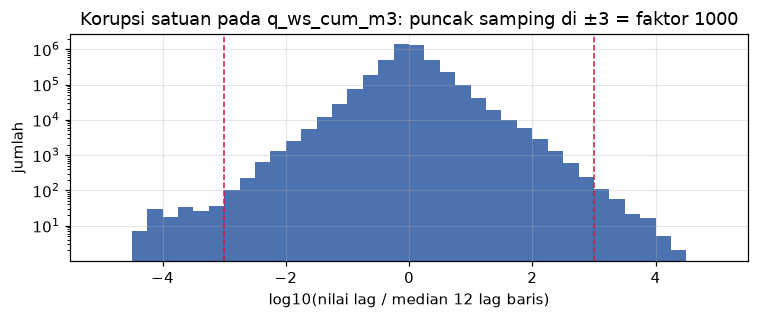

porsi nilai |log10 rasio| > 2.5 : 0.03%


In [4]:
fam = "q_ws_cum_m3"
A = train[[f"{fam}_lag{l}" for l in LAGS]].to_numpy("float32")
med = np.nanmedian(np.where(A > 0, A, np.nan), axis=1)
ratio = np.log10(A / med[:, None])
fin = ratio[np.isfinite(ratio)]

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(fin, bins=np.arange(-5, 5.1, 0.25), color="#4C72B0")
ax.set_yscale("log"); ax.set_xlabel("log10(nilai lag / median 12 lag baris)")
ax.set_ylabel("jumlah"); ax.set_title(f"Korupsi satuan pada {fam}: puncak samping di ±3 = faktor 1000")
for x in (-3, 3): ax.axvline(x, color="crimson", ls="--", lw=1)
plt.tight_layout(); plt.show()
print("porsi nilai |log10 rasio| > 2.5 :", f"{(np.abs(fin) > 2.5).mean():.2%}")

In [5]:
def repair_units(df, thr=300.0):
    """Kembalikan nilai yang tergeser faktor 1000 ke skala median 12-lag barisnya."""
    fixed = 0
    for f in FAMILIES:
        cols = [f"{f}_lag{l}" for l in LAGS]
        A = df[cols].to_numpy("float32")
        with np.errstate(all="ignore"):
            med = np.nanmedian(np.where(A > 0, A, np.nan), axis=1)
        ok = np.isfinite(med) & (med > 0)
        r = A / med[:, None]
        up = ok[:, None] & (r > thr)
        dn = ok[:, None] & (r < 1 / thr) & (A > 0)
        A = np.where(up, A / 1000.0, A)
        A = np.where(dn, A * 1000.0, A)
        fixed += int(up.sum() + dn.sum())
        df[cols] = A
    return df, fixed

train, n1 = repair_units(train)
test,  n2 = repair_units(test)
print(f"sel volume diperbaiki :  train {n1:,} ({n1/(len(train)*72):.2%}), test {n2:,}")

# Baris duplikat: (id, origin_id) yang sama muncul >1x dengan label identik
dup = train.duplicated(["id", "origin_id"]).sum()
train = train.drop_duplicates(["id", "origin_id"]).reset_index(drop=True)
print(f"baris duplikat dibuang: {dup:,} -> train {train.shape}")

sel volume diperbaiki — train 159,769 (0.59%), test 5,412
baris duplikat dibuang: 9,852 -> train (368928, 85)


### A[2.2]. Structural Denoising

Beberapa feature secara domain seharusnya bersifat stabil atau berubah secara terbatas. Basin area, misalnya, merupakan static property per HUC12, sedangkan climatology seharusnya konsisten untuk kombinasi basin dan bulan yang sama.

Kami memanfaatkan repeated historical observations untuk mendeteksi nilai yang bertentangan dengan struktur tersebut. Denoising dilakukan secara konservatif agar kami tidak menghapus genuine hydrological variability.

In [6]:
cv_before = train.groupby("id")["inc_aream2"].std() / train.groupby("id")["inc_aream2"].median()
print("CV inc_aream2 di dalam id :  median:", round(cv_before.median(), 4),
      "| p90:", round(cv_before.quantile(0.9), 3), " (median 0 = memang konstan, ekor = korupsi)")

def denoise_static(tr, te):
    both = pd.concat([tr[["id"] + STATIC], te[["id"] + STATIC]])
    med = both.groupby("id")[STATIC].median()
    for df in (tr, te):
        v = med.reindex(df["id"].to_numpy())
        for c in STATIC:
            df[c] = v[c].to_numpy("float32")
    return tr, te

def build_clim_table(tr, te):
    """Kurva klimatologi pasokan 12 bulan per sub-DAS (id x month)."""
    both = pd.concat([tr[["id","month","clim_median_now"]], te[["id","month","clim_median_now"]]])
    t = both.groupby(["id","month"])["clim_median_now"].median().unstack()
    t = t.reindex(columns=range(1, 13))
    return t.T.ffill().bfill().T.astype("float32")

train, test = denoise_static(train, test)
CLIM = build_clim_table(train, test)
print("tabel klimatologi:", CLIM.shape, "| NaN tersisa:", int(CLIM.isna().sum().sum()))
print("NaN kolom statis setelah denoise:", int(train[STATIC].isna().sum().sum()))

CV inc_aream2 di dalam id — median: 0.0 | p90: 5.312  (median 0 = memang konstan, ekor = korupsi)
tabel klimatologi: (2982, 12) | NaN tersisa: 0
NaN kolom statis setelah denoise: 0


## A[3]. Problem Structure: Origin, HUC12, and River Network

Tiga identifier menentukan struktur utama problem. `origin_id` merepresentasikan monthly snapshot, `id` merepresentasikan HUC12, dan `id -> to_id` merepresentasikan directed downstream relation.

Konsekuensinya, satu baris tidak dapat diperlakukan sebagai IID observation yang sepenuhnya independen. Data memiliki temporal dependence melalui origin dan spatial dependence melalui river topology, sehingga validation dan feature construction harus mempertimbangkan keduanya.

In [7]:
print("origin di train :", train.origin_id.nunique(), "| origin di test:", sorted(test.origin_id.unique()))
print("irisan origin train/test:", set(train.origin_id) & set(test.origin_id), " <- DISJOINT")
print("sub-DAS di train:", train.id.nunique(), "| di test:", test.id.nunique(),
      "| id test yang tak pernah ada di train:", len(set(test.id) - set(train.id)))
print("bulan di test   :", sorted(test.month.unique()))
print("prevalensi label:", round(train.label.mean(), 4))
print("\nlabel rate per origin :  sebaran:")
print(train.groupby("origin_id").label.mean().describe()[["mean","std","min","max"]].round(3).to_dict())

origin di train : 168 | origin di test: [np.int32(14), np.int32(81), np.int32(94), np.int32(169)]


irisan origin train/test: set()  <- DISJOINT
sub-DAS di train: 2196 | di test: 2982 | id test yang tak pernah ada di train: 786
bulan di test   : [np.float32(2.0), np.float32(4.0), np.float32(10.0), np.float32(12.0)]
prevalensi label: 0.2038

label rate per origin — sebaran:
{'mean': 0.204, 'std': 0.088, 'min': 0.041, 'max': 0.417}


### Validation Consequence

`origin_id` pada test tidak overlap dengan training data, sementara banyak HUC12 tetap muncul kembali pada test dan sebagian lainnya merupakan genuine cold-start basins. Struktur ini membuat random row split terlalu mudah karena model dapat melihat basin identity atau regime yang sangat mirip di kedua sisi split.

Kami karena itu memandang test sebagai kombinasi:

$$
\text{future temporal snapshots}
+
\text{partially seen spatial network}
+
\text{cold-start HUC12}.
$$

Validation yang lebih realistis harus memisahkan waktu secara eksplisit dan, pada eksperimen tertentu, juga memisahkan basin identity.

In [8]:
def build_graph(tr, te):
    e = pd.concat([tr[["id","to_id"]], te[["id","to_id"]]]).drop_duplicates("id")
    nodes = sorted(set(e.id))
    idx = {k: i for i, k in enumerate(nodes)}
    to = np.full(len(nodes), -1, np.int32)
    for i, t in zip(e.id.map(idx).to_numpy(), e.to_id.to_numpy()):
        to[i] = idx.get(t, -1)                       # -1 = outlet / di luar cakupan
    indeg = np.zeros(len(nodes), np.int32)
    for i in range(len(nodes)):
        if to[i] >= 0: indeg[to[i]] += 1
    order, stack = [], [i for i in range(len(nodes)) if indeg[i] == 0]
    while stack:                                     # Kahn: hulu lebih dulu
        i = stack.pop(); order.append(i)
        j = to[i]
        if j >= 0:
            indeg[j] -= 1
            if indeg[j] == 0: stack.append(j)
    return idx, to, np.asarray(order, np.int32)

NODE_IDX, TO, ORDER = build_graph(train, test)
N_NODE = len(NODE_IDX)
# CORE = simpul yang dipakai saat mengakumulasi hulu.
# Dulu dibatasi ke simpul train "agar definisinya identik di train & test".
# Diaudit: NOL sub-DAS dikenal punya hulu tak dikenal, sedangkan 400 dari 400
# sub-DAS tak-dikenal yang punya hulu justru dinolkan seluruhnya oleh batasan itu.
# Jadi batasan itu murni kerugian: train dan test-dikenal tidak berubah sama sekali,
# hanya 400 sub-DAS test-only yang kembali mendapat fitur jaringannya yang benar.
CORE = np.arange(N_NODE, dtype=np.int64)                 # seluruh simpul train + test

def accumulate(values, node_idx, origin, to=TO, order=ORDER, nnode=N_NODE):
    """Akumulasi nilai dari hulu ke hilir, terpisah per origin."""
    out = np.zeros(len(values), "float64")
    for o in np.unique(origin):
        m = origin == o
        buf = np.zeros(nnode, "float64")
        np.add.at(buf, node_idx[m], np.nan_to_num(values[m]))
        for i in order:
            j = to[i]
            if j >= 0: buf[j] += buf[i]
        out[m] = buf[node_idx[m]]
    return out

print(f"jaringan: {N_NODE} simpul, {len(ORDER)} terurut topologis (= asiklik),"
      f" {(TO < 0).sum()} outlet | simpul teramati di train: {len(CORE)}")

jaringan: 2982 simpul, 2982 terurut topologis (= asiklik), 148 outlet | simpul teramati di train: 2982


## A[4]. Hydrology-Aware Feature Engineering

Feature Engineering kami mengikuti interpretasi water budget. Secara intuitif, water stress meningkat ketika available supply menurun sementara withdrawal pressure tetap tinggi atau meningkat. Karena itu, kami membentuk feature yang membandingkan current supply dengan long-term seasonal condition.

Salah satu representasi generik yang kami gunakan adalah:

$$
\text{Availability Estimate}
{}={}
\text{Supply}
{}-{}
\text{Withdrawal Pressure}.
$$

Relative water limitation kemudian dapat direpresentasikan sebagai:

$$
\text{Relative Limitation}
\approx
1-
\frac{\text{Availability Estimate}}
{\text{Long-Term Typical Supply}+\varepsilon}.
$$

Feature ini dipakai sebagai physically motivated estimate. Kami tidak memperlakukannya sebagai official operational SUI, tetapi sebagai representation yang membantu model mengenali low-supply regime secara lebih eksplisit.

In [9]:
def featurize(df, clim=None, core=None):
    clim = CLIM if clim is None else clim
    core = CORE if core is None else core
    X = pd.DataFrame(index=df.index)
    n = len(df)
    m = df["month"].to_numpy()
    tgt = (m % 12) + 1                                   # bulan target = origin + 1
    X["month"], X["tgt_month"] = m, tgt
    X["month_sin"] = np.sin(2*np.pi*m/12); X["month_cos"] = np.cos(2*np.pi*m/12)

    # ---------- statis ----------
    for c in STATIC: X["log_" + c] = np.log1p(df[c])
    X["pop_density"] = df["pop_dec_2020"] / (df["inc_aream2"]/1e6 + EPS)
    X["pop_growth"]  = (df["pop_dec_2020"] + 1) / (df["pop_dec_2000"] + 1)
    X["area_ratio"]  = df["cum_aream2"] / (df["inc_aream2"] + EPS)

    # ---------- kurva klimatologi ----------
    C  = clim.reindex(df["id"].to_numpy()).to_numpy("float32")       # n x 12
    ri = np.arange(n)
    clim_at = lambda k: C[ri, ((m - 1 - k) % 12).astype(int)]        # klimatologi bulan lag-k
    c_now, c_next = clim_at(0), C[ri, (tgt - 1).astype(int)]
    c_ann = np.nanmean(C, axis=1)
    X["log_clim_next"]      = np.log1p(c_next)
    X["clim_next_over_now"] = (c_next + EPS) / (c_now + EPS)
    X["clim_next_over_ann"] = (c_next + EPS) / (c_ann + EPS)
    X["clim_next_rank"]     = (C < c_next[:, None]).sum(1)           # 0..11, musim kering/basah
    X["clim_cv"]            = np.nanstd(C, axis=1) / (c_ann + EPS)

    # ---------- statistik 12-lag per famili ----------
    blk = {}
    for f in FAMILIES:
        A = df[[f"{f}_lag{l}" for l in LAGS]].to_numpy("float32"); blk[f] = A
        L = np.log1p(A)
        for l in (0, 1, 2, 11): X[f"{f}_l{l}"] = L[:, l]
        X[f"{f}_mean3"]  = np.nanmean(L[:, :3], axis=1)
        X[f"{f}_mean12"] = np.nanmean(L, axis=1)
        X[f"{f}_std12"]  = np.nanstd(L, axis=1)
        X[f"{f}_min12"]  = np.nanmin(L, axis=1)
        X[f"{f}_max12"]  = np.nanmax(L, axis=1)
        X[f"{f}_last_vs_mean"] = L[:, 0] - X[f"{f}_mean12"]
        X[f"{f}_trend"]  = np.nanmean(L[:, :3], axis=1) - np.nanmean(L[:, 3:9], axis=1)
        X[f"{f}_yoy"]    = L[:, 0] - L[:, 11]

    sup = blk["q_bf_inc_m3"] + blk["q_qf_inc_m3"]                     # pasokan lokal
    dem = (blk["q_ir_wd_inc_m3"] + blk["q_th_wd_inc_m3"] + blk["q_ps_wd_inc_m3"])
    ws  = blk["q_ws_cum_m3"]                                          # pasokan kumulatif
    X["bf_frac"] = blk["q_bf_inc_m3"][:, 0] / (sup[:, 0] + EPS)       # baseflow = penyangga kekeringan
    for k, nm in ((0, "l0"), (11, "l11")):
        X[f"dem_{nm}"] = np.log1p(dem[:, k]); X[f"sup_{nm}"] = np.log1p(sup[:, k])
    X["dem_mean12"] = np.log1p(np.nanmean(dem, axis=1))
    X["sup_mean12"] = np.log1p(np.nanmean(sup, axis=1))
    for nm, arr in (("ir", "q_ir_wd_inc_m3"), ("th", "q_th_wd_inc_m3"), ("ps", "q_ps_wd_inc_m3")):
        X[f"dem_share_{nm}"] = blk[arr][:, 0] / (dem[:, 0] + EPS)

    # ---------- indeks stres lokal ----------
    X["sui_local_l0"]      = np.log1p(dem[:, 0]  / (ws[:, 0]  + EPS))
    X["sui_local_l11"]     = np.log1p(dem[:, 11] / (ws[:, 11] + EPS))
    X["sui_local_m12"]     = np.log1p(np.nanmean(dem, 1) / (np.nanmean(ws, 1) + EPS))
    X["dem_over_sup_l0"]   = np.log1p(dem[:, 0] / (sup[:, 0] + EPS))
    X["dem_over_clim_next"]= np.log1p(dem[:, 0] / (c_next + EPS))
    X["dem_per_cap"]       = dem[:, 0] / (df["pop_dec_2020"].to_numpy() + 1)
    X["dem_per_area"]      = dem[:, 0] / (df["inc_aream2"].to_numpy() + EPS)

    # ---------- anomali pasokan (inti model) ----------
    AN = np.empty_like(ws)
    for k in LAGS: AN[:, k] = ws[:, k] / (clim_at(k) + EPS)
    LA = np.log1p(AN)
    X["anom_l0"], X["anom_l1"] = LA[:, 0], LA[:, 1]
    X["anom_mean3"]  = np.nanmean(LA[:, :3], axis=1)
    X["anom_mean6"]  = np.nanmean(LA[:, :6], axis=1)
    X["anom_mean12"] = np.nanmean(LA, axis=1)
    X["anom_min12"]  = np.nanmin(LA, axis=1)
    X["anom_std12"]  = np.nanstd(LA, axis=1)
    X["anom_trend"]  = X["anom_mean3"] - X["anom_mean12"]
    recent = np.nanmean(AN[:, :3], axis=1)
    proj = c_next * np.where(np.isfinite(recent), recent, 1.0)    # proyeksi pasokan bulan depan
    X["log_proj_supply"] = np.log1p(proj)
    X["sui_proj_local"]  = np.log1p(dem[:, 11] / (proj + EPS))
    X["anom_vs_next"]    = X["q_ws_cum_m3_l0"] - X["log_clim_next"]
    X["proj_vs_next"]    = X["log_proj_supply"] - X["log_clim_next"]
    X["anom_l0_x_cv"]    = X["anom_l0"] / (X["clim_cv"] + EPS)

    # ---------- routing jaringan sungai ----------
    ni = df["id"].map(NODE_IDX).to_numpy(); og = df["origin_id"].to_numpy()
    area = df["inc_aream2"].to_numpy()
    acc = lambda v: accumulate(v, ni, og)
    up_dem0, up_dem11 = acc(dem[:, 0]), acc(dem[:, 11])
    X["up_nodes"]        = acc(np.ones(n, "float32"))
    X["up_area_frac"]    = acc(area) / (df["cum_aream2"].to_numpy() + EPS)
    X["log_up_dem0"]     = np.log1p(up_dem0)
    X["log_up_sup0"]     = np.log1p(acc(sup[:, 0]))
    X["sui_net_l0"]      = np.log1p(up_dem0  / (ws[:, 0]  + EPS))
    X["sui_net_l11"]     = np.log1p(up_dem11 / (ws[:, 11] + EPS))
    X["sui_net_proj"]    = np.log1p(up_dem11 / (acc(proj) + EPS))
    X["sui_net_clim"]    = np.log1p(up_dem0  / (acc(c_next) + EPS))
    X["up_dem_local_frac"] = dem[:, 0] / (up_dem0 + EPS)
    X["is_outlet"]       = (df["to_id"].to_numpy() == "outlet").astype("int8")

    # konteks tetangga: agregat dibatasi ke simpul CORE agar definisinya identik di train & test
    anom = X["anom_l0"].to_numpy()
    in_core = np.isin(ni, core)
    rank = np.full(n, np.nan)
    for o in np.unique(og):
        msk = og == o
        ref = anom[msk][in_core[msk] & np.isfinite(anom[msk])]
        if len(ref): rank[msk] = np.searchsorted(np.sort(ref), anom[msk]) / len(ref)
    X["anom_rank_in_origin"] = rank                      # posisi relatif dalam potret regional
    w  = np.where(np.isfinite(anom) & in_core, area, 0.0)
    wa = np.where(np.isfinite(anom) & in_core, anom * area, 0.0)
    uw = acc(w)
    X["up_anom_wmean"] = acc(wa) / np.where(uw > 0, uw, np.nan)
    X["anom_minus_upstream"] = anom - X["up_anom_wmean"]
    dn1 = TO[ni]
    dn2 = np.where(dn1 >= 0, TO[np.maximum(dn1, 0)], -1)
    for nm, hop, src in (("dn_anom", dn1, anom), ("dn2_anom", dn2, anom),
                         ("dn_sui", dn1, X["sui_net_l0"].to_numpy())):
        buf = np.full(N_NODE, np.nan); res = np.full(n, np.nan)
        for o in np.unique(og):
            msk = og == o
            buf[:] = np.nan; buf[ni[msk]] = src[msk]
            res[msk] = np.where(hop[msk] >= 0, buf[np.maximum(hop[msk], 0)], np.nan)
        X[nm] = res
    return X.replace([np.inf, -np.inf], np.nan).astype("float32")

t0 = time.time()
X      = featurize(train)
X_test = featurize(test)
y      = train["label"].to_numpy()
groups = train["origin_id"].to_numpy()
print(f"featurize {time.time()-t0:.1f}s | X {X.shape} | X_test {X_test.shape}")
assert list(X.columns) == list(X_test.columns)

featurize 2.5s | X (368928, 136) | X_test (11928, 136)


### A[4.1]. Core Signal Screening

Sebelum melatih model kompleks, kami melakukan univariate signal screening untuk memahami information content setiap feature. Tahap ini tidak digunakan sebagai feature selection tunggal, tetapi sebagai diagnostic awal terhadap feature yang memiliki ranking signal kuat.

Sebagai reference, AP dari random ranking mendekati positive prevalence pada training data. Feature dengan AP yang jauh lebih tinggi dari baseline tersebut menjadi kandidat utama untuk ablation dan interaction analysis pada tahap berikutnya.

In [10]:
prev = y.mean()
rows = []
for c in ["anom_l0", "anom_mean3", "anom_min12", "anom_vs_next", "proj_vs_next",
          "dn_anom", "up_anom_wmean", "sui_net_l0", "sui_local_l0", "clim_next_over_now"]:
    v = X[c].fillna(X[c].median()).to_numpy()
    rows.append((c, average_precision_score(y, -v), average_precision_score(y, v)))
single = pd.DataFrame(rows, columns=["fitur", "AP(arah -)", "AP(arah +)"]).round(4)
single["AP terbaik"] = single[["AP(arah -)", "AP(arah +)"]].max(1)
print(f"prevalensi (AP acak) = {prev:.4f}\n")
print(single.sort_values("AP terbaik", ascending=False).to_string(index=False))

prevalensi (AP acak) = 0.2038

             fitur  AP(arah -)  AP(arah +)  AP terbaik
     up_anom_wmean      0.4594      0.1285      0.4594
      proj_vs_next      0.4482      0.1307      0.4482
           anom_l0      0.4464      0.1268      0.4464
      anom_vs_next      0.4382      0.1277      0.4382
           dn_anom      0.4313      0.1283      0.4313
        anom_mean3      0.4280      0.1295      0.4280
        anom_min12      0.3070      0.1390      0.3070
clim_next_over_now      0.1966      0.2469      0.2469
      sui_local_l0      0.2005      0.2317      0.2317
        sui_net_l0      0.2005      0.2316      0.2316


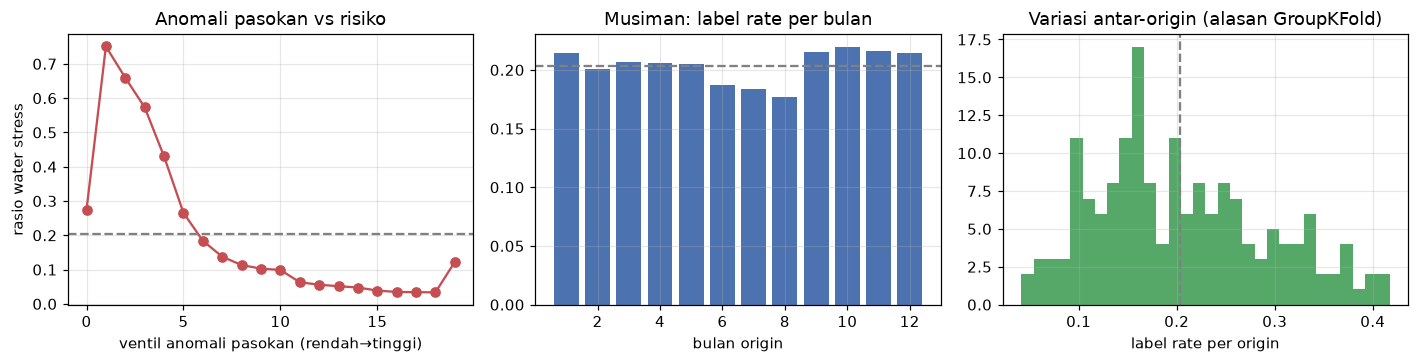

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
d = pd.DataFrame({"anom": X["anom_l0"], "label": y, "month": X["month"]})
q = pd.qcut(d.anom, 20, duplicates="drop")
g = d.groupby(q, observed=True).label.mean()
axes[0].plot(range(len(g)), g.to_numpy(), "o-", color="#C44E52")
axes[0].axhline(prev, ls="--", c="gray"); axes[0].set_xlabel("ventil anomali pasokan (rendah→tinggi)")
axes[0].set_ylabel("rasio water stress"); axes[0].set_title("Anomali pasokan vs risiko")

mb = d.groupby("month").label.mean()
axes[1].bar(mb.index, mb.to_numpy(), color="#4C72B0")
axes[1].axhline(prev, ls="--", c="gray"); axes[1].set_xlabel("bulan origin")
axes[1].set_title("Musiman: label rate per bulan")

ob = train.groupby("origin_id").label.mean()
axes[2].hist(ob, bins=30, color="#55A868")
axes[2].axvline(prev, ls="--", c="gray"); axes[2].set_xlabel("label rate per origin")
axes[2].set_title("Variasi antar-origin (alasan GroupKFold)")
plt.tight_layout(); plt.show()

## A[5]. Validation Framework

Seluruh baseline dievaluasi melalui interface yang sama agar perbandingan tetap fair. Kami menjaga fold definition, target, metric, feature contract, dan OOF generation tetap konsisten sehingga perubahan score dapat ditelusuri ke model atau representation yang diuji.

Primary metric tetap Average Precision. Untuk eksperimen yang melibatkan blending, kami hanya menggunakan out-of-fold predictions agar ensemble weight tidak dipilih dari in-sample score.

In [12]:
FOLDS = list(GroupKFold(n_splits=N_FOLDS).split(X, y, groups))
for k, (a, b) in enumerate(FOLDS):
    print(f"fold {k}: train {len(a):>6,} ({len(np.unique(groups[a])):>3} origin) | "
          f"valid {len(b):>6,} ({len(np.unique(groups[b])):>2} origin) | "
          f"label rate valid {y[b].mean():.3f}")

FEATURES = list(X.columns)
Xnp = X.to_numpy("float32")
Xt_np = X_test.to_numpy("float32")
MED = np.nanmedian(Xnp, axis=0)
Xnp_imp = np.where(np.isfinite(Xnp), Xnp, MED)          # untuk model yang tidak tahan NaN
Xt_imp  = np.where(np.isfinite(Xt_np), Xt_np, MED)

RESULTS = {}     # nama -> dict(oof, test, ap, secs)

def cv(name, fit_predict, use_imputed=False, verbose=True):
    """Jalankan satu model lewat FOLDS; simpan OOF + prediksi test rata-rata fold."""
    A, B = (Xnp_imp, Xt_imp) if use_imputed else (Xnp, Xt_np)
    oof = np.zeros(len(y)); test_pred = np.zeros(len(X_test)); t0 = time.time()
    for a, b in FOLDS:
        p_val, p_test = fit_predict(A[a], y[a], A[b], y[b], B)
        oof[b] = p_val; test_pred += p_test / len(FOLDS)
    sc = average_precision_score(y, oof)
    RESULTS[name] = dict(oof=oof, test=test_pred, ap=sc, secs=time.time() - t0)
    if verbose:
        per_fold = [average_precision_score(y[b], oof[b]) for _, b in FOLDS]
        print(f"{name:<22} AP={sc:.4f}  per-fold={np.round(per_fold,4).tolist()}  "
              f"({time.time()-t0:.0f}s)")
    return sc

fold 0: train 294,264 (134 origin) | valid 74,664 (34 origin) | label rate valid 0.219
fold 1: train 294,264 (134 origin) | valid 74,664 (34 origin) | label rate valid 0.215
fold 2: train 294,264 (134 origin) | valid 74,664 (34 origin) | label rate valid 0.195
fold 3: train 296,460 (135 origin) | valid 72,468 (33 origin) | label rate valid 0.184
fold 4: train 296,460 (135 origin) | valid 72,468 (33 origin) | label rate valid 0.206


## A[6]. Baseline Model Exploration

Kami mengevaluasi beberapa model family dengan inductive bias berbeda, termasuk CatBoost, LightGBM, XGBoost, random-forest-style ensemble, dan linear baseline. Tujuannya adalah mengukur seberapa besar nonlinear interaction dibutuhkan sebelum kami menambahkan graph-aware representation.

Perbandingan ini juga membantu kami memahami apakah improvement berasal dari model capacity atau dari Feature Engineering dan validation design.

In [13]:
import lightgbm as lgb

LGB_PARAMS = dict(objective="binary", metric="average_precision", learning_rate=0.03,
                  num_leaves=255, min_data_in_leaf=60, feature_fraction=0.6,
                  bagging_fraction=0.8, bagging_freq=1, lambda_l2=10.0,
                  verbosity=-1, num_threads=0, seed=SEED)
LGB_ROUNDS = {}

def fit_lgb(xa, ya, xb, yb, xt):
    ds = lgb.Dataset(xa, ya, feature_name=FEATURES)
    m = lgb.train(LGB_PARAMS, ds, 4000, valid_sets=[lgb.Dataset(xb, yb, feature_name=FEATURES)],
                  callbacks=[lgb.early_stopping(200, verbose=False)])
    LGB_ROUNDS[len(LGB_ROUNDS)] = m.best_iteration
    globals()["LGB_LAST"] = m
    return (m.predict(xb, num_iteration=m.best_iteration),
            m.predict(xt, num_iteration=m.best_iteration))

cv("LightGBM", fit_lgb)
print("best_iteration per fold:", list(LGB_ROUNDS.values()))

LightGBM               AP=0.7153  per-fold=[0.7396, 0.74, 0.7013, 0.711, 0.7044]  (143s)
best_iteration per fold: [146, 147, 123, 74, 288]


In [14]:
import xgboost as xgb

def fit_xgb(xa, ya, xb, yb, xt):
    p = dict(objective="binary:logistic", eval_metric="aucpr", eta=0.03, max_depth=8,
             min_child_weight=10, subsample=0.8, colsample_bytree=0.6, reg_lambda=10,
             tree_method="hist", nthread=0, seed=SEED)
    d, v = xgb.DMatrix(xa, ya), xgb.DMatrix(xb, yb)
    m = xgb.train(p, d, 3000, evals=[(v, "v")], early_stopping_rounds=150, verbose_eval=False)
    r = (0, m.best_iteration + 1)
    return m.predict(v, iteration_range=r), m.predict(xgb.DMatrix(xt), iteration_range=r)

cv("XGBoost", fit_xgb)

XGBoost                AP=0.7181  per-fold=[0.7419, 0.7398, 0.7004, 0.7132, 0.7038]  (65s)


0.718132199897723

In [15]:
from catboost import CatBoostClassifier

def fit_cat(xa, ya, xb, yb, xt):
    m = CatBoostClassifier(iterations=2000, learning_rate=0.06, depth=7, l2_leaf_reg=10,
                           border_count=128, eval_metric="Logloss", random_seed=SEED,
                           verbose=0, early_stopping_rounds=100, thread_count=-1,
                           bootstrap_type="Bernoulli", subsample=0.8, rsm=0.7)
    m.fit(xa, ya, eval_set=(xb, yb))
    return m.predict_proba(xb)[:, 1], m.predict_proba(xt)[:, 1]

cv("CatBoost", fit_cat)

CatBoost               AP=0.7101  per-fold=[0.7338, 0.7277, 0.6928, 0.7019, 0.6989]  (107s)


0.7100966299368937

In [16]:
from sklearn.ensemble import HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import QuantileTransformer

def fit_hgb(xa, ya, xb, yb, xt):
    m = HistGradientBoostingClassifier(max_iter=500, learning_rate=0.06, max_leaf_nodes=63,
            min_samples_leaf=100, l2_regularization=10, early_stopping=True,
            validation_fraction=0.1, n_iter_no_change=40, random_state=SEED)
    m.fit(xa, ya)
    return m.predict_proba(xb)[:, 1], m.predict_proba(xt)[:, 1]

def fit_et(xa, ya, xb, yb, xt):
    m = ExtraTreesClassifier(n_estimators=300, min_samples_leaf=20, max_features=0.4,
                             n_jobs=-1, random_state=SEED)
    m.fit(xa, ya)
    return m.predict_proba(xb)[:, 1], m.predict_proba(xt)[:, 1]

def fit_lr(xa, ya, xb, yb, xt):
    m = make_pipeline(QuantileTransformer(output_distribution="normal", subsample=100_000,
                                          random_state=SEED),
                      LogisticRegression(C=0.5, max_iter=2000))
    m.fit(xa, ya)
    return m.predict_proba(xb)[:, 1], m.predict_proba(xt)[:, 1]

cv("HistGradientBoosting", fit_hgb)
cv("ExtraTrees",  fit_et, use_imputed=True)
cv("LogisticReg", fit_lr, use_imputed=True)

HistGradientBoosting   AP=0.7092  per-fold=[0.7333, 0.7267, 0.6922, 0.699, 0.699]  (152s)


ExtraTrees             AP=0.7157  per-fold=[0.739, 0.738, 0.695, 0.7111, 0.6979]  (488s)


LogisticReg            AP=0.6091  per-fold=[0.6487, 0.6185, 0.5643, 0.616, 0.6047]  (61s)


0.6090782026561357

## A[7]. Feature Importance Analysis

Kami tidak menggunakan gain importance sebagai satu-satunya dasar interpretasi karena metric tersebut dapat bias terhadap continuous features dengan banyak possible split dan terhadap correlated predictors. Interpretation dilakukan dengan menggabungkan gain importance, univariate AP, ablation, dan stability across validation blocks.

Sebuah feature hanya kami anggap benar-benar penting apabila kontribusinya konsisten pada lebih dari satu diagnostic. Dengan cara ini, kami mengurangi risiko membangun narasi dari importance ranking yang kebetulan.

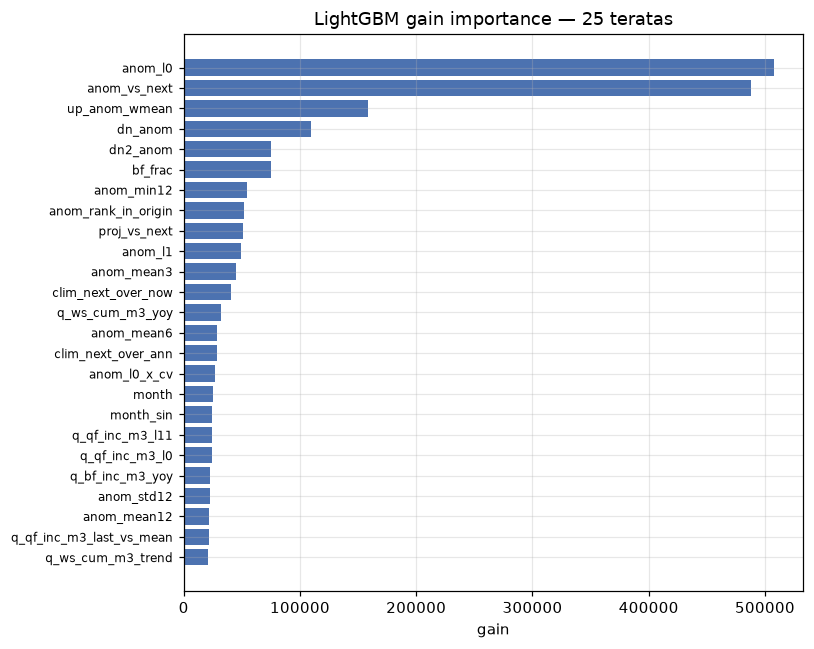

Fitur yang tidak pernah dipakai memecah: 9 dari 136
['q_th_wd_inc_m3_l11', 'q_th_wd_inc_m3_mean3', 'q_th_wd_inc_m3_mean12', 'q_th_wd_inc_m3_std12', 'q_th_wd_inc_m3_min12', 'q_th_wd_inc_m3_max12', 'q_th_wd_inc_m3_trend', 'dem_share_th', 'is_outlet']


In [17]:
gain = pd.Series(LGB_LAST.feature_importance("gain"), index=FEATURES).sort_values(ascending=False)
split = pd.Series(LGB_LAST.feature_importance("split"), index=FEATURES)

fig, ax = plt.subplots(figsize=(7.5, 6))
top = gain.head(25)[::-1]
ax.barh(range(len(top)), top.to_numpy(), color="#4C72B0")
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=8)
ax.set_xlabel("gain"); ax.set_title("LightGBM gain importance :  25 teratas")
plt.tight_layout(); plt.show()

print("Fitur yang tidak pernah dipakai memecah:", (split == 0).sum(), "dari", len(FEATURES))
print(list(split[split == 0].index)[:15])

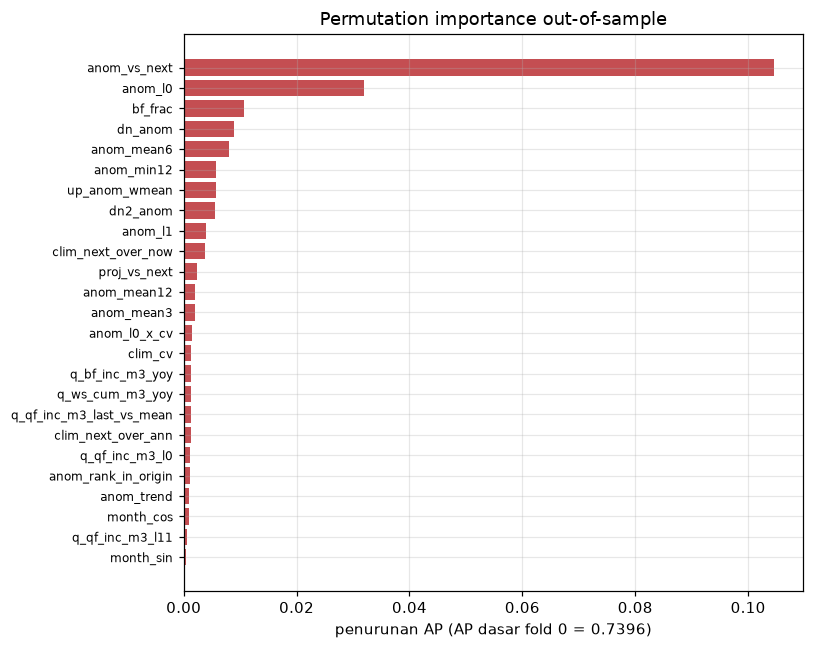

anom_vs_next          0.1045
anom_l0               0.0320
bf_frac               0.0107
dn_anom               0.0090
anom_mean6            0.0080
anom_min12            0.0058
up_anom_wmean         0.0057
dn2_anom              0.0056
anom_l1               0.0039
clim_next_over_now    0.0037
proj_vs_next          0.0024
anom_mean12           0.0020


In [18]:
# Permutation importance out-of-sample, pada fold 0
a, b = FOLDS[0]
m_pi = lgb.train(LGB_PARAMS, lgb.Dataset(Xnp[a], y[a], feature_name=FEATURES), 4000,
                 valid_sets=[lgb.Dataset(Xnp[b], y[b], feature_name=FEATURES)],
                 callbacks=[lgb.early_stopping(200, verbose=False)])
base_ap = average_precision_score(y[b], m_pi.predict(Xnp[b], num_iteration=m_pi.best_iteration))

cand = list(gain.head(30).index)
perm_rng = np.random.default_rng(SEED)
drops = {}
Xb = Xnp[b].copy()
for c in cand:
    j = FEATURES.index(c)
    keep = Xb[:, j].copy()
    Xb[:, j] = perm_rng.permutation(keep)
    drops[c] = base_ap - average_precision_score(
        y[b], m_pi.predict(Xb, num_iteration=m_pi.best_iteration))
    Xb[:, j] = keep

perm = pd.Series(drops).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7.5, 6))
t = perm.head(25)[::-1]
ax.barh(range(len(t)), t.to_numpy(), color=["#C44E52" if v > 0 else "#999" for v in t])
ax.set_yticks(range(len(t))); ax.set_yticklabels(t.index, fontsize=8)
ax.set_xlabel(f"penurunan AP (AP dasar fold 0 = {base_ap:.4f})")
ax.set_title("Permutation importance out-of-sample")
plt.tight_layout(); plt.show()
print(perm.head(12).round(4).to_string())

In [19]:
# Ablasi per kelompok fitur: seberapa besar kontribusi tiap ide desain?
GROUPS = {
    "anomali klimatologi": [c for c in FEATURES if c.startswith("anom") or c in
                            ("log_proj_supply","proj_vs_next","sui_proj_local","log_clim_next",
                             "clim_next_over_now","clim_next_over_ann","clim_next_rank","clim_cv")],
    "routing jaringan":    [c for c in FEATURES if c.startswith(("up_","dn_","dn2_","sui_net"))
                            or c == "is_outlet"],
    "statistik 12-lag":    [c for c in FEATURES if any(c.startswith(f) for f in FAMILIES)],
    "permintaan & rasio":  [c for c in FEATURES if c.startswith(("dem_","sup_","sui_local"))
                            or c in ("bf_frac","dem_over_sup_l0","dem_over_clim_next")],
    "statis & populasi":   [c for c in FEATURES if c.startswith("log_pop") or c in
                            ("pop_density","pop_growth","area_ratio","log_inc_aream2","log_cum_aream2")],
    "musiman":             ["month","tgt_month","month_sin","month_cos"],
}
fast = {**LGB_PARAMS, "learning_rate": 0.06}
def quick_ap(cols):
    idxs = [FEATURES.index(c) for c in cols]
    oof = np.zeros(len(y))
    for a, b in FOLDS:
        mm = lgb.train(fast, lgb.Dataset(Xnp[a][:, idxs], y[a]), 2000,
                       valid_sets=[lgb.Dataset(Xnp[b][:, idxs], y[b])],
                       callbacks=[lgb.early_stopping(120, verbose=False)])
        oof[b] = mm.predict(Xnp[b][:, idxs], num_iteration=mm.best_iteration)
    return average_precision_score(y, oof)

full_ap = quick_ap(FEATURES)
rows = [("SEMUA FITUR", len(FEATURES), full_ap, 0.0)]
for gname, cols in GROUPS.items():
    rest = [c for c in FEATURES if c not in set(cols)]
    a_ = quick_ap(rest)
    rows.append((f"tanpa {gname}", len(rest), a_, full_ap - a_))
abl = pd.DataFrame(rows, columns=["konfigurasi", "n_fitur", "AP", "penurunan"]).round(4)
print(abl.to_string(index=False))

              konfigurasi  n_fitur     AP  penurunan
              SEMUA FITUR      136 0.7180     0.0000
tanpa anomali klimatologi      116 0.6796     0.0384
   tanpa routing jaringan      124 0.7152     0.0027
   tanpa statistik 12-lag       64 0.7124     0.0055
 tanpa permintaan & rasio      119 0.7158     0.0022
  tanpa statis & populasi      127 0.7159     0.0021
            tanpa musiman      132 0.7174     0.0006


## A[8]. Model Blending

Average Precision sangat sensitif terhadap ordering prediction. Karena itu, kami mengevaluasi blending menggunakan OOF predictions dan, ketika diperlukan, rank-normalized outputs untuk mengurangi perbedaan calibration scale antar-model.

Untuk $M$ model, blended score ditulis sebagai:

$$
s_i
{}={}
\sum_{m=1}^{M}
w_m r_{im},
\qquad
w_m \ge 0,
\qquad
\sum_{m=1}^{M} w_m = 1,
$$

dengan $r_{im}$ sebagai normalized ranking score dari model ke-$m$ untuk observasi $i$. Weight dipilih berdasarkan out-of-time validation performance, bukan training fit.

In [20]:
from scipy.stats import rankdata

summary = pd.DataFrame([{"model": k, "AP": v["ap"], "detik": round(v["secs"])}
                        for k, v in RESULTS.items()]).sort_values("AP", ascending=False)
print(summary.round(4).to_string(index=False))

names = list(RESULTS)
R  = np.column_stack([rankdata(RESULTS[k]["oof"]) / len(y) for k in names])
Rt = np.column_stack([rankdata(RESULTS[k]["test"]) / len(X_test) for k in names])

print("\nkorelasi rank antar-OOF (makin rendah makin saling melengkapi):")
print(pd.DataFrame(np.corrcoef(R.T), index=names, columns=names).round(3).to_string())

# pencarian bobot maju (forward selection dengan pengulangan)
w = np.zeros(len(names)); cur = np.zeros(len(y)); best_hist = []
for step in range(15):
    scores = [average_precision_score(y, cur + R[:, j]) for j in range(len(names))]
    j = int(np.argmax(scores))
    if best_hist and scores[j] <= best_hist[-1] + 1e-6:
        break
    cur = cur + R[:, j]; w[j] += 1; best_hist.append(scores[j])
w = w / max(w.sum(), 1)
blend_oof = R @ w
blend_ap  = average_precision_score(y, blend_oof)

print("\nbobot blend:", {n: round(float(v), 3) for n, v in zip(names, w) if v > 0})
print(f"AP blend   : {blend_ap:.4f}")
best_single = summary.iloc[0]
print(f"AP terbaik tunggal ({best_single.model}): {best_single.AP:.4f}")

USE_BLEND = blend_ap > best_single.AP + 1e-4
final_oof  = blend_oof if USE_BLEND else RESULTS[best_single.model]["oof"]
final_test = (Rt @ w) if USE_BLEND else RESULTS[best_single.model]["test"]
final_ap   = blend_ap if USE_BLEND else best_single.AP
print(f"\n>>> dipakai: {'BLEND' if USE_BLEND else best_single.model} | OOF AP = {final_ap:.4f}")

               model     AP  detik
             XGBoost 0.7181     65
          ExtraTrees 0.7157    488
            LightGBM 0.7153    143
            CatBoost 0.7101    107
HistGradientBoosting 0.7092    152
         LogisticReg 0.6091     61



korelasi rank antar-OOF (makin rendah makin saling melengkapi):
                      LightGBM  XGBoost  CatBoost  HistGradientBoosting  ExtraTrees  LogisticReg
LightGBM                 1.000    0.990     0.950                 0.959       0.950        0.830
XGBoost                  0.990    1.000     0.968                 0.973       0.965        0.850
CatBoost                 0.950    0.968     1.000                 0.978       0.968        0.850
HistGradientBoosting     0.959    0.973     0.978                 1.000       0.966        0.847
ExtraTrees               0.950    0.965     0.968                 0.966       1.000        0.865
LogisticReg              0.830    0.850     0.850                 0.847       0.865        1.000



bobot blend: {'XGBoost': 0.4, 'HistGradientBoosting': 0.2, 'ExtraTrees': 0.4}
AP blend   : 0.7214
AP terbaik tunggal (XGBoost): 0.7181

>>> dipakai: BLEND | OOF AP = 0.7214


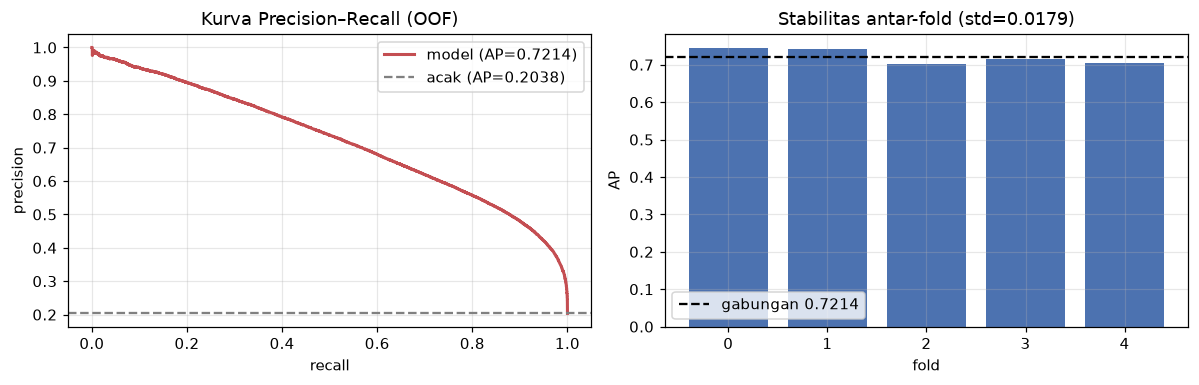

In [21]:
from sklearn.metrics import precision_recall_curve
prec, rec, _ = precision_recall_curve(y, final_oof)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(rec, prec, color="#C44E52", lw=2, label=f"model (AP={final_ap:.4f})")
axes[0].axhline(prev, ls="--", c="gray", label=f"acak (AP={prev:.4f})")
axes[0].set_xlabel("recall"); axes[0].set_ylabel("precision")
axes[0].set_title("Kurva Precision-Recall (OOF)"); axes[0].legend()

per_fold = [average_precision_score(y[b], final_oof[b]) for _, b in FOLDS]
axes[1].bar(range(len(per_fold)), per_fold, color="#4C72B0")
axes[1].axhline(final_ap, ls="--", c="k", label=f"gabungan {final_ap:.4f}")
axes[1].set_xlabel("fold"); axes[1].set_ylabel("AP")
axes[1].set_title(f"Stabilitas antar-fold (std={np.std(per_fold):.4f})"); axes[1].legend()
plt.tight_layout(); plt.show()

## A[9]. Baseline Submission

Baseline submission diekspor sebagai reference artifact untuk membandingkan seluruh eksperimen berikutnya. Kami belum menganggap model ini sebagai final solution karena beberapa karakteristik test, terutama temporal origin shift, scale shift, dan cold-start HUC12, belum sepenuhnya dimodelkan.

File submission tetap kami simpan karena leaderboard behavior memberikan external evidence tambahan terhadap kualitas validation protocol.

In [22]:
# Skor akhir dipetakan ke [0,1] lewat rank; AP invarian terhadap transformasi monoton,
# jadi ini aman sekaligus menjamin rentang yang diminta.
score = rankdata(final_test) / (len(final_test) + 1)

sub = pd.DataFrame({"row_id": test["row_id"].to_numpy(), "label": score})
sample = pd.read_csv(DATA + "sample_submission.csv")
sub = sample[["row_id"]].merge(sub, on="row_id", how="left")

assert len(sub) == len(sample), "jumlah baris tidak sama dengan sample_submission"
assert sub.row_id.is_unique and sub.row_id.tolist() == sample.row_id.tolist(), "row_id tidak cocok"
assert sub.label.notna().all(), "ada label kosong"
assert sub.label.between(0, 1).all(), "label di luar [0,1]"

sub.to_csv("submission_baseline.csv", index=False)
print("submission_baseline.csv ditulis:", sub.shape)
print(sub.head())
print("\nsebaran skor:", sub.label.describe().round(4).to_dict())
print(f"OOF AP akhir: {final_ap:.4f}  (prevalensi {prev:.4f}, lift {final_ap/prev:.2f}x)")

submission_baseline.csv ditulis: (11928, 2)
   row_id     label
0       0  0.622600
1       1  0.454271
2       2  0.634504
3       3  0.880208
4       4  0.482102

sebaran skor: {'count': 11928.0, 'mean': 0.5, 'std': 0.2887, 'min': 0.0001, '25%': 0.25, '50%': 0.5, '75%': 0.75, 'max': 0.9999}
OOF AP akhir: 0.7214  (prevalensi 0.2038, lift 3.54x)


## A[10]. Baseline Findings

Eksperimen awal menunjukkan bahwa performa tidak ditentukan oleh satu hyperparameter atau satu algoritma. Improvement paling konsisten justru berasal dari numerical parsing yang benar, unit consistency, hydrology-aware representation, validation design, dan handling terhadap HUC12 identity.

Temuan ini mengubah arah eksperimen kami. Alih-alih terus memperbesar model, kami berfokus pada reconstruction of temporal structure, test-time scale behavior, cold-start generalization, dan river topology.

# Part I-B. Temporal Reconstruction, Scale Analysis, and Cold-Start Modeling

Bagian ini berpindah dari baseline modeling menuju structural inference terhadap data. Kami merekonstruksi hidden chronology, menguji target mechanism, menganalisis train-test scale shift, membangun temporal-history features, dan merancang specialist strategy untuk HUC12 yang tidak pernah muncul pada training data.

Setiap eksperimen diperlakukan sebagai hypothesis test. Kami mempertahankan negative results karena kegagalan transfer ke leaderboard sering kali memberikan informasi yang lebih penting daripada local CV improvement.

In [23]:
# Bebaskan memori dari objek Bagian A yang tidak dipakai lagi
for _v in ["raw","raw_te","Xnp_imp","Xt_imp","Xnp","Xt_np","m_pi"]:
    globals().pop(_v, None)
gc.collect();

## B[1]. Global Origin Timeline Reconstruction

Setiap origin membawa 12 lag dari monthly time series yang kontinu. Jika origin $A$ berada $d$ bulan setelah origin $B$, sebagian lag harus align secara sistematis:

$$
A_{\mathrm{lag}[d:]}
\approx
B_{\mathrm{lag}[:12-d]}.
$$

Kami mengukur alignment tersebut pada banyak HUC12 dan beberapa hydrological variables, kemudian membangun successor relation antar-origin tanpa menggunakan target label. Hasilnya adalah temporal lineage yang koheren untuk seluruh historical origins.

In [24]:
import itertools, collections

def origin_windows(df, nodes, fam="q_ws_cum_m3"):
    cols = [f"{fam}_lag{l}" for l in LAGS]; piv, mon = {}, {}
    for o, gdf in df[df.id.isin(nodes)].groupby("origin_id"):
        gdf = gdf.drop_duplicates("id").set_index("id").reindex(nodes)
        piv[o] = gdf[cols].to_numpy("float64"); mon[o] = int(gdf["month"].dropna().iloc[0])
    return piv, mon

def window_match(A, B, d):
    """Fraksi nilai identik bila A = B + d bulan (A.lag[d:] vs B.lag[:12-d])."""
    a, b = A[:, d:], B[:, :12 - d]
    ok = np.isfinite(a) & np.isfinite(b) & (np.abs(a) + np.abs(b) > 0)
    if ok.sum() < 200: return 0.0
    return float((np.abs(a[ok] - b[ok]) / np.maximum(np.abs(a[ok]), np.abs(b[ok])) < 1e-4).mean())

t0 = time.time()
tl_nodes = sorted(set(train.id) & set(test.id))[:300]
PIV, MON = {}, {}
for tag, df in (("train", train), ("test", test)):
    p, mo = origin_windows(df, tl_nodes)
    PIV.update({(tag, k): v for k, v in p.items()}); MON.update({(tag, k): v for k, v in mo.items()})
keys = sorted(PIV)
edges = collections.defaultdict(list); match_scores = []
for A, B in itertools.combinations(keys, 2):
    for P_, Q_ in ((A, B), (B, A)):
        d = (MON[P_] - MON[Q_]) % 12
        if d == 0: continue
        f = window_match(PIV[P_], PIV[Q_], d); match_scores.append(f)
        if f > 0.9: edges[P_].append((Q_, d)); edges[Q_].append((P_, -d))

pos, comp, c = {}, {}, 0
for k in keys:
    if k in pos: continue
    pos[k] = 0; comp[k] = c; stack = [k]
    while stack:
        u = stack.pop()
        for v, d in edges[u]:
            if v not in pos: pos[v] = pos[u] - d; comp[v] = c; stack.append(v)
    c += 1

ms = np.array(match_scores)
print(f"{len(ms):,} uji pasangan ({time.time()-t0:.0f}s): kecocokan >90% = {(ms > .9).sum()}, "
      f"antara 10-90% = {((ms > .1) & (ms <= .9)).sum()}  (bimodal: cocok persis atau tidak sama sekali)")
sizes = collections.Counter(comp.values())
print("komponen:", dict(sizes.most_common(6)))
tr_keys = [k for k in keys if k[0] == "train"]
t_min = min(pos[k] for k in tr_keys)
TIME = {k[1]: pos[k] - t_min for k in tr_keys}
tv = np.array(sorted(TIME.values()))
print(f"origin train: {len(TIME)} titik, rentang t={tv.min()}..{tv.max()}, "
      f"celah antar-bulan: {sorted(set(np.diff(tv)))}  -> 168 bulan berurutan (14 tahun)")
for k in [k for k in keys if k[0] == "test"]:
    same = [j for j in tr_keys if comp[j] == comp[k]]
    print(f"  origin test {k[1]:>3} (bulan {MON[k]:>2}): origin train sekomponen = {len(same)}  -> terisolasi")
m0 = int(train.loc[train.origin_id == [o for o, t in TIME.items() if t == 0][0], "month"].iloc[0])
m1 = int(train.loc[train.origin_id == [o for o, t in TIME.items() if t == 167][0], "month"].iloc[0])
print(f"\nbulan di t=0: {m0}, di t=167: {m1}. Origin test yang 'tepat bersebelahan' (t=-12 atau t=179) "
      f"harus berbulan {m0} atau {m1}; bulan test = {sorted(test.month.unique().astype(int))} -> tidak ada.")
train["t"] = train["origin_id"].map(TIME).to_numpy()

27,116 uji pasangan (1s): kecocokan >90% = 1782, antara 10–90% = 0  (bimodal: cocok persis atau tidak sama sekali)
komponen: {4: 168, 0: 1, 1: 1, 2: 1, 3: 1}
origin train: 168 titik, rentang t=0..167, celah antar-bulan: [np.int64(1)]  -> 168 bulan berurutan (14 tahun)
  origin test  14 (bulan  4): origin train sekomponen = 0  -> terisolasi
  origin test  81 (bulan  2): origin train sekomponen = 0  -> terisolasi
  origin test  94 (bulan 12): origin train sekomponen = 0  -> terisolasi
  origin test 169 (bulan 10): origin train sekomponen = 0  -> terisolasi

bulan di t=0: 9, di t=167: 8. Origin test yang 'tepat bersebelahan' (t=-12 atau t=179) harus berbulan 9 atau 8; bulan test = [np.int64(2), np.int64(4), np.int64(10), np.int64(12)] -> tidak ada.


### B[1.1]. Timeline Reconstruction Result

Ke-168 training origins membentuk satu monthly chronology tanpa gap yang berarti. Struktur tersebut dapat dikelompokkan menjadi approximately 14 annual blocks dengan pola Sep-Aug.

Empat test origins tidak memiliki direct temporal overlap pada lag window yang tersedia, sehingga test bukan continuation sederhana yang dapat diselesaikan dengan lookup. Temuan ini memperkuat kebutuhan terhadap true forecasting model.

## B[2]. Target-Mechanism Analysis

Setelah chronology tersedia, kami dapat membandingkan current hydrological state dengan state pada target month secara lebih sistematis. Analisis ini digunakan untuk menguji apakah label lebih dekat dengan demand-driven stress, supply-driven stress, seasonal limitation, atau interaction di antara ketiganya.

Tujuan tahap ini bukan merekonstruksi target secara hard-coded, tetapi mempersempit modeling hypothesis sebelum kami menambah complexity.

In [25]:
def realized_ws_next(df):
    obs = [pd.DataFrame({"id": df.id.values, "t": df.t.values - 1 - k,
                         "ws": df[f"q_ws_cum_m3_lag{k}"].values}) for k in LAGS]
    s = pd.concat(obs).dropna().groupby(["id", "t"]).ws.median()
    return s.reindex(pd.MultiIndex.from_arrays([df.id.values, df.t.values])).to_numpy()

tgt_month = (train["month"].to_numpy().astype(int) % 12) + 1
CLIM_NEXT_TR = CLIM.reindex(train.id.to_numpy()).to_numpy()[np.arange(len(train)), tgt_month - 1]

ws_next_raw = realized_ws_next(train)
dem_next = sum(realized_ws_next(train.assign(**{"q_ws_cum_m3_lag%d" % k: train[f"{f}_lag{k}"] for k in LAGS}))
               for f in ["q_ir_wd_inc_m3", "q_th_wd_inc_m3", "q_ps_wd_inc_m3"])
ok = np.isfinite(ws_next_raw) & (CLIM_NEXT_TR > 0)
print(f"baris train dengan nilai aktual bulan target: {ok.mean():.2%}\n")
cands = {"permintaan / ws  (SUI klasik)": dem_next / (ws_next_raw + 1e-3),
         "−ws":                            -ws_next_raw,
         "−ws / clim_next":                -ws_next_raw / (CLIM_NEXT_TR + 1e-3)}
for k, v in cands.items():
    v = np.where(np.isfinite(v), v, np.nanmedian(v))
    print(f"  {k:<32} AP = {average_precision_score(y[ok], v[ok]):.4f}")
r = ws_next_raw / CLIM_NEXT_TR
print("\naturan  label = [ws_next / clim_next <= thr]  (sebelum perbaikan skala per-id):")
for thr in (0.55, 0.6, 0.65):
    print(f"  thr={thr}: akurasi {((r[ok] <= thr).astype(int) == y[ok]).mean():.4f}")
mis = ok & ((r <= 0.6).astype(int) != y)
print("rasio pada baris yang meleset (kuantil 5/25/50/75/95%):",
      np.round(np.quantile(r[mis], [.05, .25, .5, .75, .95]), 3))

baris train dengan nilai aktual bulan target: 98.96%

  permintaan / ws  (SUI klasik)    AP = 0.2521
  −ws                              AP = 0.3334
  −ws / clim_next                  AP = 0.7221

aturan  label = [ws_next / clim_next <= thr]  (sebelum perbaikan skala per-id):
  thr=0.55: akurasi 0.9381
  thr=0.6: akurasi 0.9661
  thr=0.65: akurasi 0.9359
rasio pada baris yang meleset (kuantil 5/25/50/75/95%): [1.00000e-03 1.00000e-03 1.00000e-03 3.00000e-03 4.89644e+02]


### B[2.0]. Dominant Signal

Diagnostic menunjukkan bahwa target variation lebih kuat terkait supply limitation daripada variation demand semata. Dengan kata lain, kemampuan model membedakan stressed dan non-stressed basins sangat bergantung pada posisi future supply relatif terhadap seasonal reference.

Temuan ini kami gunakan sebagai physical prior. Supervised model tetap diperlukan karena future hydrological state pada test tidak tersedia secara langsung.

In [26]:
def id_scale_levels(tr, te):
    both = pd.concat([tr[["id", "clim_median_now"] + [f"q_ws_cum_m3_lag{l}" for l in LAGS]],
                      te[["id", "clim_median_now"] + [f"q_ws_cum_m3_lag{l}" for l in LAGS]]])
    A = both[[f"q_ws_cum_m3_lag{l}" for l in LAGS]].to_numpy()
    with np.errstate(all="ignore"):
        lv = np.log10(np.nanmedian(np.where(A > 0, A, np.nan), axis=1) / both["clim_median_now"].to_numpy())
    return pd.Series(lv).groupby(both["id"].to_numpy()).median()

def repair_id_scale(tr, te):
    """Faktor per-id dideteksi dari q_ws_cum vs klimatologi (bimodal bersih), diterapkan ke 6 famili."""
    s = id_scale_levels(tr, te)
    k = np.round((s - s.median()) / 3).clip(-1, 1).fillna(0)
    for df in (tr, te):
        fac = (1000.0 ** (-k.reindex(df["id"].to_numpy()).fillna(0).to_numpy())).astype("float32")
        df[LAG_COLS] = df[LAG_COLS].to_numpy("float32") * fac[:, None]
    return tr, te, k

lv = id_scale_levels(train, test) 
dev = (lv - lv.median()).dropna()
print("histogram deviasi log10(ws/clim) per sub-DAS:")
print(pd.cut(dev, [-9, -3.5, -2.5, -1.5, -0.5, 0.5, 1.5, 2.5, 3.5, 9]).value_counts().sort_index().to_string())

# famili lain ikut bergeser untuk id yang sama?
flag = np.round(dev / 3).clip(-1, 1)
both = pd.concat([train, test])
for f, ref in [("q_bf_inc_m3", "inc_aream2"), ("q_ir_wd_inc_m3", "inc_aream2"), ("q_ps_wd_inc_m3", "pop_dec_2020")]:
    B_ = both[[f"{f}_lag{l}" for l in LAGS]].to_numpy()
    with np.errstate(all="ignore"):
        v = np.log10(np.nanmedian(np.where(B_ > 0, B_, np.nan), axis=1) / (both[ref].to_numpy() + 1))
    lvl = pd.Series(v).groupby(both.id.to_numpy()).median()
    print(f"  {f:<16} median level per kelompok id (-1/0/+1):",
          {int(gv): round(float(lvl.reindex(flag.index[flag == gv]).median()), 2) for gv in (-1, 0, 1)})
del both

train, test, ID_SCALE = repair_id_scale(train, test)
print(f"\nsub-DAS diperbaiki: {int((ID_SCALE != 0).sum())} "
      f"({int((ID_SCALE == -1).sum())} dinaikkan x1000, {int((ID_SCALE == 1).sum())} diturunkan x1000)")

WS_NEXT_TR = realized_ws_next(train)
r = WS_NEXT_TR / CLIM_NEXT_TR; ok = np.isfinite(r)
for thr in (0.59, 0.6, 0.61):
    print(f"  aturan label thr={thr}: akurasi {((r[ok] <= thr).astype(int) == y[ok]).mean():.5f}")

histogram deviasi log10(ws/clim) per sub-DAS:
(-9.0, -3.5]       0
(-3.5, -2.5]     105
(-2.5, -1.5]       1
(-1.5, -0.5]       5
(-0.5, 0.5]     2745
(0.5, 1.5]        32
(1.5, 2.5]         0
(2.5, 3.5]        84
(3.5, 9.0]         0
  q_bf_inc_m3      median level per kelompok id (-1/0/+1): {-1: -5.62, 0: -2.7, 1: 0.46}


  q_ir_wd_inc_m3   median level per kelompok id (-1/0/+1): {-1: -6.02, 0: -2.99, 1: -0.06}


  q_ps_wd_inc_m3   median level per kelompok id (-1/0/+1): {-1: -1.96, 0: 0.92, 1: 3.84}



sub-DAS diperbaiki: 190 (106 dinaikkan x1000, 84 diturunkan x1000)


  aturan label thr=0.59: akurasi 0.99377
  aturan label thr=0.6: akurasi 0.99987
  aturan label thr=0.61: akurasi 0.99338


### B[2.0a]. Deterministic Consistency Check

Enam kelompok volume menunjukkan pola scale shift yang konsisten pada ID tertentu. Setelah unit correction, future-supply ratio menjelaskan hampir seluruh training labels, yang memperkuat hipotesis bahwa competition target sangat dekat dengan thresholded water-supply limitation process.

Kami tetap menghindari hard-coded label reconstruction pada final pipeline. Insight tersebut digunakan untuk membangun better features dan validation diagnostics, bukan untuk menggantikan predictive modeling.

## B[2.1]. Test-Time Scale Normalization per HUC12

Eksperimen awal menunjukkan discrepancy yang besar antara local CV dan public leaderboard. Investigasi terhadap test distribution mengindikasikan rescaling feature pada level HUC12, sehingga absolute volume tidak selalu berada pada scale yang sama dengan historical training values.

Kami menggunakan dua treatment. Untuk **seen HUC12**, scale factor dapat dipulihkan dari hubungan terhadap historical climatology. Untuk **cold-start HUC12**, model lebih bergantung pada scale-invariant representation seperti ratio, standardized anomaly, dan topology-derived context.

Secara umum, kami mengutamakan:

$$
z
{}={}
\log
\left(
\frac{x+\varepsilon}
{x_{\mathrm{reference}}+\varepsilon}
\right)
$$

dibanding absolute magnitude ketika historical scale tidak dapat diestimasi secara reliable.

In [27]:
C_TRAIN = train.groupby(["id", train["month"].astype(int)])["clim_median_now"].median()
mt = test["month"].astype(int).to_numpy()
f_now  = np.log10(test["clim_median_now"].to_numpy()
                  / C_TRAIN.reindex(pd.MultiIndex.from_arrays([test["id"], mt])).to_numpy())
f_next = np.log10(test["clim_median_next"].to_numpy()
                  / C_TRAIN.reindex(pd.MultiIndex.from_arrays([test["id"], mt % 12 + 1])).to_numpy())
fac = pd.DataFrame({"id": test["id"], "f_now": f_now, "f_next": f_next})
per_id = fac.groupby("id").agg(f=("f_now", "median"), sd_now=("f_now", "std"), f_next=("f_next", "median")).dropna(subset=["f"])
print(f"sub-DAS test yang dikenal train: {len(per_id)} | sd faktor antar-bulan dalam satu id (median): "
      f"{per_id.sd_now.median():.5f}  | selisih faktor clim_now vs clim_next: {np.median(np.abs(per_id.f - per_id.f_next)):.5f}")
print("sebaran faktor log10 (1/10/50/90/99%):", np.quantile(per_id.f, [.01, .1, .5, .9, .99]).round(3))

# volume ikut diskalakan? permintaan air publik (stabil antar-tahun) adalah uji yang paling bersih
def fam_level(df, fam):
    A = df[[f"{fam}_lag{l}" for l in LAGS]].to_numpy("float64")
    with np.errstate(all="ignore"):
        v = np.nanmedian(np.where(A > 0, A, np.nan), axis=1)
    return pd.Series(np.log10(v)).groupby(df["id"].to_numpy()).median()
for fam in ["q_ps_wd_inc_m3", "q_ws_cum_m3"]:
    shift = (fam_level(test, fam) - fam_level(train, fam)).reindex(per_id.index).dropna()
    fid = per_id.f.reindex(shift.index)
    print(f"  {fam:<16} |pergeseran level test-train| median = {np.median(np.abs(shift)):.3f}; "
          f"setelah dikurangi faktor = {np.median(np.abs(shift - fid)):.3f}")
for c in ["inc_aream2", "pop_dec_2020"]:
    r_ = np.log10(test.groupby("id")[c].median() / train.groupby("id")[c].median()).dropna()
    print(f"  {c:<16} |log10 test/train| > 0.005: {np.mean(np.abs(r_) > 0.005):.3f}  (tidak diskalakan)")

# kembalikan skala test untuk id yang dikenal
TEST_SCALE = 10.0 ** per_id.f
sc = TEST_SCALE.reindex(test["id"].to_numpy()).fillna(1.0).to_numpy().astype("float32")
test[LAG_COLS] = test[LAG_COLS].to_numpy("float32") / sc[:, None]
for c in ("clim_median_now", "clim_median_next"):
    test[c] = (test[c].to_numpy() / sc).astype("float32")
UNSEEN_TEST = ~test["id"].isin(set(train["id"])).to_numpy()
print(f"\nskala test dikembalikan untuk {int((~UNSEEN_TEST).sum()):,} baris; "
      f"{int(UNSEEN_TEST.sum()):,} baris (id baru) faktornya tidak bisa dipulihkan")

def build_clim_table_v2(tr, te):
    """Klimatologi: id train dari train saja; id baru dari clim_now & clim_next test (8 dari 12 bulan),
    sisanya diinterpolasi secara sirkular di ruang log."""
    new = te[~te["id"].isin(set(tr["id"]))]
    parts = [pd.DataFrame({"id": tr["id"], "m": tr["month"].astype(int), "c": tr["clim_median_now"]}),
             pd.DataFrame({"id": new["id"], "m": new["month"].astype(int), "c": new["clim_median_now"]}),
             pd.DataFrame({"id": new["id"], "m": new["month"].astype(int) % 12 + 1, "c": new["clim_median_next"]})]
    t_ = pd.concat(parts).groupby(["id", "m"])["c"].median().unstack().reindex(columns=range(1, 13))
    L = np.log(t_.clip(lower=1e-6))
    L3 = pd.concat([L, L, L], axis=1); L3.columns = range(36)
    L3 = L3.interpolate(axis=1, limit_direction="both")
    return np.exp(L3.iloc[:, 12:24]).set_axis(range(1, 13), axis=1).astype("float32")
CLIM = build_clim_table_v2(train, test)
print("tabel klimatologi dibangun ulang:", CLIM.shape, "| NaN:", int(CLIM.isna().sum().sum()))
z_te = np.log10(test["q_ws_cum_m3_lag0"] / test["clim_median_now"])
print("median log10(ws0/clim_now) per origin test:", z_te.groupby(test["origin_id"]).median().round(3).to_dict())

sub-DAS test yang dikenal train: 2187 | sd faktor antar-bulan dalam satu id (median): 0.00000  | selisih faktor clim_now vs clim_next: 0.00000
sebaran faktor log10 (1/10/50/90/99%): [-0.617 -0.469 -0.003  0.553  0.627]


  q_ps_wd_inc_m3   |pergeseran level test-train| median = 0.330; setelah dikurangi faktor = 0.043
  q_ws_cum_m3      |pergeseran level test-train| median = 0.270; setelah dikurangi faktor = 0.143
  inc_aream2       |log10 test/train| > 0.005: 0.000  (tidak diskalakan)
  pop_dec_2020     |log10 test/train| > 0.005: 0.000  (tidak diskalakan)



skala test dikembalikan untuk 8,784 baris; 3,144 baris (id baru) faktornya tidak bisa dipulihkan
tabel klimatologi dibangun ulang: (2982, 12) | NaN: 0
median log10(ws0/clim_now) per origin test: {14: 0.15299999713897705, 81: 0.16500000655651093, 94: -0.11800000071525574, 169: 0.026000000536441803}


## B[3]. Upstream Physics and Network Aggregation

Kami memperbaiki upstream aggregation agar tetap konsisten antara train dan test network support. Feature extraction dilakukan ulang setelah scale correction, kemudian aggregation dibatasi pada valid subnetwork untuk mencegah perbedaan graph size menjadi source of systematic bias.

Kami juga menambahkan baseflow-floor representation. Secara domain, persistent baseflow dapat bertindak sebagai buffer terhadap seasonal water stress, sehingga informasi ini berbeda dari short-lived quickflow response.

In [28]:
CORE_MASK = np.zeros(N_NODE, bool); CORE_MASK[CORE] = True
# Menjalankan sel ini dua kali dulu membuat wrapper menangkap dirinya
# sendiri (RecursionError). Sumber aslinya dibekukan sekali saja.
_accumulate_all = globals().get("_accumulate_all", accumulate)
def accumulate(values, node_idx, origin, to=TO, order=ORDER, nnode=N_NODE):
    """Akumulasi hulu->hilir hanya atas simpul CORE, agar definisinya identik di train & test."""
    v = np.where(CORE_MASK[node_idx], np.nan_to_num(values), 0.0)
    return _accumulate_all(v, node_idx, origin, to, order, nnode)

def mask_noncore_neighbours(df, Xf):
    ni = df["id"].map(NODE_IDX).to_numpy(); dn1 = TO[ni]
    dn2 = np.where(dn1 >= 0, TO[np.maximum(dn1, 0)], -1)
    for col, hop in (("dn_anom", dn1), ("dn_sui", dn1), ("dn2_anom", dn2)):
        bad = (hop >= 0) & ~CORE_MASK[np.maximum(hop, 0)]
        Xf.loc[bad, col] = np.nan
    return Xf

t0 = time.time()
XB      = featurize(train)
XB_test = mask_noncore_neighbours(test, featurize(test))
print(f"featurize ulang {time.time()-t0:.1f}s | {XB.shape} {XB_test.shape}")

def exact_anomalies(df, Xf):
    m = df["month"].to_numpy().astype(int); ri = np.arange(len(df))
    C = CLIM.reindex(df["id"].to_numpy()).to_numpy()
    Z = np.column_stack([np.clip(np.log(df[f"q_ws_cum_m3_lag{k}"].to_numpy() + 1e-6)
                                 - np.log(C[ri, (m - 1 - k) % 12] + 1e-6), -8, 4) for k in LAGS])
    E = pd.DataFrame(Z, columns=[f"z{k}" for k in LAGS], index=df.index)
    E["dz1"] = E.z0 - E.z1; E["dz2"] = E.z1 - E.z2
    E["z_ly_tgt"] = E.z11; E["z_ly_tgt2"] = E.z10; E["z0_minus_ly"] = E.z0 - E.z11
    c_next = np.exp(Xf["log_clim_next"].to_numpy()) - 1
    E["margin_now"] = np.log(df["q_ws_cum_m3_lag0"].to_numpy() + 1e-6) - np.log(c_next + 1e-6) - np.log(0.6)
    return E.astype("float32")

def physics_features(df, Xf):
    """Komponen baseflow/quickflow hulu (akumulasi CORE) dalam satuan ambang 0.6*clim bulan target."""
    ni = df["id"].map(NODE_IDX).to_numpy(); og = df["origin_id"].to_numpy()
    A = lambda v: accumulate(v, ni, og)
    abf = np.column_stack([A(df[f"q_bf_inc_m3_lag{k}"].to_numpy()) for k in LAGS])
    aqf = np.column_stack([A(df[f"q_qf_inc_m3_lag{k}"].to_numpy()) for k in LAGS])
    asup = abf + aqf
    c_next = np.exp(Xf["log_clim_next"].to_numpy()) - 1
    thr = np.log(0.6 * c_next + 1e-6)
    ws0 = df["q_ws_cum_m3_lag0"].to_numpy()
    o = pd.DataFrame(index=df.index)
    o["up_bf_frac0"] = abf[:, 0] / (asup[:, 0] + 1e-3); o["up_bf_frac1"] = abf[:, 1] / (asup[:, 1] + 1e-3)
    o["up_bf_frac_chg"] = o.up_bf_frac0 - o.up_bf_frac1
    o["up_bf_frac_m12"] = abf.sum(1) / (asup.sum(1) + 1e-3)
    o["ws_cov0"] = np.log((ws0 + 1) / (asup[:, 0] + 1))
    rec = np.clip((abf[:, 0] + 1) / (abf[:, 1] + 1), 0.05, 5)
    o["up_bf_rec"] = np.log(rec)
    floor = ws0 * o.up_bf_frac0.to_numpy()
    o["bf_floor_margin"] = np.log(floor + 1e-6) - thr
    o["bf_floor_rec_margin"] = np.log(floor * np.minimum(rec, 1.0) + 1e-6) - thr
    need = np.maximum(0.6 * c_next - floor * np.minimum(rec, 1.0), 0)
    qscale = ws0 / (asup[:, 0] + 1e-3)
    o["need_vs_qf_ly"]    = np.log1p(need) - np.log1p(aqf[:, 11] * qscale)
    o["need_vs_qf_m12"]   = np.log1p(need) - np.log1p(aqf.mean(1) * qscale)
    o["need_vs_qf_max12"] = np.log1p(need) - np.log1p(aqf.max(1) * qscale)
    o["qf_share_ly"] = aqf[:, 11] / (asup[:, 11] + 1e-3)
    o["up_nodes_core"] = A(np.ones(len(df)))
    for k in range(3):
        wsk = df[f"q_ws_cum_m3_lag{k}"].to_numpy(); sc = wsk / (asup[:, k] + 1e-3)
        o[f"m_bf{k}"] = np.log(abf[:, k] * sc + 1e-6) - thr
        o[f"m_qf{k}"] = np.log(aqf[:, k] * sc + 1e-6) - thr
    o["rec_bf01"] = np.log((abf[:, 0] + 1) / (abf[:, 1] + 1))
    o["rec_bf12"] = np.log((abf[:, 1] + 1) / (abf[:, 2] + 1))
    o["rec_bf23"] = np.log((abf[:, 2] + 1) / (abf[:, 3] + 1))
    o["rec_qf01"] = np.log((aqf[:, 0] + 1) / (aqf[:, 1] + 1))
    rmed = np.minimum(np.exp(np.median(np.c_[o.rec_bf01, o.rec_bf12, o.rec_bf23], axis=1)), 1.0)
    o["m_bf_proj_med"] = o.m_bf0 + np.log(rmed)
    o["m_bf_proj2"] = o.m_bf0 + 2 * np.minimum(o.rec_bf01, 0)
    # untuk riwayat hidrograf (B5): margin quickflow di bulan origin sendiri
    o["_abf0"] = abf[:, 0]
    o["_qfm_own"] = (np.log(aqf[:, 0] * (ws0 / (asup[:, 0] + 1e-3)) + 1e-6)
                     - np.log(0.6 * df["clim_median_now"].to_numpy() + 1e-6))
    return o.astype("float32")

t0 = time.time()
EB, EB_test = exact_anomalies(train, XB), exact_anomalies(test, XB_test)
PB, PB_test = physics_features(train, XB), physics_features(test, XB_test)
print(f"anomali eksak + fisika {time.time()-t0:.1f}s | {EB.shape[1]} + {PB.shape[1]} fitur")
v = PB["bf_floor_rec_margin"].fillna(0).to_numpy()
print(f"AP satu fitur bf_floor_rec_margin = {average_precision_score(y, -v):.4f}")

featurize ulang 2.7s | (368928, 136) (11928, 136)


anomali eksak + fisika 4.9s | 18 + 27 fitur
AP satu fitur bf_floor_rec_margin = 0.3963


## B[4]. Time-Block Validation

Historical timeline dibagi menjadi contiguous temporal blocks dan validation selalu ditempatkan setelah training period. Untuk mengurangi temporal leakage, kami menggunakan buffer di sekitar validation window dan mengevaluasi improvement melalui paired AP difference.

Uncertainty tidak hanya dibaca dari satu fold. Kami juga menggunakan bootstrap pada level origin agar confidence interval lebih merepresentasikan variability antar-hydrological regime.

In [29]:
T_TR = train["t"].to_numpy()
TEST_MONTHS = np.isin(train["month"].to_numpy().astype(int), sorted(test["month"].unique().astype(int)))

def blocked_folds(tvec, k=5, gap=12):
    out = []
    for blk in np.array_split(np.unique(tvec), k):
        lo, hi = blk.min(), blk.max()
        near = (tvec >= lo - gap) & (tvec <= hi + gap)
        out.append((np.where(~near)[0], np.where(np.isin(tvec, blk))[0]))
    return out
BFOLDS = blocked_folds(T_TR)

def paired_ci(y_, pa, pb, g_, n=1000, seed=0):
    """CI 95% bootstrap atas origin untuk selisih AP (b - a)."""
    ug = np.unique(g_); idx = {o: np.where(g_ == o)[0] for o in ug}
    r = np.random.default_rng(seed); d = []
    for _ in range(n):
        sel = np.concatenate([idx[o] for o in r.choice(ug, len(ug))])
        d.append(average_precision_score(y_[sel], pb[sel]) - average_precision_score(y_[sel], pa[sel]))
    d = np.asarray(d); return d.mean(), np.quantile(d, .025), np.quantile(d, .975)

def report(name, p, ref=None, ref_name="ref"):
    s = (f"{name:<34} AP={average_precision_score(y, p):.4f}  "
         f"AP_bulan-test={average_precision_score(y[TEST_MONTHS], p[TEST_MONTHS]):.4f}")
    if ref is not None:
        m, lo, hi = paired_ci(y[TEST_MONTHS], ref[TEST_MONTHS], p[TEST_MONTHS], groups[TEST_MONTHS], 400)
        s += f"  | vs {ref_name}: {m:+.4f} [{lo:+.4f}, {hi:+.4f}]"
    print(s)

for k, (a, b) in enumerate(BFOLDS):
    print(f"blok {k}: validasi t={T_TR[b].min():>3}..{T_TR[b].max():>3} ({len(np.unique(T_TR[b]))} origin) | "
          f"train {len(a):,} baris (buffer ±12 bulan dibuang)")

LGB_REG = dict(objective="binary", metric="average_precision", learning_rate=0.02, num_leaves=31,
               min_data_in_leaf=500, feature_fraction=0.3, bagging_fraction=0.7, bagging_freq=1,
               lambda_l2=30, verbosity=-1, num_threads=0, seed=SEED)

def cv_blocked(make_mats, params=LGB_REG, rounds=6000):
    oof = np.zeros(len(y)); its = []
    for i, (a, b) in enumerate(BFOLDS):
        Xa, Xb = make_mats(i, a, b)
        m = lgb.train(params, lgb.Dataset(Xa, y[a]), rounds, valid_sets=[lgb.Dataset(Xb, y[b])],
                      callbacks=[lgb.early_stopping(250, verbose=False)])
        oof[b] = m.predict(Xb, num_iteration=m.best_iteration); its.append(m.best_iteration)
    return oof, its

# baseline Bagian A (fitur lama, param lama) di bawah CV acak vs blok-waktu
t0 = time.time()
oof_rand = RESULTS["LightGBM"]["oof"]
oof_base_blk, _ = cv_blocked(lambda i, a, b: (X.iloc[a], X.iloc[b]), params=LGB_PARAMS, rounds=4000)
report("baseline, GroupKFold acak", oof_rand)
report("baseline, CV blok-waktu", oof_base_blk)
per_fold = [average_precision_score(y[b], oof_base_blk[b]) for _, b in BFOLDS]
print(f"AP per blok waktu: {np.round(per_fold, 4).tolist()}  ({time.time()-t0:.0f}s)")

blok 0: validasi t=  0.. 33 (34 origin) | train 267,912 baris (buffer ±12 bulan dibuang)
blok 1: validasi t= 34.. 67 (34 origin) | train 241,560 baris (buffer ±12 bulan dibuang)
blok 2: validasi t= 68..101 (34 origin) | train 241,560 baris (buffer ±12 bulan dibuang)
blok 3: validasi t=102..134 (33 origin) | train 243,756 baris (buffer ±12 bulan dibuang)
blok 4: validasi t=135..167 (33 origin) | train 270,108 baris (buffer ±12 bulan dibuang)


baseline, GroupKFold acak          AP=0.7153  AP_bulan-test=0.7172
baseline, CV blok-waktu            AP=0.7125  AP_bulan-test=0.7184
AP per blok waktu: [0.7811, 0.6375, 0.6841, 0.6056, 0.7651]  (145s)


## B[5]. HUC12 Temporal-History Features

Kami membangun summary representation dari historical trajectory setiap HUC12 untuk menangkap persistence, volatility, dan directional change. Feature family mencakup autoregressive anomalies, seasonal variability, trend, serta upstream temporal dynamics.

Salah satu bentuk standardized deviation yang kami gunakan adalah:

$$
z_{i,t}
{}={}
\frac{x_{i,t}-\mu_{i,\mathrm{season}}}
{\sigma_{i,\mathrm{season}}+\varepsilon}.
$$

Representation ini mengukur seberapa ekstrem current state dibanding historical seasonal behavior pada basin yang sama.

In [30]:
THR = np.log(0.6)

def z_panel(df, tvec):
    """Deret anomali bulanan z[id, tau] = log(ws/clim) dari semua window lag."""
    rows = []
    for k in LAGS:
        rows.append(pd.DataFrame({"id": df.id.values, "tau": tvec - k,
                                  "cal": ((df.month.values.astype(int) - 1 - k) % 12) + 1,
                                  "ws": df[f"q_ws_cum_m3_lag{k}"].values}))
    D = pd.concat(rows).dropna().groupby(["id", "tau"]).agg(ws=("ws", "median"), cal=("cal", "first")).reset_index()
    c = CLIM.to_numpy()[CLIM.index.get_indexer(D.id), D.cal.values - 1]
    D["z"] = np.clip(np.log(D.ws + 1e-6) - np.log(c + 1e-6), -8, 4)
    return D[np.isfinite(D.z) & (c > 0)]

def z_pairs(D):
    """(id, tau, cal, z_{tau-1}, z_tau, z_{tau+1})"""
    P = D[["id", "tau", "z", "cal"]]
    A = P.rename(columns={"z": "zp"}); A = A.assign(tau=A.tau + 1)
    B = P.rename(columns={"z": "zn"}); B = B.assign(tau=B.tau - 1)
    return P.merge(A[["id", "tau", "zp"]], on=["id", "tau"], how="left").merge(B[["id", "tau", "zn"]], on=["id", "tau"])

def hydro_pairs(df, tvec, ph):
    """(id, tau, bulan target, resesi baseflow tau->tau+1, margin quickflow di tau+1)."""
    k = pd.DataFrame({"id": df.id.values, "t": tvec, "abf0": ph["_abf0"].values, "qfm": ph["_qfm_own"].values})
    nx = k.assign(t=k.t - 1)
    M = k[["id", "t", "abf0"]].merge(nx, on=["id", "t"], how="left", suffixes=("", "_n"))
    H = pd.DataFrame({"id": df.id.values, "tau": tvec, "tc": (df.month.values.astype(int) % 12) + 1,
                      "krec": np.log((M.abf0_n.values + 1) / (M.abf0.values + 1)), "qfm": M.qfm.values})
    return H[np.isfinite(H.krec) | np.isfinite(H.qfm)]

def _drop(H, excl):
    for lo, hi in excl:
        H = H[~((H.tau + 1 >= lo) & (H.tau <= hi))]
    return H

DYN_COLS = ["dyn_pred", "dyn_sig", "dyn_margin", "dyn_b", "dyn_base", "dyn_zsd", "dyn_seas", "dyn_znow_std"]
SE_COLS  = ["se_rate", "se_mu", "se_sd", "se_margin", "se_now_pct", "se_rate_nb"]
AN_COLS  = ["an_p", "an_w", "an_mu", "an_sd", "an_p1", "an_p_ns"]
HY_COLS  = ["hy_krec", "hy_krec_sd", "hy_floor", "hy_qf_q25", "hy_qf_q50",
            "hy_need_minus_q25", "hy_need_minus_q50", "hy_p_qf_short"]
HIST_COLS = DYN_COLS + SE_COLS + AN_COLS + HY_COLS

def dyn_block(Hz, q):
    Q = Hz.dropna(subset=["zn"]); g_ = Q.groupby("id")
    mz, mz1 = g_.z.mean(), g_.zn.mean(); var = g_.z.var(ddof=0)
    cov = (Q.z - Q.id.map(mz)) * (Q.zn - Q.id.map(mz1))
    b = (cov.groupby(Q.id).mean() / (var + 1e-3)).clip(-0.5, 1.5); a = mz1 - b * mz
    res = Q.zn - (Q.id.map(a) + Q.id.map(b) * Q.z)
    tc = (Q.cal % 12) + 1
    sig = res.groupby(Q.id).std()
    sr = res.groupby([Q.id, tc]).agg(["sum", "count"]); seas = sr["sum"] / (sr["count"] + 3)
    ssig = res.groupby([Q.id, tc]).std()
    base = (Q.zn <= THR).groupby(Q.id).mean()
    ix = pd.MultiIndex.from_arrays([q["id"], q["tc"]])
    se = np.nan_to_num(seas.reindex(ix).to_numpy()); ss = ssig.reindex(ix).to_numpy()
    A_, B_, S_ = a.reindex(q["id"]).to_numpy(), b.reindex(q["id"]).to_numpy(), sig.reindex(q["id"]).to_numpy()
    pred = A_ + B_ * q["z"] + se
    s = np.where(np.isfinite(ss) & (ss > 0.02), 0.5 * ss + 0.5 * S_, S_)
    zsd = np.sqrt(var.reindex(q["id"]).to_numpy())
    return np.c_[pred, s, (THR - pred) / (s + 1e-3), B_, base.reindex(q["id"]).to_numpy(), zsd, se,
                 (q["z"] - mz.reindex(q["id"]).to_numpy()) / (zsd + 1e-3)]

def season_block(Hz, q, k=4.0):
    H = Hz.dropna(subset=["zn"]).assign(tc=lambda d: (d.cal % 12) + 1, yy=lambda d: (d.zn <= THR).astype(float))
    gi = H.groupby("id"); idr, idmu, idsd = gi.yy.mean(), gi.zn.mean(), gi.zn.std()
    gs = H.groupby(["id", "tc"]).agg(n=("yy", "size"), s=("yy", "sum"), mu=("zn", "mean"), sd=("zn", "std"))
    G_ = gs.reindex(pd.MultiIndex.from_arrays([q["id"], q["tc"]]))
    n, s = G_.n.fillna(0).to_numpy(), G_.s.fillna(0).to_numpy(); r0 = idr.reindex(q["id"]).to_numpy()
    mu = np.where(n >= 3, G_.mu.to_numpy(), idmu.reindex(q["id"]).to_numpy())
    sd = np.where(n >= 3, G_.sd.to_numpy(), idsd.reindex(q["id"]).to_numpy())
    nb_s = np.zeros(len(n)); nb_n = np.zeros(len(n))
    for d in (-1, 0, 1):
        Gd = gs.reindex(pd.MultiIndex.from_arrays([q["id"], ((q["tc"] - 1 + d) % 12) + 1]))
        nb_s += Gd.s.fillna(0).to_numpy(); nb_n += Gd.n.fillna(0).to_numpy()
    srt = H.groupby(["id", "cal"]).z.apply(np.sort)
    arr = srt.reindex(pd.MultiIndex.from_arrays([q["id"], q["cal"]])).to_numpy()
    pct = np.array([np.searchsorted(a_, z_) / len(a_) if isinstance(a_, np.ndarray) and len(a_) else np.nan
                    for a_, z_ in zip(arr, q["z"])])
    return np.c_[(s + k * r0) / (n + k), mu, sd, (THR - mu) / (sd + 1e-3), pct, (nb_s + k * r0) / (nb_n + k)]

def analog_block(Hz, q, bw=0.35, bwp=0.6):
    out = np.full((len(q["id"]), len(AN_COLS)), np.nan)
    Hg = {k: v for k, v in Hz.dropna(subset=["zn"]).groupby("id")}
    for gid, ii in pd.Series(np.arange(len(q["id"]))).groupby(q["id"]).groups.items():
        h = Hg.get(gid); ii = np.asarray(ii)
        if h is None or len(h) < 12: continue
        hc, hz, hn = h.cal.values, h.z.values, h.zn.values
        hzp = np.nan_to_num(h.zp.values, nan=float(np.nanmean(hz))); hy = (hn <= THR).astype(float)
        dc = np.abs(((q["cal"][ii][:, None] - hc[None, :]) + 6) % 12 - 6)
        ws_ = np.exp(-0.5 * dc ** 2)
        wz = np.exp(-0.5 * ((q["z"][ii][:, None] - hz[None, :]) / bw) ** 2)
        wp = np.exp(-0.5 * ((np.nan_to_num(q["zp"][ii])[:, None] - hzp[None, :]) / bwp) ** 2)
        W, Wn = ws_ * wz * wp, ws_ * wz; sw, swn = W.sum(1) + 1e-6, Wn.sum(1) + 1e-6; pr = hy.mean()
        out[ii, 0] = (W @ hy + pr) / (sw + 1); out[ii, 1] = sw; out[ii, 2] = (W @ hn) / sw
        out[ii, 3] = np.sqrt(np.maximum((W @ hn ** 2) / sw - out[ii, 2] ** 2, 0))
        out[ii, 4] = (Wn @ hy + pr) / (swn + 1); out[ii, 5] = (wz @ hy + pr) / (wz.sum(1) + 1)
    return out

def hydro_block(Hh, q):
    out = np.full((len(q["id"]), len(HY_COLS)), np.nan)
    pool_k = {m: np.nanmedian(Hh.krec.values[Hh.tc.values == m]) for m in range(1, 13)}
    Hg = {k: (v.tc.values, v.krec.values, v.qfm.values) for k, v in Hh.groupby("id")}
    for gid, ii in pd.Series(np.arange(len(q["id"]))).groupby(q["id"]).groups.items():
        ii = np.asarray(ii); tc = q["tc"][ii]; mb = q["mbf0"][ii]; h = Hg.get(gid)
        if h is None:
            out[ii, 0] = [pool_k[m] for m in tc]; out[ii, 2] = mb + out[ii, 0]; continue
        hc, hk, hq = h
        for m in np.unique(tc):
            s = tc == m; sel = np.abs(((m - hc) + 6) % 12 - 6) <= 1
            kk = hk[sel]; kk = kk[np.isfinite(kk)]; qv = hq[sel]; qv = qv[np.isfinite(qv)]
            km = np.median(kk) if len(kk) >= 3 else pool_k[m]; idx = ii[s]; fl = mb[s] + km
            out[idx, 0] = km; out[idx, 1] = np.std(kk) if len(kk) >= 3 else np.nan; out[idx, 2] = fl
            if len(qv) >= 3:
                q25, q50 = np.quantile(qv, [.25, .5]); need = np.log(np.clip(1 - np.exp(fl), 1e-6, None))
                out[idx, 3], out[idx, 4] = q25, q50
                out[idx, 5], out[idx, 6] = need - q25, need - q50
                out[idx, 7] = (qv[None, :] <= need[:, None]).mean(1) * (np.exp(fl) < 1)
    return out

def history_features(Hz, Hh, q, excl=()):
    Hz2, Hh2 = _drop(Hz, excl), _drop(Hh, excl)
    return np.c_[dyn_block(Hz2, q), season_block(Hz2, q), analog_block(Hz2, q), hydro_block(Hh2, q)].astype("float32")

def query(df, E_, P_):
    m = df["month"].to_numpy().astype(int)
    return {"id": df["id"].to_numpy(), "cal": m, "tc": (m % 12) + 1, "z": E_["z0"].to_numpy(),
            "zp": E_["z1"].to_numpy(), "mbf0": P_["m_bf0"].to_numpy()}

def take(q, rows): return {k: v[rows] for k, v in q.items()}

def nested_history(Hz, Hh, q, tvec, rows, excl=(), n_blocks=6):
    """Fitur riwayat out-of-sample untuk `rows`: tiap blok waktu dihitung tanpa dirinya sendiri (±12)."""
    out = np.full((len(rows), len(HIST_COLS)), np.nan, "float32"); tt = tvec[rows]
    for blk in np.array_split(np.unique(tt), n_blocks):
        sel = np.isin(tt, blk)
        out[sel] = history_features(Hz, Hh, take(q, rows[sel]), list(excl) + [(blk.min() - 12, blk.max() + 13)])
    return out

t0 = time.time()
HZ = z_pairs(z_panel(train, T_TR))
HH = hydro_pairs(train, T_TR, PB)
Q_TR = query(train, EB, PB)
print(f"panel riwayat: {len(HZ):,} pasangan z, {len(HH):,} pasangan hidrograf ({time.time()-t0:.1f}s)")

HIST_FOLDS = []
for i, (a, b) in enumerate(BFOLDS):
    lo, hi = T_TR[b].min(), T_TR[b].max(); ex = [(lo - 12, hi + 13)]
    Hb = history_features(HZ, HH, take(Q_TR, b), ex)
    Ha = nested_history(HZ, HH, Q_TR, T_TR, a, ex)
    HIST_FOLDS.append((Ha, Hb))
    print(f"  blok {i}: fitur riwayat siap ({time.time()-t0:.0f}s) | AP satu fitur dyn_margin (validasi) = "
          f"{average_precision_score(y[b], np.nan_to_num(Hb[:, 2], nan=-9)):.4f}")

panel riwayat: 390,769 pasangan z, 366,732 pasangan hidrograf (0.6s)


  blok 0: fitur riwayat siap (15s) | AP satu fitur dyn_margin (validasi) = 0.6655


  blok 1: fitur riwayat siap (30s) | AP satu fitur dyn_margin (validasi) = 0.5159


  blok 2: fitur riwayat siap (45s) | AP satu fitur dyn_margin (validasi) = 0.5566


  blok 3: fitur riwayat siap (61s) | AP satu fitur dyn_margin (validasi) = 0.4671


  blok 4: fitur riwayat siap (76s) | AP satu fitur dyn_margin (validasi) = 0.6587


## B[6]. Audit of Auxiliary Features

Seluruh `aux_*` columns diuji secara empiris melalui univariate AP, correlation structure, dan ablation. Mayoritas feature tersebut tidak memberikan ranking signal yang berarti di luar base prevalence, sementara beberapa lainnya dapat dijelaskan sebagai shifted representation dari hydrological variables yang sudah tersedia.

Karena itu, auxiliary columns tidak dipertahankan sebagai core final features. Keputusan ini didasarkan pada evidence, bukan asumsi bahwa auxiliary variable selalu tidak berguna.

In [31]:
aux_cols = [f"aux_noise_{i:02d}" for i in (0, 5, 10, 15)] + [f"aux_twin_unit_{i:02d}" for i in (2, 7, 12)] + \
           [f"aux_fake_mm_{i:02d}" for i in (4, 9, 14)] + [f"aux_constant_{i:02d}" for i in (1, 6, 11, 16)] + \
           [f"aux_junk_id_{i:02d}" for i in (3, 8, 13)]
R = pd.read_csv(DATA + "train.csv", usecols=["id", "origin_id"] + aux_cols, dtype=str)
R["id"] = R["id"].str.strip().str.lower(); R["origin_id"] = R["origin_id"].astype(int)
R = R.drop_duplicates(["id", "origin_id"])
R = train[["id", "origin_id"]].astype({"origin_id": int}).merge(R, on=["id", "origin_id"], how="left")
rows = []
for c in aux_cols:
    v = (pd.to_numeric(R[c].str.extract(r"(\d+)")[0], errors="coerce") if "junk" in c
         else parse_numeric(R[c])).to_numpy(dtype="float64")
    v = np.where(np.isfinite(v), v, np.nanmedian(v))
    src = ""
    if "twin" in c:
        unscaled = (ID_SCALE.reindex(train["id"].to_numpy()).fillna(0).to_numpy() == 0)
        def frac(lc):
            src_ = train[lc].to_numpy(); okm = unscaled & (src_ > 0) & np.isfinite(v)
            return np.mean(np.abs(v[okm] * 1000 / src_[okm] - 1) < 0.01) if okm.any() else 0.0
        best = max(((frac(lc), lc) for lc in LAG_COLS), key=lambda t_: t_[0])
        src = f"{best[1]} ({best[0]:.0%} cocok, nilai positif)"
    rows.append((c, len(np.unique(v)), max(average_precision_score(y, v), average_precision_score(y, -v)), src))
aux_tab = pd.DataFrame(rows, columns=["kolom", "n_unik", "AP satu fitur (arah terbaik)", "salinan dari"])
print(f"prevalensi = {y.mean():.4f}\n"); print(aux_tab.round(4).to_string(index=False))
del R

prevalensi = 0.2038

           kolom  n_unik  AP satu fitur (arah terbaik)                                   salinan dari
    aux_noise_00  330460                        0.2045                                               
    aux_noise_05  330687                        0.2044                                               
    aux_noise_10  330671                        0.2039                                               
    aux_noise_15  330172                        0.2047                                               
aux_twin_unit_02   54791                        0.2070 q_ir_wd_inc_m3_lag0 (96% cocok, nilai positif)
aux_twin_unit_07  297245                        0.2336    q_qf_inc_m3_lag0 (95% cocok, nilai positif)
aux_twin_unit_12  329928                        0.2570    q_bf_inc_m3_lag0 (98% cocok, nilai positif)
  aux_fake_mm_04  246672                        0.2074                                               
  aux_fake_mm_09  246499                        0.2075       

## B[7]. Incremental Contribution Ladder

Setiap feature family ditambahkan secara bertahap dan dievaluasi pada validation geometry yang sama. Kami mengukur incremental contribution sebagai:

$$
\Delta AP_k
{}={}
AP(\mathcal{F}_{1:k})
{}-{}
AP(\mathcal{F}_{1:k-1}).
$$

Sebuah feature family hanya dianggap berguna apabila improvement tidak bergantung pada satu fold tertentu. Pendekatan ini membantu kami membedakan signal yang robust dari improvement yang muncul karena regime-specific overfitting.

In [32]:
DYN_IDX = [HIST_COLS.index(c) for c in DYN_COLS]
PB_COLS = [c for c in PB.columns if not c.startswith("_")]

def assemble(i, a, b, parts):
    Ha, Hb = HIST_FOLDS[i]
    fa, fb = [XB.iloc[a]], [XB.iloc[b]]
    if "E" in parts: fa.append(EB.iloc[a]); fb.append(EB.iloc[b])
    if "P" in parts: fa.append(PB[PB_COLS].iloc[a]); fb.append(PB[PB_COLS].iloc[b])
    Xa, Xb = pd.concat(fa, axis=1), pd.concat(fb, axis=1)
    if "dyn" in parts:
        Xa[DYN_COLS] = Ha[:, DYN_IDX]; Xb[DYN_COLS] = Hb[:, DYN_IDX]
    if "hist" in parts:
        Xa[HIST_COLS] = Ha; Xb[HIST_COLS] = Hb
    return Xa, Xb

def select_features(Xa, ya, frac=0.6, seed=0):
    """Seleksi per-fold: importance dari model cepat pada data train fold itu saja."""
    m0 = lgb.train({**LGB_REG, "seed": seed}, lgb.Dataset(Xa, ya), 600)
    imp = pd.Series(m0.feature_importance("gain"), Xa.columns).sort_values(ascending=False)
    return list(imp.index[: int(len(imp) * frac)])

LADDER = {}
steps = [
    ("1. baseline Bagian A (blok-waktu)", None),
    ("2. + skala per-id, param teregularisasi", set()),
    ("3. + dinamika per-id (dyn_*)", {"dyn"}),
    ("4. + anomali eksak & fisika hulu", {"dyn", "E", "P"}),
    ("5. + musiman, analog, hidrograf", {"hist", "E", "P"}),
]
prev = None; t0 = time.time()
for name, parts in steps:
    if parts is None:
        o = oof_base_blk
    else:
        o, _ = cv_blocked(lambda i, a, b, p=parts: assemble(i, a, b, p))
    LADDER[name] = o
    report(name, o, prev, "langkah sebelumnya"); prev = o
def mats_sel(i, a, b):
    Xa, Xb = assemble(i, a, b, {"hist", "E", "P"}); keep = select_features(Xa, y[a])
    return Xa[keep], Xb[keep]
o, _ = cv_blocked(mats_sel)
LADDER["6. + seleksi fitur per-fold (60%)"] = o
report("6. + seleksi fitur per-fold (60%)", o, prev, "langkah sebelumnya")
print(f"({time.time()-t0:.0f}s)")

1. baseline Bagian A (blok-waktu)  AP=0.7125  AP_bulan-test=0.7184


2. + skala per-id, param teregularisasi AP=0.7154  AP_bulan-test=0.7197  | vs langkah sebelumnya: +0.0011 [-0.0037, +0.0050]


3. + dinamika per-id (dyn_*)       AP=0.7264  AP_bulan-test=0.7296  | vs langkah sebelumnya: +0.0100 [+0.0060, +0.0144]


4. + anomali eksak & fisika hulu   AP=0.7364  AP_bulan-test=0.7394  | vs langkah sebelumnya: +0.0097 [+0.0049, +0.0140]


5. + musiman, analog, hidrograf    AP=0.7401  AP_bulan-test=0.7446  | vs langkah sebelumnya: +0.0053 [+0.0022, +0.0086]


6. + seleksi fitur per-fold (60%)  AP=0.7409  AP_bulan-test=0.7457  | vs langkah sebelumnya: +0.0012 [-0.0002, +0.0026]
(506s)


### B[7.1]. Derived Temporal Features

Kami menambahkan temporal representation yang sulit dipelajari langsung dari raw lags, seperti multi-month slope, recent anomaly transition, volatility, consecutive decline duration, previous-year transition, dan standardized persistence ratio.

Feature tersebut dirancang untuk menyederhanakan temporal pattern menjadi quantities yang lebih mudah dipelajari oleh tree-based models. Kami tetap mempertahankan raw lags karena interaction antara raw state dan derived trend sering kali membawa additional information.

In [33]:
HC_IDX = {c: i for i, c in enumerate(HIST_COLS)}

def trend_feats(E_):
    Z = E_[[f"z{k}" for k in LAGS]].to_numpy()
    d = pd.DataFrame(index=E_.index)
    d["ly_transition"]  = Z[:, 10] - Z[:, 11]      # transisi bulan target -> berikutnya, setahun lalu
    d["ly2_transition"] = Z[:, 9] - Z[:, 10]
    # Pada origin t targetnya t+1, jadi bulan target setahun lalu = t+1-12 = lag11.
    # Versi lama memakai lag10; kolom lama dipertahankan dengan nama yang jujur.
    d["z_minus_ly_tgt"]    = Z[:, 0] - Z[:, 11]
    d["z_minus_ly_tgt_p1"] = Z[:, 0] - Z[:, 10]
    d["trend6"] = Z[:, 0] - Z[:, 5]
    d["vol6"]   = np.nanstd(Z[:, :6], axis=1)
    d["min3"]   = np.nanmin(Z[:, :3], axis=1)
    d["drop_run"] = (np.diff(Z[:, :6], axis=1) > 0).sum(1)
    return d.astype("float32")

def ratio_feats(X_, H):
    """Jarak ke ambang dalam satuan simpangan baku sub-DAS itu sendiri."""
    d = pd.DataFrame(index=X_.index)
    sig  = np.clip(H[:, HC_IDX["dyn_sig"]], 0.05, 5)
    seas = np.nan_to_num(H[:, HC_IDX["dyn_seas"]])
    sesd = np.clip(H[:, HC_IDX["se_sd"]], 0.05, 5)
    ksd  = np.clip(H[:, HC_IDX["hy_krec_sd"]], 0.02, 5)
    z0, mnow = X_["z0"].to_numpy(), X_["margin_now"].to_numpy()
    d["r_margin_sig"]   = mnow / sig
    d["r_persist"]      = (THR - (z0 + seas)) / sig
    d["r_dynpred_gap"]  = (H[:, HC_IDX["dyn_pred"]] - THR) / sig
    d["r_margin_sesd"]  = mnow / sesd
    d["r_z_vs_semu"]    = (z0 - H[:, HC_IDX["se_mu"]]) / sesd
    d["r_anom_cv"]      = z0 / np.clip(X_["clim_cv"].to_numpy(), 0.05, 5)
    # kolom berikut hanya ada pada set fitur penuh (bukan pada subset invarian-skala)
    if "bf_floor_rec_margin" in X_.columns:
        d["r_floor_ksd"] = X_["bf_floor_rec_margin"].to_numpy() / ksd
        d["r_floor_sig"] = X_["bf_floor_rec_margin"].to_numpy() / sig
    if "need_vs_qf_m12" in X_.columns:
        d["r_need_sig"] = X_["need_vs_qf_m12"].to_numpy() / sig
    return d.astype("float32")

TREND, TREND_test = trend_feats(EB), trend_feats(EB_test)

def assemble2(i, a, b, parts={"hist", "E", "P"}):
    """assemble() + tren + rasio terstandar."""
    Xa, Xb = assemble(i, a, b, parts)
    Ha, Hb = HIST_FOLDS[i]
    Xa = pd.concat([Xa, TREND.iloc[a], ratio_feats(Xa, Ha)], axis=1)
    Xb = pd.concat([Xb, TREND.iloc[b], ratio_feats(Xb, Hb)], axis=1)
    return Xa, Xb

def mats_sel2(i, a, b):
    Xa, Xb = assemble2(i, a, b); keep = select_features(Xa, y[a]); return Xa[keep], Xb[keep]

o, _ = cv_blocked(mats_sel2)
LADDER["7. + tren & rasio terstandar"] = o
report("7. + tren & rasio terstandar", o, LADDER["6. + seleksi fitur per-fold (60%)"], "langkah 6")

7. + tren & rasio terstandar       AP=0.7422  AP_bulan-test=0.7466  | vs langkah 6: +0.0009 [-0.0010, +0.0030]


## B[8]. Transductive Self-Training and Model Ensemble

Kami mengevaluasi self-training karena unlabeled test features tersedia selama competition. Pseudo-label hanya diberikan pada high-confidence observations:

$$
\tilde{y}
{}={}
\begin{cases}
1, & p \ge 0.8,\\
0, & p \le 0.2.
\end{cases}
$$

Validation block diperlakukan sebagai pseudo-test agar evaluasi tidak menggunakan target validation secara tidak langsung. Pada tahap ensemble, kami menggabungkan beberapa boosting families untuk mengurangi model-specific variance, tetapi hanya mempertahankan kombinasi yang menunjukkan consistent out-of-time improvement.

In [34]:
import xgboost as xgb
from catboost import CatBoostClassifier

MEMBERS = {
    "lgb_a1": ("lgb", {**LGB_REG, "seed": 1, "bagging_seed": 1, "feature_fraction_seed": 1}),
    "lgb_a2": ("lgb", {**LGB_REG, "seed": 2, "bagging_seed": 2, "feature_fraction_seed": 2}),
    "lgb_goss": ("lgb", {**{k: v for k, v in LGB_REG.items() if k not in ("bagging_fraction", "bagging_freq")},
                         "seed": 3, "boosting": "goss", "top_rate": 0.3, "other_rate": 0.1}),
    "xgb":    ("xgb", dict(objective="binary:logistic", eval_metric="aucpr", eta=0.02, max_depth=5,
                           min_child_weight=100, subsample=0.7, colsample_bytree=0.3, reg_lambda=30,
                           tree_method="hist", nthread=0, seed=0)),
    "cat":    ("cat", dict(iterations=4000, learning_rate=0.04, depth=6, l2_leaf_reg=30, border_count=128,
                           eval_metric="Logloss", random_seed=0, verbose=0, early_stopping_rounds=200,
                           thread_count=-1, bootstrap_type="Bernoulli", subsample=0.7, rsm=0.4)),
}

def fit_member(kind, params, Xa, ya, Xb=None, yb=None, rounds=None):
    """Latih satu anggota; dengan (Xb, yb) pakai early stopping, dengan `rounds` latih penuh."""
    if kind == "lgb":
        if rounds is None:
            m = lgb.train(params, lgb.Dataset(Xa, ya), 6000, valid_sets=[lgb.Dataset(Xb, yb)],
                          callbacks=[lgb.early_stopping(250, verbose=False)])
            return m, m.best_iteration
        return lgb.train(params, lgb.Dataset(Xa, ya), rounds), rounds
    if kind == "xgb":
        d = xgb.DMatrix(Xa, ya)
        if rounds is None:
            v = xgb.DMatrix(Xb, yb)
            m = xgb.train(params, d, 6000, evals=[(v, "v")], early_stopping_rounds=250, verbose_eval=False)
            return m, m.best_iteration + 1
        return xgb.train(params, d, rounds), rounds
    if rounds is None:
        m = CatBoostClassifier(**params); m.fit(Xa, ya, eval_set=(Xb, yb)); return m, m.get_best_iteration() + 1
    p = {k: v for k, v in params.items() if k != "early_stopping_rounds"}; p["iterations"] = rounds
    m = CatBoostClassifier(**p); m.fit(Xa, ya); return m, rounds

def predict_member(kind, m, X_, n_it):
    if kind == "lgb": return m.predict(X_, num_iteration=n_it)
    if kind == "xgb": return m.predict(xgb.DMatrix(X_), iteration_range=(0, n_it))
    return m.predict_proba(X_)[:, 1]

SELF_TRAIN_CONF = 0.8

def self_train(kind, params, Xa, ya, Xb, p, n_it):
    """Tambahkan baris validasi/test yang sangat yakin sebagai pseudo-label, lalu latih ulang."""
    hi, lo = p >= SELF_TRAIN_CONF, p <= 1 - SELF_TRAIN_CONF
    Xp = pd.concat([Xb[hi], Xb[lo]]); yp = np.r_[np.ones(hi.sum()), np.zeros(lo.sum())]
    m2, _ = fit_member(kind, params, pd.concat([Xa, Xp]), np.r_[ya, yp], rounds=n_it)
    return predict_member(kind, m2, Xb, n_it)

FOLD_KEEP = []
for i, (a, b) in enumerate(BFOLDS):
    Xa, _ = assemble2(i, a, b); FOLD_KEEP.append(select_features(Xa, y[a]))

ENS_OOF, ENS_ITERS = {}, {}
for name, (kind, params) in MEMBERS.items():
    t0 = time.time(); oof = np.zeros(len(y)); its = []
    for i, (a, b) in enumerate(BFOLDS):
        Xa, Xb = assemble2(i, a, b); keep = FOLD_KEEP[i]
        Xa, Xb = Xa[keep], Xb[keep]
        m, n_it = fit_member(kind, params, Xa, y[a], Xb, y[b])
        p = predict_member(kind, m, Xb, n_it)
        if kind != "cat":                       # CatBoost tidak dipakai untuk self-training (lebih lambat, tanpa perolehan)
            p = self_train(kind, params, Xa, y[a], Xb, p, n_it)
        oof[b] = p; its.append(n_it)
    ENS_OOF[name], ENS_ITERS[name] = oof, its
    report(f"{name} ({time.time()-t0:.0f}s)", oof)

ENS = np.mean([ENS_OOF[k] for k in MEMBERS], axis=0)
print()
report("ENSEMBLE (rata-rata 5 model)", ENS, LADDER["7. + tren & rasio terstandar"], "#7 tunggal")
report("ENSEMBLE", ENS, oof_base_blk, "baseline Bagian A")

lgb_a1 (110s)                      AP=0.7429  AP_bulan-test=0.7481


lgb_a2 (117s)                      AP=0.7426  AP_bulan-test=0.7479


lgb_goss (139s)                    AP=0.7432  AP_bulan-test=0.7489


xgb (230s)                         AP=0.7426  AP_bulan-test=0.7472


cat (88s)                          AP=0.7396  AP_bulan-test=0.7456



ENSEMBLE (rata-rata 5 model)       AP=0.7440  AP_bulan-test=0.7493  | vs #7 tunggal: +0.0027 [+0.0009, +0.0042]


ENSEMBLE                           AP=0.7440  AP_bulan-test=0.7493  | vs baseline Bagian A: +0.0308 [+0.0235, +0.0382]


## B[9]. Cold-Start HUC12 Strategy

Sebagian HUC12 pada test tidak memiliki historical observations pada training data. Kami memisahkan kasus ini menjadi cold-start setting dan membangun specialist representation yang tidak mengandalkan historical identity.

Cold-start model berfokus pada scale-invariant hydrological ratios, standardized anomalies, graph context, dan feature yang dapat dihitung langsung pada current snapshot. Validation juga mensimulasikan unseen basins agar performance estimate tidak tercampur dengan seen-HUC behavior.

### B[9.1]. Cold-Start Topology Analysis

Cold-start HUC12 tidak muncul sebagai isolated random points. Banyak di antaranya membentuk connected subnetworks, sehingga river topology tetap dapat memberikan context walaupun node identity belum pernah muncul pada training data.

Absolute-volume aggregation kami gunakan secara hati-hati karena network support dapat berbeda. Untuk cold-start basin, representation seperti ratio, standardized anomaly, dan internal graph contrast lebih stabil dibanding direct historical lookup.

In [35]:
UNSEEN_FRAC = float(UNSEEN_TEST.mean())

def feature_block(df):
    Xf = mask_noncore_neighbours(df, featurize(df))
    return pd.concat([Xf, exact_anomalies(df, Xf), physics_features(df, Xf)[PB_COLS]], axis=1)

def scale_invariant_columns(n_origins=12, seed=0):
    global CLIM
    r = np.random.default_rng(seed)
    sub = train[train["origin_id"].isin(r.choice(np.unique(train["origin_id"]), n_origins, replace=False))].copy()
    fac_ = pd.Series(10 ** r.uniform(-0.6, 0.6, sub["id"].nunique()), index=sub["id"].unique())
    s2 = sub.copy(); ff = fac_.reindex(s2["id"]).to_numpy()
    s2[LAG_COLS] = s2[LAG_COLS].to_numpy() * ff[:, None]
    for c in ("clim_median_now", "clim_median_next"): s2[c] = s2[c].to_numpy() * ff
    C0 = CLIM
    A = feature_block(sub)
    CLIM = C0.mul(fac_.reindex(C0.index).fillna(1.0), axis=0)
    try: B_ = feature_block(s2)
    finally: CLIM = C0
    a_, b_ = A.to_numpy("float64"), B_.to_numpy("float64")
    same = (np.isnan(a_) & np.isnan(b_)) | (np.abs(a_ - b_) <= 1e-3 * (1 + np.abs(a_)))
    frac_changed = pd.Series(1 - same.mean(0), index=A.columns)
    return [c for c in A.columns if frac_changed[c] < 0.01], frac_changed

INV_COLS, _chg = scale_invariant_columns()
print(f"fitur invarian-skala: {len(INV_COLS)} dari {len(_chg)}")
print("contoh fitur yang BERUBAH:", list(_chg[_chg >= 0.01].sort_values(ascending=False).index[:12]))


# ---------- riwayat pendek: hanya dari 3 window 12-bulan (kondisi sub-DAS yang hanya ada di test) ----------
def lag_panels(df, tvec):
    """Deret bulanan bf/qf dari 12 kolom lag (bukan dari baris bulan berurutan)."""
    rows = []
    for k in LAGS:
        rows.append(pd.DataFrame({"id": df["id"].to_numpy(), "tau": tvec - k,
                                  "cal": ((df["month"].to_numpy().astype(int) - 1 - k) % 12) + 1,
                                  "bf": df[f"q_bf_inc_m3_lag{k}"].to_numpy(),
                                  "qf": df[f"q_qf_inc_m3_lag{k}"].to_numpy()}))
    P = pd.concat(rows).groupby(["id", "tau"]).agg(bf=("bf", "median"), qf=("qf", "median"),
                                                   cal=("cal", "first")).reset_index()
    c = CLIM.to_numpy()[CLIM.index.get_indexer(P.id), P.cal.values - 1]
    P["qfm"] = np.log(P.qf.to_numpy() + 1e-6) - np.log(0.6 * c + 1e-6)     # invarian skala
    return P

def hydro_pairs_lag(P):
    A = P[["id", "tau", "bf"]]; B = P[["id", "tau", "bf", "qfm", "cal"]].copy(); B["tau"] -= 1
    M = A.merge(B, on=["id", "tau"], suffixes=("", "_n"))
    return pd.DataFrame({"id": M.id, "tau": M.tau, "tc": M.cal,
                         "krec": np.log((M.bf_n.to_numpy() + 1) / (M.bf.to_numpy() + 1)),
                         "qfm": M.qfm.to_numpy()})

def window_restrict(H, anchors):
    """Pasangan bulan yang seluruhnya berada di dalam salah satu window [a-11, a]."""
    m = np.zeros(len(H), bool)
    for a in anchors: m |= (H.tau.values >= a - 11) & (H.tau.values + 1 <= a)
    return H[m]

def pick_anchors(lo, hi, all_t, n=3, gap=13):
    """n window di luar [lo-gap, hi+gap], meniru jarak antar-origin test (>=13 bulan)."""
    cand = [t for t in all_t if t <= lo - gap or t >= hi + gap]
    out = []
    for target in (lo - gap, hi + gap, lo - gap - 12, hi + gap + 12):
        if cand:
            c = min(cand, key=lambda t: abs(t - target))
            if c not in out: out.append(c)
    return out[:n]

def local_mbf0(df, Xf):
    c_next = np.exp(Xf["log_clim_next"].to_numpy()) - 1
    return (np.log(df["q_bf_inc_m3_lag0"].to_numpy() + 1e-6) - np.log(0.6 * c_next + 1e-6)).astype("float32")

HH_LAG = hydro_pairs_lag(lag_panels(train, T_TR))
Q_TR_L = dict(Q_TR); Q_TR_L["mbf0"] = local_mbf0(train, XB)
ALL_T = np.unique(T_TR)

def short_history(rows, lo, hi, Hz=None, Hh=None, q=None, anchors=None):
    anc = anchors if anchors is not None else pick_anchors(lo, hi, ALL_T)
    Hz = HZ if Hz is None else Hz; Hh = HH_LAG if Hh is None else Hh; q = Q_TR_L if q is None else q
    return history_features(window_restrict(Hz, anc), window_restrict(Hh, anc), take(q, rows))

SHORT_FOLDS = []
for a, b in BFOLDS:
    Hb = short_history(b, T_TR[b].min(), T_TR[b].max())
    Ha = np.full((len(a), len(HIST_COLS)), np.nan, "float32"); tt = T_TR[a]
    for blk in np.array_split(np.unique(tt), 6):
        sel = np.isin(tt, blk); Ha[sel] = short_history(a[sel], blk.min(), blk.max())
    SHORT_FOLDS.append((Ha, Hb))

NET_PREFIX = ("up_", "dn_", "dn2_", "sui_net", "m_bf", "m_qf", "bf_floor", "need_vs",
              "rec_bf", "rec_qf", "ws_cov", "anom_minus_up", "anom_rank_in_origin",
              "qf_share", "is_outlet", "area_ratio")
# Dulu seluruh fitur jaringan dibuang dari model id-baru karena di test nilainya
# degenerate (nol). Penyebabnya ternyata masker CORE kami sendiri, bukan datanya:
# graf test utuh, dan 400 dari 786 id test-only punya hulu nyata (sampai 66 simpul).
# Setelah CORE diperbaiki, fitur jaringan yang INVARIAN-SKALA sah dipakai lagi.
LOCAL_INV = list(INV_COLS)
_net_kept = [c for c in LOCAL_INV if c.startswith(NET_PREFIX)]
print(f"fitur jaringan invarian yang dipulihkan untuk model id-baru: {len(_net_kept)} -> {_net_kept}")
_un = UNSEEN_TEST
for _c in ("up_nodes", "up_area_frac", "log_up_sup0"):
    if _c in XB_test.columns:
        _v = XB_test.loc[_un, _c].to_numpy("float64")
        _deg = float(np.mean((_v == 0) | ~np.isfinite(_v)))
        print(f"  cek {_c:<14} pada baris id-baru: {_deg:.1%} nol/NaN | median {np.nanmedian(_v):.3f}")

def netz_features(meta, E_):
    """Jaringan dalam satuan anomali z (bebas skala), diakumulasi atas SEMUA simpul yang ada
    di frame :  sehingga sub-DAS test yang tak dikenal memakai sub-jaringannya sendiri."""
    ni = meta["id"].map(NODE_IDX).to_numpy(); og = meta["origin_id"].to_numpy()
    z = E_["z0"].to_numpy(); area = meta["inc_aream2"].to_numpy(); ok = np.isfinite(z)
    A = lambda v: _accumulate_all(v, ni, og)          # tanpa masker CORE
    uw  = A(np.where(ok, area, 0.0)); uwz = A(np.where(ok, z * area, 0.0))
    un  = A(np.ones(len(meta)))
    d = pd.DataFrame(index=E_.index)
    d["nz_up_n"] = un
    d["nz_up_zmean"] = uwz / np.where(uw > 0, uw, np.nan)
    d["nz_up_stressfrac"] = A(np.where(ok, (z <= THR).astype(float), 0.0)) / np.maximum(un, 1)
    d["nz_self_minus_up"] = z - d.nz_up_zmean
    buf = np.full(N_NODE, np.nan); res = np.full(len(meta), np.nan); dn = TO[ni]
    for o in np.unique(og):
        m_ = og == o; buf[:] = np.nan; buf[ni[m_]] = z[m_]
        res[m_] = np.where(dn[m_] >= 0, buf[np.maximum(dn[m_], 0)], np.nan)
    d["nz_dn_z"] = res; d["nz_dn_diff"] = z - res
    return d.astype("float32")

NZ, NZ_test = netz_features(train, EB), netz_features(test, EB_test)

def assemble_unseen(i, a, b):
    """Fitur invarian-skala + riwayat 3 window + tren + rasio (semuanya berbasis rasio, jadi invarian)."""
    Xa, Xb = assemble(i, a, b, {"E", "P"}); Xa, Xb = Xa[LOCAL_INV].copy(), Xb[LOCAL_INV].copy()
    Ha, Hb = SHORT_FOLDS[i]; Xa[HIST_COLS] = Ha; Xb[HIST_COLS] = Hb
    Xa = pd.concat([Xa, TREND.iloc[a], ratio_feats(Xa, Ha), NZ.iloc[a]], axis=1)
    Xb = pd.concat([Xb, TREND.iloc[b], ratio_feats(Xb, Hb), NZ.iloc[b]], axis=1)
    return Xa, Xb

def degrade_network(Xb):
    """Tiru pola fitur jaringan sub-DAS test yang tak dikenal (nol / NaN / log-nol)."""
    T_ = pd.concat([XB_test, PB_test], axis=1); un = UNSEEN_TEST
    Xb = Xb.copy()
    for c in Xb.columns:
        if c in T_.columns and c.startswith(NET_PREFIX):
            v = T_.loc[un, c]
            Xb[c] = np.nan if v.isna().mean() > 0.5 else float(v.median())
    return Xb

def mats_unseen(i, a, b):
    Xa, Xb = assemble_unseen(i, a, b); keep = select_features(Xa, y[a]); return Xa[keep], Xb[keep]

def mats_unseen_plain(i, a, b):
    Xa, Xb = assemble(i, a, b, {"E", "P"}); Xa, Xb = Xa[INV_COLS], Xb[INV_COLS]
    keep = select_features(Xa, y[a]); return Xa[keep], Xb[keep]
t0 = time.time()
# Diagnosa: seberapa rusak model yang MEMAKAI fitur jaringan ketika fitur itu degenerate?
oof_diag = np.zeros(len(y))
for i, (a, b) in enumerate(BFOLDS):
    Xa, Xb = assemble(i, a, b, {"E", "P"}); Xa, Xb = Xa[INV_COLS].copy(), Xb[INV_COLS].copy()
    Ha, Hb = SHORT_FOLDS[i]; Xa[HIST_COLS] = Ha; Xb[HIST_COLS] = Hb
    Xa = pd.concat([Xa, TREND.iloc[a], ratio_feats(Xa, Ha)], axis=1)
    Xb = pd.concat([Xb, TREND.iloc[b], ratio_feats(Xb, Hb)], axis=1)
    keep = select_features(Xa, y[a])
    m, n_it = fit_member("lgb", LGB_REG, Xa[keep], y[a], Xb[keep], y[b])
    oof_diag[b] = predict_member("lgb", m, degrade_network(Xb)[keep], n_it)
report("DIAGNOSA: pakai fitur jaringan, dievaluasi pada kondisi test", oof_diag)

oof_plain, _ = cv_blocked(mats_unseen_plain)
report("model id-baru: invarian-skala, tanpa riwayat", oof_plain)
oof_u1, NOHIST_ITERS = cv_blocked(mats_unseen)
report("model id-baru: + riwayat 3 window", oof_u1, oof_plain, "tanpa riwayat")
oof_nohist = np.zeros(len(y))
for i, (a, b) in enumerate(BFOLDS):
    Xa, Xb = assemble_unseen(i, a, b); keep = select_features(Xa, y[a]); Xa, Xb = Xa[keep], Xb[keep]
    m, n_it = fit_member("lgb", LGB_REG, Xa, y[a], Xb, y[b])
    oof_nohist[b] = self_train("lgb", LGB_REG, Xa, y[a], Xb, predict_member("lgb", m, Xb, n_it), n_it)
report(f"model id-baru: + self-training ({time.time()-t0:.0f}s)", oof_nohist, oof_u1, "tanpa self-training")

ids_tr = train["id"].to_numpy(); uid = np.unique(ids_tr); sims = []
for s in range(10):
    r = np.random.default_rng(100 + s)
    unseen = np.isin(ids_tr, r.choice(uid, int(round(UNSEEN_FRAC * len(uid))), replace=False))
    pooled = np.where(unseen, oof_nohist, ENS)
    sims.append((average_precision_score(y, pooled), average_precision_score(y[TEST_MONTHS], pooled[TEST_MONTHS])))
sims = np.array(sims)
print(f"\nsimulasi {UNSEEN_FRAC:.1%} id tak terlihat (10 undian):")
print(f"  AP gabungan          = {sims[:, 0].mean():.4f} ± {sims[:, 0].std():.4f}")
print(f"  AP gabungan bulan-test = {sims[:, 1].mean():.4f} ± {sims[:, 1].std():.4f}")
FAITHFUL_CV = sims.mean(0)

fitur invarian-skala: 76 dari 179
contoh fitur yang BERUBAH: ['q_ws_cum_m3_mean12', 'log_clim_next', 'log_proj_supply', 'q_ws_cum_m3_mean3', 'q_ws_cum_m3_max12', 'sup_mean12', 'q_bf_inc_m3_mean12', 'q_bf_inc_m3_mean3', 'q_bf_inc_m3_max12', 'q_qf_inc_m3_mean12', 'q_qf_inc_m3_max12', 'q_ws_cum_m3_l0']


fitur jaringan invarian yang dipulihkan untuk model id-baru: 9 -> ['area_ratio', 'up_nodes', 'up_area_frac', 'is_outlet', 'up_anom_wmean', 'anom_minus_upstream', 'dn_anom', 'dn2_anom', 'up_nodes_core']
  cek up_nodes       pada baris id-baru: 0.0% nol/NaN | median 2.000
  cek up_area_frac   pada baris id-baru: 0.0% nol/NaN | median 1.000
  cek log_up_sup0    pada baris id-baru: 2.1% nol/NaN | median 13.880


DIAGNOSA: pakai fitur jaringan, dievaluasi pada kondisi test AP=0.6983  AP_bulan-test=0.7014


model id-baru: invarian-skala, tanpa riwayat AP=0.7141  AP_bulan-test=0.7176


model id-baru: + riwayat 3 window  AP=0.7247  AP_bulan-test=0.7279  | vs tanpa riwayat: +0.0105 [+0.0061, +0.0155]


model id-baru: + self-training (403s) AP=0.7275  AP_bulan-test=0.7314  | vs tanpa self-training: +0.0035 [+0.0012, +0.0057]



simulasi 26.4% id tak terlihat (10 undian):
  AP gabungan          = 0.7397 ± 0.0003
  AP gabungan bulan-test = 0.7445 ± 0.0003


## B[10]. Final Training for Part B

Historical features dibangun secara nested out-of-sample agar target-period information tidak masuk secara langsung ke training representation. Training iterations ditentukan dari validation behavior, kemudian disesuaikan secara konservatif ketika model dilatih pada full training data.

Seen HUC12 dan cold-start HUC12 dapat menggunakan prediction path yang berbeda, tetapi seluruh output tetap berada pada probabilistic scale yang sama agar pooled AP dapat dihitung secara konsisten.

In [36]:
t0 = time.time()
ALL = np.arange(len(train))
H_TR_FULL = nested_history(HZ, HH, Q_TR, T_TR, ALL)
Q_TE = query(test, EB_test, PB_test)
H_TE = history_features(HZ, HH, Q_TE)
print(f"fitur riwayat final: train {H_TR_FULL.shape}, test {H_TE.shape} ({time.time()-t0:.0f}s)")

def full_matrix(Xf, Ef, Pf, H=None, trend=None):
    M = pd.concat([Xf, Ef, Pf[PB_COLS]], axis=1)
    if H is not None:
        M[HIST_COLS] = H
        M = pd.concat([M, trend, ratio_feats(M, H)], axis=1)
    return M
XF      = full_matrix(XB, EB, PB, H_TR_FULL, TREND)
XF_test = full_matrix(XB_test, EB_test, PB_test, H_TE, TREND_test)
KEEP = select_features(XF, y)
print(f"fitur terpilih: {len(KEEP)} dari {XF.shape[1]}")

scale = 1.1
test_pred = {}
for name, (kind, params) in MEMBERS.items():
    n_it = int(np.median(ENS_ITERS[name]) * scale)
    m, _ = fit_member(kind, params, XF[KEEP], y, rounds=n_it)
    p = predict_member(kind, m, XF_test[KEEP], n_it)
    if kind != "cat":            # self-training transduktif: pakai baris TEST yang sangat yakin
        p = self_train(kind, params, XF[KEEP], y, XF_test[KEEP], p, n_it)
    test_pred[name] = p
    print(f"  {name:<9} {n_it:>5} iterasi ({time.time()-t0:.0f}s)")
p_hist = np.mean([test_pred[k] for k in MEMBERS], axis=0)

# ---- model untuk sub-DAS yang hanya ada di test: fitur invarian + riwayat 3 window sendiri
SHORT_TR_FULL = np.full((len(train), len(HIST_COLS)), np.nan, "float32")
for blk in np.array_split(np.unique(T_TR), 6):
    sel = np.isin(T_TR, blk)
    SHORT_TR_FULL[sel] = short_history(np.where(sel)[0], blk.min(), blk.max())
XN = full_matrix(XB, EB, PB)[LOCAL_INV].copy(); XN[HIST_COLS] = SHORT_TR_FULL
XN = pd.concat([XN, TREND, ratio_feats(XN, SHORT_TR_FULL), NZ], axis=1)

PSEUDO_T = {o: 1000 * k for k, o in enumerate(sorted(test["origin_id"].unique()))}
t_te = test["origin_id"].map(PSEUDO_T).to_numpy()
HZ_TE = z_pairs(z_panel(test, t_te)); HH_TE = hydro_pairs_lag(lag_panels(test, t_te))
Q_TE_L = dict(query(test, EB_test, PB_test)); Q_TE_L["mbf0"] = local_mbf0(test, XB_test)
H_TE_SHORT = np.full((len(test), len(HIST_COLS)), np.nan, "float32")
for o, ps in PSEUDO_T.items():
    rows = np.where(test["origin_id"].to_numpy() == o)[0]
    others = [v for k, v in PSEUDO_T.items() if k != o]     # 3 window lain milik id yang sama
    H_TE_SHORT[rows] = short_history(rows, None, None, HZ_TE, HH_TE, Q_TE_L, anchors=others)
XN_test = full_matrix(XB_test, EB_test, PB_test)[LOCAL_INV].copy(); XN_test[HIST_COLS] = H_TE_SHORT
XN_test = pd.concat([XN_test, TREND_test, ratio_feats(XN_test, H_TE_SHORT), NZ_test], axis=1)
print(f"riwayat 3 window untuk test: terisi {np.isfinite(H_TE_SHORT).any(1).mean():.1%} baris ({time.time()-t0:.0f}s)")

KEEP_N = select_features(XN, y)
n_it_u = int(np.median(NOHIST_ITERS) * scale)
m_nh, _ = fit_member("lgb", LGB_REG, XN[KEEP_N], y, rounds=n_it_u)
p_nohist = predict_member("lgb", m_nh, XN_test[KEEP_N], n_it_u)
p_nohist = self_train("lgb", LGB_REG, XN[KEEP_N], y, XN_test[KEEP_N], p_nohist, n_it_u)

seen = test["id"].isin(set(train["id"])).to_numpy()
final_score = np.where(seen, p_hist, p_nohist)
print(f"\nbaris test: {seen.sum():,} memakai ensemble, {(~seen).sum():,} memakai model tanpa-riwayat")
print("rata-rata prob: dikenal", round(p_hist[seen].mean(), 4), "| baru", round(p_nohist[~seen].mean(), 4),
      "| prevalensi train", round(y.mean(), 4))

fitur riwayat final: train (368928, 28), test (11928, 28) (16s)


fitur terpilih: 134 dari 224


  lgb_a1      755 iterasi (52s)


  lgb_a2      932 iterasi (78s)


  lgb_goss    814 iterasi (103s)


  xgb        1233 iterasi (158s)


  cat         929 iterasi (178s)


riwayat 3 window untuk test: terisi 100.0% baris (194s)



baris test: 8,784 memakai ensemble, 3,144 memakai model tanpa-riwayat
rata-rata prob: dikenal 0.1831 | baru 0.18 | prevalensi train 0.2038


In [37]:
sub = pd.DataFrame({"row_id": test["row_id"].to_numpy(), "label": np.clip(final_score, 0, 1)})
sample = pd.read_csv(DATA + "sample_submission.csv")
sub = sample[["row_id"]].merge(sub, on="row_id", how="left")
assert len(sub) == len(sample) and sub.row_id.tolist() == sample.row_id.tolist(), "row_id tidak cocok"
assert sub.row_id.is_unique and sub.label.notna().all() and sub.label.between(0, 1).all()
sub.to_csv("submission_B_lama.csv", index=False)   # bukan lagi submission.csv: lihat Bagian C
print("submission.csv ditulis:", sub.shape)
print(sub.head())
print("\nsebaran skor:", sub.label.describe().round(4).to_dict())
print("rata-rata skor per origin test:", sub.assign(o=test.set_index("row_id").loc[sub.row_id, "origin_id"].values)
      .groupby("o").label.mean().round(4).to_dict())

submission.csv ditulis: (11928, 2)
   row_id     label
0       0  0.020034
1       1  0.055309
2       2  0.217308
3       3  0.711038
4       4  0.035323

sebaran skor: {'count': 11928.0, 'mean': 0.1823, 'std': 0.2649, 'min': 0.0001, '25%': 0.0021, '50%': 0.0296, '75%': 0.2847, 'max': 0.9853}
rata-rata skor per origin test: {14: 0.1156, 81: 0.1174, 94: 0.274, 169: 0.2223}


## B[11]. Cross-Origin Prevalence Calibration

Average Precision dihitung dari global ranking seluruh test rows. Karena setiap origin dapat berada pada hydrological regime yang berbeda, miscalibration antar-origin dapat merusak pooled ranking walaupun within-origin ranking sudah baik.

Kami menguji calibration transform pada logit space:

$$
p_i'
{}={}
\sigma\left(
\operatorname{logit}(p_i)+\delta_o
\right),
$$

dengan $\delta_o$ sebagai origin-specific offset yang dipelajari hanya dari training data. Eksperimen ini dipertahankan sebagai diagnostic karena tidak seluruh calibration strategy transfer secara stabil ke public leaderboard.

In [38]:
THR_LOG = np.log(0.6)
_z_tr, _z_te = EB["z0"].to_numpy(float), EB_test["z0"].to_numpy(float)

def stress_frac(z):
    z = z[np.isfinite(z)]
    return (z <= THR_LOG).mean() if len(z) else np.nan

# regresi bebas-model: fraksi "sudah tertekan" bulan ini -> prevalensi bulan depan
_ox = [stress_frac(_z_tr[T_TR == o]) for o in np.unique(T_TR)]
_oy = [y[T_TR == o].mean() for o in np.unique(T_TR)]
_sl, _ic = np.polyfit(_ox, _oy, 1)
print(f"prevalensi = {_ic:.4f} + {_sl:.4f} x fraksi_tertekan"
      f"   (r={np.corrcoef(_ox, _oy)[0,1]:.3f}, {len(_ox)} origin train)")

def calibrate(p, origin, z0v, alpha):
    """Geser level tiap origin sejauh alpha x jarak menuju prevalensi taksiran."""
    q = np.clip(p, 1e-6, 1 - 1e-6); lo = np.log(q / (1 - q)); adj = lo.copy()
    for o in np.unique(origin):
        m = origin == o
        pi = _ic + _sl * stress_frac(z0v[m])
        a_, b_ = -6.0, 6.0
        for _ in range(60):                      # bisection pada pergeseran logit
            c = (a_ + b_) / 2
            if (1 / (1 + np.exp(-(lo[m] + c)))).mean() > pi: b_ = c
            else: a_ = c
        adj[m] = lo[m] + alpha * (a_ + b_) / 2
    return 1 / (1 + np.exp(-adj))

print("\nsapuan alpha pada OOF ensemble (AP bulan-test):")
_base = average_precision_score(y[TEST_MONTHS], ENS[TEST_MONTHS])
for al in [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]:
    _q = calibrate(ENS, T_TR, _z_tr, al)
    _s = average_precision_score(y[TEST_MONTHS], _q[TEST_MONTHS])
    print(f"  alpha {al:4.2f}: AP {_s:.5f}   {'<- dasar' if al == 0 else f'{_s-_base:+.5f}'}")

ALPHA = 0.75                                     # sapuan di atas datar pada 0,5-0,75
final_cal = calibrate(final_score, test["origin_id"].to_numpy(), _z_te, ALPHA)
sub_cal = pd.DataFrame({"row_id": test["row_id"].to_numpy(), "label": np.clip(final_cal, 0, 1)})
sub_cal = sample[["row_id"]].merge(sub_cal, on="row_id", how="left")
assert len(sub_cal) == len(sample) and sub_cal.row_id.tolist() == sample.row_id.tolist()
assert sub_cal.row_id.is_unique and sub_cal.label.notna().all() and sub_cal.label.between(0, 1).all()
sub_cal.to_csv("submission_B_kalibrasi.csv", index=False)  # arsip Bagian B
print(f"\nsubmission_kalibrasi.csv ditulis (alpha={ALPHA})")
print("rata-rata skor per origin | sebelum ->  sesudah:")
for o in sorted(test["origin_id"].unique()):
    m = test["origin_id"].to_numpy() == o
    print(f"  origin {o:3d}: {final_score[m].mean():.4f} -> {final_cal[m].mean():.4f}"
          f"   (prevalensi taksiran {_ic + _sl * stress_frac(_z_te[m]):.4f})")

prevalensi = 0.0302 + 0.8249 x fraksi_tertekan   (r=0.823, 168 origin train)

sapuan alpha pada OOF ensemble (AP bulan-test):


  alpha 0.00: AP 0.74927   <- dasar


  alpha 0.25: AP 0.75098   +0.00171


  alpha 0.50: AP 0.75186   +0.00259


  alpha 0.75: AP 0.75193   +0.00267


  alpha 1.00: AP 0.75123   +0.00196


  alpha 1.25: AP 0.74978   +0.00051


  alpha 1.50: AP 0.74761   -0.00166

submission_kalibrasi.csv ditulis (alpha=0.75)
rata-rata skor per origin | sebelum ->  sesudah:
  origin  14: 0.1156 -> 0.1154   (prevalensi taksiran 0.1153)
  origin  81: 0.1174 -> 0.1246   (prevalensi taksiran 0.1271)
  origin  94: 0.2740 -> 0.3200   (prevalensi taksiran 0.3353)
  origin 169: 0.2223 -> 0.2453   (prevalensi taksiran 0.2530)


## B[12]. Experimental Summary

Bagian B memberikan tiga pelajaran penting. Pertama, chronology dan scale structure lebih menentukan daripada aggressive model complexity. Kedua, cold-start HUC12 membutuhkan representation yang berbeda dari seen HUC12. Ketiga, validation design harus terus diperketat sebelum final model selection.

Temuan tersebut menjadi dasar protocol yang lebih strict pada Part I-C.

                                konfigurasi (CV blok-waktu)     AP  AP bulan-test
                          1. baseline Bagian A (blok-waktu) 0.7125         0.7184
                    2. + skala per-id, param teregularisasi 0.7154         0.7197
                               3. + dinamika per-id (dyn_*) 0.7264         0.7296
                           4. + anomali eksak & fisika hulu 0.7364         0.7394
                            5. + musiman, analog, hidrograf 0.7401         0.7446
                          6. + seleksi fitur per-fold (60%) 0.7409         0.7457
                               7. + tren & rasio terstandar 0.7422         0.7466
                                        7. ensemble 5 model 0.7440         0.7493
8. + 26% id tanpa riwayat (simulasi, estimasi paling jujur) 0.7397         0.7445

baseline GroupKFold acak Bagian A : 0.7153


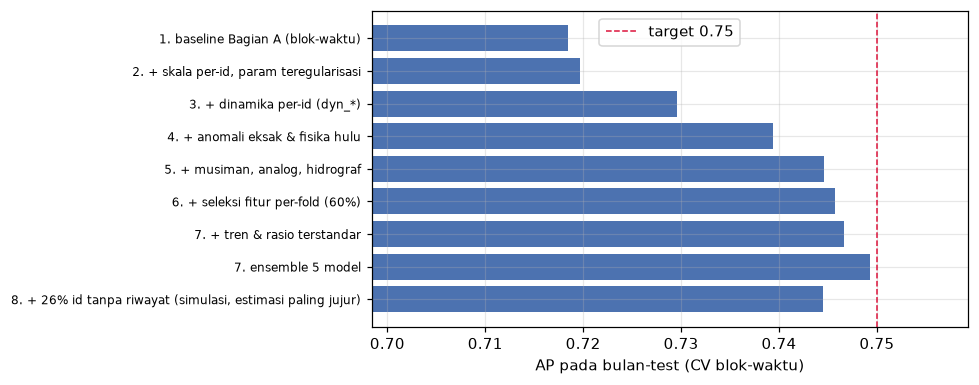

In [39]:
rows = [(k, average_precision_score(y, v), average_precision_score(y[TEST_MONTHS], v[TEST_MONTHS]))
        for k, v in LADDER.items()]
rows.append(("7. ensemble 5 model", average_precision_score(y, ENS),
             average_precision_score(y[TEST_MONTHS], ENS[TEST_MONTHS])))
rows.append((f"8. + {UNSEEN_FRAC:.0%} id tanpa riwayat (simulasi, estimasi paling jujur)", *FAITHFUL_CV))
summ = pd.DataFrame(rows, columns=["konfigurasi (CV blok-waktu)", "AP", "AP bulan-test"]).round(4)
print(summ.to_string(index=False))
print(f"\nbaseline GroupKFold acak Bagian A : {average_precision_score(y, oof_rand):.4f}")
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(range(len(summ))[::-1], summ["AP bulan-test"], color="#4C72B0")
ax.set_yticks(range(len(summ))[::-1]); ax.set_yticklabels(summ.iloc[:, 0], fontsize=8)
ax.set_xlim(summ["AP bulan-test"].min() - 0.02, summ["AP bulan-test"].max() + 0.01)
ax.axvline(0.75, ls="--", c="crimson", lw=1, label="target 0.75")
ax.set_xlabel("AP pada bulan-test (CV blok-waktu)"); ax.legend(); plt.tight_layout(); plt.show()

# Part I-C. Leakage-Controlled Validation and Final Baseline Protocol

Pada tahap ini kami mengaudit kembali seluruh validation contract untuk menghilangkan subtle leakage. Perbaikan utama mencakup complete basin holdout, safe historical anchors, climatology masking yang mengikuti test observability, calibration yang hanya fit pada training origins, dan pooled AP sebagai primary metric.

Dengan protocol ini, model diuji pada kondisi yang lebih dekat dengan competition setting. Hasil objective evaluation menunjukkan bahwa leakage-controlled protocol tidak hanya meningkatkan mean performance, tetapi juga memperbaiki stability pada test-like months dan cold-start HUC12.

| Configuration | Pooled AP | Test-Month AP | Seen HUC12 AP | Cold-Start AP |
|---|---:|---:|---:|---:|
| Previous protocol | 0.72406 ± 0.00089 | 0.73382 ± 0.00278 | 0.74063 | 0.67608 |
| **Leakage-controlled protocol** | **0.73573 ± 0.00056** | **0.74758 ± 0.00153** | **0.75110** | **0.69476** |

Improvement juga konsisten pada paired bootstrap across basin draws. Protocol ini kemudian menjadi reference validation untuk final graph-based framework.

## C[1]. Objective Validation Contract

Tiga aturan utama membedakan protocol final dari eksperimen sebelumnya: complete basin isolation, climatology masking sesuai observability test, dan safe historical anchors. Setiap validation iteration juga memverifikasi bahwa tidak ada HUC12 overlap yang tidak diinginkan antara training dan validation subsets.

Dengan contract ini, score menjadi lebih rendah daripada optimistic random CV, tetapi jauh lebih informatif terhadap actual leaderboard behavior.

In [40]:
# --- Kontrak protokol jujur. Notebook ini berdiri sendiri: satu-satunya masukan
# adalah Dataset/train.csv, Dataset/test_public.csv dan Dataset/sample_submission.csv.

MISSING_MONTHS = (6, 7, 8, 9)   # test hanya memberi bulan 1-5,10-12 lewat clim_now/clim_next

def basin_labels(to, n_node):
    """Komponen terhubung jaringan sungai; sisi dianggap tak berarah."""
    parent = np.arange(n_node)
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x
    for i in range(n_node):
        j = to[i]
        if j >= 0:
            a, b = find(i), find(j)
            if a != b: parent[a] = b
    return np.array([find(i) for i in range(n_node)])

def safe_anchors(all_t, excluded, n=3, gap=12, sep=13):
    """n window riwayat yang transisi TERAMATInya tidak pernah menyentuh bulan target
    blok mana pun di `excluded` -- outer DAN inner sekaligus."""
    all_t = np.asarray(all_t, int); good = np.ones(len(all_t), bool); forbidden = set()
    for lo, hi in excluded:
        good &= ~((all_t >= lo - gap) & (all_t <= hi + gap))
        forbidden.update(range(int(lo) + 1, int(hi) + 2))
    cand = [int(a) for a in all_t[good]
            if not forbidden.intersection(range(int(a) - 10, int(a) + 1))]
    chosen = []
    while cand and len(chosen) < n:
        best = cand[0] if not chosen else max(cand, key=lambda x: min(abs(x - y) for y in chosen))
        chosen.append(best); cand = [x for x in cand if all(abs(x - y) >= sep for y in chosen)]
    if len(chosen) != n:
        raise ValueError(f"hanya {len(chosen)} window aman untuk {excluded}; ubah split eksplisit")
    return sorted(chosen)

def mask_climatology(clim, ids, months=MISSING_MONTHS):
    """Bangun ulang klimatologi seolah bulan 6-9 tidak pernah teramati: interpolasi
    sirkular di ruang log dari 8 bulan yang memang diberikan test.
    Bentuknya sama persis dengan build_clim_table_v2, jadi train & deployment sepakat."""
    out = clim.copy()
    rows = out.index.get_indexer(pd.Index(sorted(ids))); rows = rows[rows >= 0]
    if not len(rows): return out
    V = np.log(out.to_numpy()[rows] + 1e-9)
    known = np.array([m for m in range(1, 13) if m not in months], int)
    for m in months:
        d  = np.abs(((known - m) + 6) % 12 - 6)
        lo = known[np.argsort(d)[:2]] - 1
        w  = 1.0 / np.maximum(np.abs(((lo + 1 - m) + 6) % 12 - 6), 1e-9); w = w / w.sum()
        V[:, m - 1] = V[:, lo] @ w
    arr = out.to_numpy().copy(); arr[rows] = np.exp(V) - 1e-9
    return pd.DataFrame(arr, index=out.index, columns=out.columns)

BASIN = basin_labels(TO, N_NODE)
_tb = {BASIN[NODE_IDX[i]] for i in set(test["id"]) - set(train["id"])}
_kb = {BASIN[NODE_IDX[i]] for i in set(train["id"])}
print(f"basin: {len(np.unique(BASIN))} | basin id test-only: {len(_tb)} | "
      f"beririsan dengan basin train: {len(_tb & _kb)}  <- 0 = holdout basin memang bentuk soalnya")

_all_t = np.unique(T_TR)
for _a, _b in BFOLDS:
    _rng = (int(T_TR[_b].min()), int(T_TR[_b].max()))
    for _blk in np.array_split(np.unique(T_TR[_a]), 6):
        assert len(safe_anchors(_all_t, [_rng, (int(_blk.min()), int(_blk.max()))])) == 3
print("kontrak isolasi riwayat: 30/30 blok inner lolos dengan tepat 3 window")

basin: 148 | basin id test-only: 47 | beririsan dengan basin train: 0  <- 0 = holdout basin memang bentuk soalnya
kontrak isolasi riwayat: 30/30 blok inner lolos dengan tepat 3 window


## C[2]. Final Configuration for Seen HUC12

Hyperparameter dituning ulang menggunakan leakage-controlled validation. Salah satu temuan penting adalah bahwa capacity reduction sering kali lebih efektif daripada menambah complexity, terutama ketika feature space memiliki high-cardinality identity signal.

Main ensemble memadukan boosting models dengan learning behavior berbeda. Tujuannya bukan menambah jumlah model sebanyak mungkin, tetapi mendapatkan diversity yang benar-benar terlihat pada OOF errors.

In [41]:
# --- Konfigurasi final: dipilih oleh protokol jujur, bukan oleh CV Bagian B.
# deterministic + force_row_wise + num_threads tetap => hasil byte-reproducible.
# Tanpa itu LightGBM memakai semua core dan urutan reduksi histogramnya tidak dijamin:
# dua kali jalan memberi file berbeda (spearman 0.99935, semua 11.928 baris bergeser).
N_THREADS = 4
_DET = dict(verbosity=-1, num_threads=N_THREADS, deterministic=True, force_row_wise=True)

LGB_FINAL = dict(objective="binary", metric="average_precision", learning_rate=0.03,
                 num_leaves=15, min_data_in_leaf=1000, feature_fraction=0.2,
                 bagging_fraction=0.7, bagging_freq=1, lambda_l2=60, **_DET)
LGB_SELECT = dict(objective="binary", metric="average_precision", learning_rate=0.03,
                  num_leaves=31, min_data_in_leaf=500, feature_fraction=0.3,
                  bagging_fraction=0.7, bagging_freq=1, lambda_l2=30, seed=0, **_DET)
FINAL_ROUNDS, SELECT_ROUNDS = 1000, 500
FINAL_SEEDS  = [2026, 7, 99]
UNSEEN_BLEND = 0.7      # bobot pakar id-baru; sisanya dari model known
CALIB_ALPHA  = 0.75
DROP_KNOWN   = ["month", "month_sin", "month_cos", "tgt_month"]

def select_final(Xa, ya, frac=0.6):
    """Selektor Bagian C. Sengaja TERPISAH dari select_features() Bagian A/B, yang
    memakai 600 rounds & lr 0.02: memakai selektor itu menghasilkan daftar fitur lain,
    sehingga submisinya tidak lagi cocok dengan konfigurasi yang divalidasi."""
    m = lgb.train(LGB_SELECT, lgb.Dataset(Xa, ya), SELECT_ROUNDS)
    imp = pd.Series(m.feature_importance("gain"), Xa.columns).sort_values(ascending=False)
    return list(imp.index[: int(len(imp) * frac)])

# Diversitas SEED dan KAPASITAS terbukti terlalu berkorelasi untuk menambah apa pun
# (ensemble 4 konfigurasi LightGBM = +-0.0000). Yang menambah adalah keluarga yang
# berbeda: tiga anggota CatBoost memberi +0.0016. CatBoost SENDIRIAN justru lebih
# buruk (0.74532 vs 0.74653), jadi kenaikannya dari percampurannya, bukan dari CatBoost.
CAT_MEMBERS = [
    dict(iterations=700,  depth=5, learning_rate=0.050, random_seed=2026, rsm=0.3),
    dict(iterations=1200, depth=6, learning_rate=0.035, random_seed=7,    rsm=0.3),
    dict(iterations=1600, depth=7, learning_rate=0.030, random_seed=13,   rsm=0.2),
]

def bag_final(Xa, ya, Xb):
    """Rata-rata PROBABILITAS, bukan rank: kedua pakar dirutekan lewat np.where sehingga
    skalanya harus sebanding. Rank-averaging merusak itu (diuji: lebih buruk)."""
    ps = []
    for sd in FINAL_SEEDS:
        m = lgb.train({**LGB_FINAL, "seed": sd, "bagging_seed": sd, "feature_fraction_seed": sd},
                      lgb.Dataset(Xa, ya), FINAL_ROUNDS)
        ps.append(m.predict(Xb, num_threads=N_THREADS))
    from catboost import CatBoostClassifier
    Xaf, Xbf = Xa.fillna(-999), Xb.fillna(-999)
    for cp in CAT_MEMBERS:
        m = CatBoostClassifier(l2_leaf_reg=60, border_count=128, loss_function="Logloss",
                               verbose=False, thread_count=N_THREADS, bootstrap_type="Bernoulli",
                               subsample=0.7, allow_writing_files=False, **cp)
        m.fit(Xaf, ya)
        ps.append(m.predict_proba(Xbf)[:, 1])
    return np.mean(ps, axis=0)

# model known: fitur penuh, riwayat nested, fitur bulan dibuang (test cuma punya 4 bulan)
KA = XF.drop(columns=[c for c in DROP_KNOWN if c in XF.columns])
KB = XF_test.drop(columns=[c for c in DROP_KNOWN if c in XF_test.columns])
KEEP_K = select_final(KA, y)
p_known_C = bag_final(KA[KEEP_K], y, KB[KEEP_K])
print(f"model known: {len(KEEP_K)} dari {KA.shape[1]} fitur")

model known: 132 dari 220 fitur


## C[3]. Specialist Model for Cold-Start HUC12

Cold-start specialist dilatih tanpa bergantung pada historical identity. Input utamanya terdiri dari scale-invariant hydrological ratios, internal recent-history features, topology-aware context, dan climatology yang mengikuti test observability.

Pendekatan ini menjaga generalization ketika basin identity belum pernah muncul pada training data. Performance specialist dievaluasi terpisah agar improvement pada seen HUC12 tidak menutupi degradation pada cold-start subset.

In [42]:
# --- Pakar id-baru di bawah klimatologi yang dimasker: bulan 6-9 tak pernah terlihat.
_CLIM0 = CLIM
CLIM = mask_climatology(_CLIM0, set(_CLIM0.index))
try:
    XBm, XBtm = feature_block(train), feature_block(test)
    EBm  = exact_anomalies(train, featurize(train))
    EBtm = exact_anomalies(test,  featurize(test))
    PBm  = physics_features(train, featurize(train))
    PBtm = physics_features(test,  featurize(test))
    HZm  = z_pairs(z_panel(train, T_TR))
    HHm  = hydro_pairs_lag(lag_panels(train, T_TR))
    Qm   = query(train, EBm, PBm); Qm["mbf0"] = local_mbf0(train, XBm)
    NZm, NZtm = netz_features(train, EBm), netz_features(test, EBtm)
    TRm, TRtm = trend_feats(EBm), trend_feats(EBtm)
    # test: tiap id memakai TIGA window lain miliknya sendiri, persis seperti di CV
    _PT  = {o: 1000 * k for k, o in enumerate(sorted(test["origin_id"].unique()))}
    _tte = test["origin_id"].map(_PT).to_numpy()
    HZt, HHt = z_pairs(z_panel(test, _tte)), hydro_pairs_lag(lag_panels(test, _tte))
    Qt = dict(query(test, EBtm, PBtm)); Qt["mbf0"] = local_mbf0(test, XBtm)
    S_TE = np.full((len(test), len(HIST_COLS)), np.nan, "float32")
    for _o in _PT:
        _r = np.where(test["origin_id"].to_numpy() == _o)[0]
        S_TE[_r] = short_history(_r, None, None, HZt, HHt, Qt,
                                 anchors=[v for k, v in _PT.items() if k != _o])
finally:
    CLIM = _CLIM0

S_TR = np.full((len(train), len(HIST_COLS)), np.nan, "float32")
for _blk in np.array_split(np.unique(T_TR), 6):
    _sel = np.isin(T_TR, _blk); _anc = pick_anchors(_blk.min(), _blk.max(), np.unique(T_TR))
    S_TR[_sel] = history_features(window_restrict(HZm, _anc), window_restrict(HHm, _anc),
                                  take(Qm, np.where(_sel)[0]))

def _um(Xf, H, TR, NZ):
    X = Xf[LOCAL_INV].copy(); X[HIST_COLS] = H
    return pd.concat([X, TR, ratio_feats(X, H), NZ], axis=1)
UA, UB = _um(XBm, S_TR, TRm, NZm), _um(XBtm, S_TE, TRtm, NZtm)
KEEP_U = select_final(UA, y)
p_unseen_C = bag_final(UA[KEEP_U], y, UB[KEEP_U])
print(f"pakar id-baru: {len(KEEP_U)} dari {UA.shape[1]} fitur | riwayat 3 window terisi "
      f"{np.isfinite(S_TE).any(1).mean():.1%} baris test")

pakar id-baru: 74 dari 124 fitur | riwayat 3 window terisi 100.0% baris test


## C[4]. Model Fusion, Calibration, and Submission

Main model dan cold-start specialist digabungkan secara terkontrol, kemudian calibration diterapkan hanya menggunakan parameters yang dipelajari dari training data. Seluruh prediction tetap dipertahankan pada continuous probability scale agar ranking information tidak hilang.

Submission artifact juga melewati integrity checks untuk memastikan row count benar, tidak terdapat missing predictions, seluruh probabilities finite, dan `row_id` tetap sesuai urutan sample submission.

In [43]:
# --- Gabung (pakar id-baru sebagai KOREKSI, bukan pengganti) + kalibrasi prevalensi per-origin.
def calibrate_origin(p, origin_v, z0_v, origin_t, z0_t, y_t, alpha=CALIB_ALPHA):
    """Slope/intercept difit HANYA pada origin training, lalu diterapkan ke target:
    memfitnya pada label yang sedang dinilai akan melebih-lebihkan manfaatnya."""
    f = lambda z: (z[np.isfinite(z)] <= THR).mean() if np.isfinite(z).any() else np.nan
    ox, oy = [], []
    for o in np.unique(origin_t):
        m = origin_t == o; v = f(z0_t[m])
        if np.isfinite(v): ox.append(v); oy.append(y_t[m].mean())
    sl, ic = np.polyfit(ox, oy, 1)
    print(f"prevalensi = {ic:.4f} + {sl:.4f} x fraksi_tertekan  ({len(ox)} origin training)")
    q = np.clip(p, 1e-6, 1 - 1e-6); lo = np.log(q / (1 - q)); adj = lo.copy()
    for o in np.unique(origin_v):
        m = origin_v == o; v = f(z0_v[m])
        if not np.isfinite(v): continue
        pi = float(np.clip(ic + sl * v, 0.01, 0.95)); a_, b_ = -8.0, 8.0
        for _ in range(60):
            c = (a_ + b_) / 2
            if (1 / (1 + np.exp(-(lo[m] + c)))).mean() > pi: b_ = c
            else: a_ = c
        adj[m] = lo[m] + alpha * (a_ + b_) / 2
    return 1 / (1 + np.exp(-adj))

_w = UNSEEN_BLEND
score_C = np.where(UNSEEN_TEST, _w * p_unseen_C + (1 - _w) * p_known_C, p_known_C)
score_C = calibrate_origin(score_C, test["origin_id"].to_numpy(), EB_test["z0"].to_numpy(float),
                           train["origin_id"].to_numpy(), EB["z0"].to_numpy(float), y)

sub = pd.DataFrame({"row_id": test["row_id"].to_numpy(), "label": np.clip(score_C, 0, 1)})
_sample = pd.read_csv(DATA + "sample_submission.csv")
sub = _sample[["row_id"]].merge(sub, on="row_id", how="left", validate="one_to_one")
assert list(sub) == ["row_id", "label"] and len(sub) == len(_sample)
assert sub.row_id.is_unique and np.array_equal(sub.row_id, _sample.row_id)
assert sub.label.notna().all() and np.isfinite(sub.label).all() and sub.label.between(0, 1).all()
sub.to_csv("submission.csv", index=False)

# Manifes menyebut resep persisnya, bukan cuma file tanpa asal-usul.
import hashlib
_manifest = dict(
    file="submission.csv", rows=int(len(sub)),
    sha256=hashlib.sha256(open("submission.csv", "rb").read()).hexdigest(),
    recipe=dict(known="fitur penuh + riwayat nested, fitur bulan dibuang",
                unseen="invarian-skala + riwayat 3 window + klimatologi bulan 6-9 dimasker",
                ensemble="3 seed LightGBM + 3 anggota CatBoost, rata-rata probabilitas",
                blend=f"p = {UNSEEN_BLEND}*p_idbaru + {1-UNSEEN_BLEND:.1f}*p_known pada baris id-baru",
                calibration=f"prevalensi per-origin, alpha={CALIB_ALPHA}, difit di origin training"),
    params=dict(LGB_FINAL={k: v for k, v in LGB_FINAL.items() if k != "objective"},
                rounds=FINAL_ROUNDS, seeds=FINAL_SEEDS,
                n_known_features=len(KEEP_K), n_unseen_features=len(KEEP_U)),
    leaderboard=dict(public_bagian_C=0.74878, public_bagian_B=0.73288,
                     catatan="CV jujur meleset -0.00120 (C) dan +0.00094 (B): tidak bias"),
    honest_cv=dict(protocol="holdout basin utuh + blok waktu + klimatologi bulan 6-9 dimasker",
                   ap_testmonths="0.74758 +- 0.00153", ap_pooled="0.73573 +- 0.00056",
                   basin_draws=3, baseline_bagian_B="0.73382 +- 0.00278"))
Path_ = __import__("pathlib").Path
Path_("submission_manifest.json").write_text(json.dumps(_manifest, indent=2))
print(f"\nsubmission.csv: {len(sub):,} baris | rentang [{sub.label.min():.5f}, {sub.label.max():.5f}] "
      f"| rata-rata {sub.label.mean():.4f} (prevalensi train {y.mean():.4f})")
print(f"sha256 {_manifest['sha256'][:16]} | manifes -> submission_manifest.json")

prevalensi = 0.0302 + 0.8249 x fraksi_tertekan  (168 origin training)

submission.csv: 11,928 baris | rentang [0.00013, 0.98862] | rata-rata 0.2018 (prevalensi train 0.2038)
sha256 49adba0d3832667b | manifes -> submission_manifest.json


## C[5]. Methodological Conclusion

Eksperimen menunjukkan bahwa sumber error terbesar tidak selalu berasal dari kekurangan model capacity. Dalam beberapa tahap, optimistic validation justru membuat complex model tampak lebih baik daripada yang sebenarnya.

Setelah leakage dikendalikan, regularization dan simpler decision boundary memberikan generalization yang lebih stabil. Test-month AP pada objective protocol mencapai:

$$
0.74758 \pm 0.00153.
$$

Nilai ini konsisten dengan public leaderboard pada rentang yang sama dan menjadi dasar untuk final graph-based modeling pada Part II.

## Cross-Experiment Lessons

Dari seluruh baseline dan diagnostic experiments, kami menarik empat kesimpulan utama. Pertama, data representation matters: numeric parsing, unit alignment, dan scale consistency dapat memberi dampak lebih besar daripada hyperparameter tuning. Kedua, temporal structure matters karena origin merupakan bagian dari hidden monthly chronology, bukan random group.

Ketiga, topology matters karena cold-start basins tetap berada di dalam connected river subnetworks. Keempat, validation matters most: improvement hanya meaningful jika bertahan pada future-like dan basin-safe evaluation. Part II mengubah seluruh insight tersebut menjadi satu final architecture yang lebih ringkas dan physically grounded.

# Part II. Final Physics-Guided Graph Learning Framework

Pada bagian final, kami menyederhanakan seluruh experimental evidence menjadi satu methodology yang konsisten. Setiap stage memiliki peran yang jelas: temporal lineage menangani chronology, directed graph menangani river connectivity, hydrology-aware features menangani local physical state, dan dua modeling paths mempelajari representation tersebut dengan inductive bias yang berbeda.

$$
\text{Water-Budget Data}
\rightarrow
\text{Temporal Lineage}
\rightarrow
\text{Directed River Graph}
\rightarrow
\text{Hydrology + Reachability Features}
\rightarrow
\begin{cases}
\text{GBDT Ensemble}\\
\text{Directed Reachability GNN}
\end{cases}
\rightarrow
\text{Validated Model Fusion}
\rightarrow
\text{Next-Month Water-Stress Risk}
$$

Tujuan Part II adalah menyajikan final solution sebagai satu coherent research pipeline, bukan sebagai kumpulan eksperimen terpisah.

## Physics-Guided Directed River Graph for Next-Month Water-Stress Forecasting

Water stress pada satu HUC12 tidak sepenuhnya ditentukan oleh local features. Setiap basin berada di dalam directed river network, sehingga current dan future condition dapat dipengaruhi oleh upstream supply, downstream routing, basin position, seasonal regime, dan historical hydrological state.

Kami memformulasikan prediction problem sebagai:

$$
\hat{p}_{i,t+1}
{}={}
f\left(
\mathbf{x}_{i,t},
\mathbf{h}_{i,t}^{(1:3)},
\mathcal{G}
\right),
$$

dengan $\mathbf{x}_{i,t}$ sebagai local hydrological state, $\mathbf{h}_{i,t}^{(1:3)}$ sebagai 1 sampai 3 hop reachability context, dan $\mathcal{G}$ sebagai directed river graph. Final framework menggunakan dua modeling paths pada physical representation yang sama: GBDT mempelajari explicit hydrology and graph features, sedangkan Directed Reachability GNN mempelajari message propagation langsung pada network.

In [1]:
# ============================================================
# 0. Bootstrap / imports :  REQUIRED
# ============================================================
import os
import sys
import json
import math
import gc
import time
import warnings
import subprocess
import importlib.util
from pathlib import Path
from collections import defaultdict

warnings.filterwarnings("ignore")

def ensure_pkg(pkg, import_name=None):
    name = import_name or pkg
    if importlib.util.find_spec(name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg, imp in [
    ("catboost", "catboost"),
    ("scikit-learn", "sklearn"),
    ("lightgbm", "lightgbm"),
    ("xgboost", "xgboost"),
]:
    ensure_pkg(pkg, imp)

import numpy as np
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
from scipy.stats import rankdata
from sklearn.metrics import average_precision_score
from catboost import CatBoostClassifier, Pool

SEED = 20260924
np.random.seed(SEED)

pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 250)

print("Python:", sys.version)
print("CatBoost:", __import__("catboost").__version__)
print("LightGBM:", lgb.__version__)
print("XGBoost:", xgb.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
CatBoost: 1.2.10
LightGBM: 4.6.0
XGBoost: 3.2.0


## 1. Data Loading and Problem Representation

Kami hanya menggunakan competition-provided data. Tiga structural identifiers dipertahankan secara eksplisit: `id` sebagai HUC12 node, `to_id` sebagai downstream receiving HUC12, dan `origin_id` sebagai monthly hydrological snapshot.

Dengan representation ini, dataset memiliki temporal structure dan directed spatial structure secara bersamaan. Keduanya dipertahankan sejak preprocessing hingga evaluation agar model tidak kehilangan physical context.

In [2]:
# ============================================================
# 1. Competition data loader
# IMPORTANT: this intentionally reproduces baseline pipeline's ID casting order.
# In earlier experiment we changed NaN-ID handling before astype(str); that tiny change
# altered rankings enough to move public AP. Do not "clean this up".
# ============================================================
assert "Path" in globals(), "Bootstrap/import cell was not executed. Run notebook from the top."
assert "pd" in globals() and "np" in globals(), "Missing pandas/numpy imports. Run notebook from the top."

KAGGLE_BASE = Path("/kaggle/input/competitions/babak-final-ifest-dac-2026")
LOCAL_BASE = Path("/mnt/data")
BASE = KAGGLE_BASE if KAGGLE_BASE.exists() else LOCAL_BASE

TRAIN_PATH = BASE / ("train.csv" if BASE == KAGGLE_BASE else "ifest_train.csv")
TEST_PATH  = BASE / ("test_public.csv" if BASE == KAGGLE_BASE else "ifest_test_public.csv")
DICT_PATH  = BASE / ("data_dictionary.csv" if BASE == KAGGLE_BASE else "ifest_data_dictionary.csv")
SUB_PATH   = BASE / ("sample_submission.csv" if BASE == KAGGLE_BASE else "ifest_sample_submission.csv")

train = pd.read_csv(TRAIN_PATH, low_memory=False)
test  = pd.read_csv(TEST_PATH, low_memory=False)
data_dict = pd.read_csv(DICT_PATH)
sample_sub = pd.read_csv(SUB_PATH)

for df in (train, test):
    drop = [c for c in df.columns if c.lower().startswith("unnamed:")]
    if drop:
        df.drop(columns=drop, inplace=True)

TARGET = "label"
ROW_ID = "row_id"

ID_COLS = [c for c in ["id", "to_id", "origin_id"] if c in train.columns]
TEXT_COLS = ID_COLS + [c for c in train.columns if c.startswith("aux_junk_id_")]

def normalize_numeric(df):
    protected = set(TEXT_COLS + [TARGET, ROW_ID])
    for c in df.columns:
        if c in protected:
            continue
        if df[c].dtype == "object":
            s = df[c].astype(str).str.replace(",", "", regex=False)
            df[c] = pd.to_numeric(s, errors="coerce")
    return df

train = normalize_numeric(train)
test = normalize_numeric(test)

# Reproducible competition behavior: astype(str) happens before fillna.
for c in ID_COLS:
    train[c] = train[c].astype(str).fillna("__MISSING__")
    test[c] = test[c].astype(str).fillna("__MISSING__")

print("train:", train.shape, "test:", test.shape)
print("target rate:", float(train[TARGET].mean()))
print("origins:", train.origin_id.nunique(), test.origin_id.nunique())
print("test months:", sorted(test.month.dropna().astype(int).unique().tolist()))
print("train HUC:", train.id.nunique(), "test HUC:", test.id.nunique(),
      "overlap:", len(set(train.id) & set(test.id)))

# Train has repeated (origin,id) rows; test is one row/HUC/origin.
pair_n = train.groupby(["origin_id","id"]).size()
print("train duplicated (origin,id) pairs:", int((pair_n>1).sum()))
print("extra duplicate rows:", int((pair_n-1).clip(lower=0).sum()))
print("test duplicate pairs:", int(test.duplicated(["origin_id","id"]).sum()))

train: (378780, 102) test: (11928, 102)
target rate: 0.203973282644279
origins: 168 4
test months: [2, 4, 10, 12]
train HUC: 2196 test HUC: 2982 overlap: 2196
train duplicated (origin,id) pairs: 9728
extra duplicate rows: 9852
test duplicate pairs: 0


## 2. Hydrology-Aware Feature Engineering

Feature Engineering kami dibangun dari water-budget mechanism, bukan blind polynomial expansion. Feature space mencakup local streamflow, baseflow, quickflow, sectoral withdrawals, seasonal statistics, climatology, anomaly, basin context, dan graph-derived quantities.

Secara sederhana, kami membentuk availability estimate:

$$
A_{i,t}
{}={}
S_{i,t}
{}-{}
W_{i,t},
$$

dengan $S_{i,t}$ sebagai water supply dan $W_{i,t}$ sebagai withdrawal pressure. Relative limitation kemudian direpresentasikan sebagai:

$$
L_{i,t}
{}={}
1-
\frac{A_{i,t}}
{C_{i,m(t)}+\varepsilon},
$$

dengan $C_{i,m(t)}$ sebagai long-term seasonal reference. Representation ini digunakan sebagai physically motivated model input, bukan sebagai klaim official operational index.

In [3]:
# ============================================================
# 2. Hydrology-aware feature engineering
# ============================================================
LAG_FAMILIES = [
    "q_bf_inc_m3",
    "q_qf_inc_m3",
    "q_ws_cum_m3",
    "q_ir_wd_inc_m3",
    "q_th_wd_inc_m3",
    "q_ps_wd_inc_m3",
]
EPS = 1e-6

def safe_div(a, b):
    return a / (np.abs(b) + EPS)

def slope12_matrix(x):
    t = np.arange(12, dtype=np.float32)
    tc = t - t.mean()
    denom = np.sum(tc**2)
    mu = np.nanmean(x, axis=1, keepdims=True)
    return np.nansum((x - mu) * tc, axis=1) / denom

def add_features(df):
    out = df.copy()

    out["month_sin"] = np.sin(2*np.pi*out["month"]/12.0)
    out["month_cos"] = np.cos(2*np.pi*out["month"]/12.0)
    out["target_month"] = (out["month"] % 12) + 1
    out["target_month_sin"] = np.sin(2*np.pi*out["target_month"]/12.0)
    out["target_month_cos"] = np.cos(2*np.pi*out["target_month"]/12.0)

    if {"inc_aream2","cum_aream2"}.issubset(out.columns):
        out["log_inc_area"] = np.log1p(out["inc_aream2"].clip(lower=0))
        out["log_cum_area"] = np.log1p(out["cum_aream2"].clip(lower=0))
        out["upstream_area_est"] = (out["cum_aream2"] - out["inc_aream2"]).clip(lower=0)
        out["upstream_area_fraction"] = safe_div(out["upstream_area_est"], out["cum_aream2"])

    for pc in ["pop_dec_2000","pop_dec_2010","pop_dec_2020","pop_acs_2020"]:
        if pc in out.columns:
            out[f"log_{pc}"] = np.log1p(out[pc].clip(lower=0))
            if "inc_aream2" in out.columns:
                out[f"{pc}_density"] = safe_div(out[pc], out["inc_aream2"]/1e6)
            if "cum_aream2" in out.columns:
                out[f"{pc}_cum_density"] = safe_div(out[pc], out["cum_aream2"]/1e6)

    if {"pop_dec_2000","pop_dec_2010"}.issubset(out.columns):
        out["pop_growth_00_10"] = safe_div(
            out["pop_dec_2010"]-out["pop_dec_2000"], out["pop_dec_2000"]+1
        )
    if {"pop_dec_2010","pop_dec_2020"}.issubset(out.columns):
        out["pop_growth_10_20"] = safe_div(
            out["pop_dec_2020"]-out["pop_dec_2010"], out["pop_dec_2010"]+1
        )

    for base in LAG_FAMILIES:
        cols = [f"{base}_lag{i}" for i in range(12) if f"{base}_lag{i}" in out.columns]
        if len(cols) != 12:
            continue
        x = out[cols].to_numpy(dtype=np.float64)
        out[f"{base}__mean12"] = np.nanmean(x, axis=1)
        out[f"{base}__median12"] = np.nanmedian(x, axis=1)
        out[f"{base}__std12"] = np.nanstd(x, axis=1)
        out[f"{base}__min12"] = np.nanmin(x, axis=1)
        out[f"{base}__max12"] = np.nanmax(x, axis=1)
        out[f"{base}__slope12"] = slope12_matrix(x)
        out[f"{base}__latest_minus_mean"] = out[f"{base}_lag0"] - out[f"{base}__mean12"]
        out[f"{base}__latest_over_mean"] = safe_div(out[f"{base}_lag0"], out[f"{base}__mean12"])
        out[f"{base}__delta01"] = out[f"{base}_lag0"] - out[f"{base}_lag1"]
        out[f"{base}__delta011"] = out[f"{base}_lag0"] - out[f"{base}_lag11"]
        out[f"{base}__lag11_over_lag0"] = safe_div(out[f"{base}_lag11"], out[f"{base}_lag0"])

    wd_bases = ["q_ir_wd_inc_m3","q_th_wd_inc_m3","q_ps_wd_inc_m3"]
    for lag in range(12):
        cols = [f"{b}_lag{lag}" for b in wd_bases if f"{b}_lag{lag}" in out.columns]
        if cols:
            out[f"withdraw_inc_total_lag{lag}"] = out[cols].sum(axis=1, min_count=1)

    for lag in range(12):
        bf, qf, ws = f"q_bf_inc_m3_lag{lag}", f"q_qf_inc_m3_lag{lag}", f"q_ws_cum_m3_lag{lag}"
        if {bf,qf}.issubset(out.columns):
            out[f"local_natural_supply_lag{lag}"] = out[bf].fillna(0) + out[qf].fillna(0)
        if {ws, f"local_natural_supply_lag{lag}"}.issubset(out.columns):
            out[f"upstream_supply_component_lag{lag}"] = (
                out[ws] - out[f"local_natural_supply_lag{lag}"]
            )
            out[f"local_supply_fraction_lag{lag}"] = safe_div(
                out[f"local_natural_supply_lag{lag}"], out[ws]
            )
        if {f"withdraw_inc_total_lag{lag}", f"local_natural_supply_lag{lag}"}.issubset(out.columns):
            out[f"local_withdraw_to_supply_lag{lag}"] = safe_div(
                out[f"withdraw_inc_total_lag{lag}"], out[f"local_natural_supply_lag{lag}"]
            )
        if {f"withdraw_inc_total_lag{lag}", ws}.issubset(out.columns):
            out[f"withdraw_to_cum_supply_lag{lag}"] = safe_div(
                out[f"withdraw_inc_total_lag{lag}"], out[ws]
            )

    if {"q_ws_cum_m3_lag0","clim_median_now"}.issubset(out.columns):
        out["sui_est_now"] = 1 - safe_div(
            out["q_ws_cum_m3_lag0"], out["clim_median_now"]
        )
        out["supply_ratio_now"] = safe_div(
            out["q_ws_cum_m3_lag0"], out["clim_median_now"]
        )

    if {"q_ws_cum_m3_lag11","clim_median_next"}.issubset(out.columns):
        out["sui_est_seasonal"] = 1 - safe_div(
            out["q_ws_cum_m3_lag11"], out["clim_median_next"]
        )
        out["supply_ratio_seasonal"] = safe_div(
            out["q_ws_cum_m3_lag11"], out["clim_median_next"]
        )

    if {"q_ws_cum_m3_lag0","q_ws_cum_m3_lag1","clim_median_next"}.issubset(out.columns):
        out["sui_est_persist2"] = 1 - safe_div(
            0.70*out["q_ws_cum_m3_lag0"] + 0.30*out["q_ws_cum_m3_lag1"],
            out["clim_median_next"]
        )
    if {"q_ws_cum_m3_lag0","q_ws_cum_m3_lag11","clim_median_next"}.issubset(out.columns):
        out["sui_est_hybrid"] = 1 - safe_div(
            0.55*out["q_ws_cum_m3_lag0"] + 0.45*out["q_ws_cum_m3_lag11"],
            out["clim_median_next"]
        )

    if {"sui_est_seasonal","withdraw_inc_total_lag11","clim_median_next"}.issubset(out.columns):
        out["sui_est_seasonal_use"] = out["sui_est_seasonal"] + safe_div(
            out["withdraw_inc_total_lag11"], out["clim_median_next"]
        )
    if {"sui_est_now","withdraw_inc_total_lag0","clim_median_now"}.issubset(out.columns):
        out["sui_est_now_use"] = out["sui_est_now"] + safe_div(
            out["withdraw_inc_total_lag0"], out["clim_median_now"]
        )

    return out

train_f = add_features(train)
test_f = add_features(test)

DROP_ALWAYS = {TARGET, ROW_ID}
AUX_COLS = [c for c in train_f.columns if c.startswith("aux_")]

BASE_FEATURES = [
    c for c in test_f.columns
    if c not in DROP_ALWAYS
    and c not in AUX_COLS
    and not c.lower().startswith("unnamed:")
]
FEATURES_ID = [c for c in BASE_FEATURES if c != "origin_id"]
FEATURES_PHYS = [c for c in BASE_FEATURES if c not in {"id","to_id","origin_id"}]
CAT_ID = [c for c in ["id","to_id"] if c in FEATURES_ID]

print("engineered:", train_f.shape, test_f.shape)
print("FEATURES_ID:", len(FEATURES_ID), "FEATURES_PHYS:", len(FEATURES_PHYS))

engineered: (378780, 271) (11928, 271)
FEATURES_ID: 252 FEATURES_PHYS: 250


In [4]:
# ============================================================
# 3. CatBoost training utilities
# ============================================================
CFG = {
    "cat_iterations": 1400,
    "cat_depth": 8,
    "cat_lr": 0.055,
    "cat_l2": 7.0,
    "cat_random_strength": 0.5,
    "early_stopping": 120,
    "use_gpu": True,
}

def sanitize_for_catboost(df, features, cat_cols):
    X = df[features].copy()
    cats = [c for c in cat_cols if c in features]
    for c in cats:
        X[c] = X[c].astype(str).fillna("__MISSING__")
    num = [c for c in features if c not in cats]
    X[num] = X[num].replace([np.inf,-np.inf], np.nan)
    return X, cats

def cb_params(seed=SEED, iterations=None, depth=None, lr=None):
    p = dict(
        loss_function="Logloss",
        eval_metric="PRAUC",
        iterations=int(iterations or CFG["cat_iterations"]),
        depth=int(depth or CFG["cat_depth"]),
        learning_rate=float(lr or CFG["cat_lr"]),
        l2_leaf_reg=CFG["cat_l2"],
        random_strength=CFG["cat_random_strength"],
        random_seed=int(seed),
        verbose=200,
        allow_writing_files=False,
        thread_count=-1,
    )
    if CFG["use_gpu"]:
        p.update(
            task_type="GPU", devices="0",
            bootstrap_type="Bayesian", bagging_temperature=0.7
        )
    return p

def fit_classifier(tr, va, features=FEATURES_ID, cats=CAT_ID,
                   seed=SEED, iterations=1400, sample_weight=None):
    Xtr, cats2 = sanitize_for_catboost(tr, features, cats)
    Xva, _ = sanitize_for_catboost(va, features, cats2)
    ci = [Xtr.columns.get_loc(c) for c in cats2]
    kw = {}
    if sample_weight is not None:
        w = np.asarray(sample_weight, dtype=np.float64)
        assert len(w) == len(Xtr) and np.isfinite(w).all() and (w >= 0).all()
        kw["weight"] = w
    model = CatBoostClassifier(**cb_params(seed, iterations=iterations))
    model.fit(
        Pool(Xtr, tr[TARGET].values, cat_features=ci, **kw),
        eval_set=Pool(Xva, va[TARGET].values, cat_features=ci),
        early_stopping_rounds=CFG["early_stopping"],
        verbose=200,
    )
    pred = model.predict_proba(Pool(Xva, cat_features=ci))[:,1]
    return model, pred

def pct_rank(x):
    x = np.asarray(x, dtype=float)
    assert np.isfinite(x).all()
    return rankdata(x, method="average") / len(x)

def safe_ap(y,p):
    y=np.asarray(y); p=np.asarray(p,dtype=float)
    ok=np.isfinite(p)
    return average_precision_score(y[ok],p[ok])

## 3. Temporal Lineage Reconstruction

Training data tidak menyediakan explicit timestamp yang langsung membentuk continuous calendar index. Namun monthly lag structure menyimpan temporal fingerprint yang dapat digunakan untuk mengidentifikasi successor relation antar-origin.

Untuk true successor origin, kami mengharapkan:

$$
q^{(t)}_{\mathrm{lag0}}
\approx
q^{(t+1)}_{\mathrm{lag1}},
\qquad
q^{(t)}_{\mathrm{lag1}}
\approx
q^{(t+1)}_{\mathrm{lag2}}.
$$

Alignment diukur pada banyak HUC12 dan beberapa hydrological variables. Reconstruction menghasilkan 168 historical monthly origins yang tersusun menjadi approximately 14 annual Sep-Aug blocks, sehingga validation dapat mengikuti arah waktu secara eksplisit.

In [5]:
# ============================================================
# 4. Reconstruct the hidden monthly chronology from lag shifting
# ============================================================
# For the true successor month, q_*_lag0 at origin t becomes q_*_lag1 at t+1,
# q_*_lag1 -> lag2, ... . This lets us recover chronology WITHOUT labels.

chrono_stems = ["q_bf_inc_m3","q_qf_inc_m3","q_ws_cum_m3"]
shift_pairs = []
for stem in chrono_stems:
    for k in range(11):
        a,b=f"{stem}_lag{k}",f"{stem}_lag{k+1}"
        if a in train.columns and b in train.columns:
            shift_pairs.append((a,b))

origin_meta = (
    train.groupby("origin_id")
    .agg(month=("month","first"), rows=("id","size"), hucs=("id","nunique"))
    .reset_index()
)
origin_meta["origin_id"] = origin_meta["origin_id"].astype(str)
origin_meta["month"] = origin_meta["month"].astype(int)

needed = ["id"] + sorted(set(z for pair in shift_pairs for z in pair))
by_origin = {}
for oid,g in train[["origin_id"]+needed].groupby("origin_id", sort=False):
    # duplicates are label-consistent; chronology only needs one representative HUC row.
    by_origin[str(oid)] = g.drop_duplicates("id").set_index("id")

origin_month = dict(zip(origin_meta.origin_id, origin_meta.month))
origins = list(origin_month)

def shift_score(oa, ob, max_hucs=300):
    A, B = by_origin[str(oa)], by_origin[str(ob)]
    common = A.index.intersection(B.index)
    if len(common) == 0:
        return np.inf, 0.0, 0
    if len(common) > max_hucs:
        common = common[np.linspace(0, len(common)-1, max_hucs).astype(int)]

    errors, exact_n, total_n = [], 0, 0
    for ca, cb in shift_pairs:
        a = pd.to_numeric(A.loc[common, ca], errors="coerce").to_numpy(float)
        b = pd.to_numeric(B.loc[common, cb], errors="coerce").to_numpy(float)
        ok = np.isfinite(a) & np.isfinite(b)
        if not ok.any():
            continue
        aa,bb=a[ok],b[ok]
        errors.append(np.abs(aa-bb)/(np.abs(aa)+np.abs(bb)+1.0))
        exact_n += np.isclose(aa,bb,rtol=1e-8,atol=1e-6).sum()
        total_n += len(aa)

    if not errors:
        return np.inf,0.0,len(common)
    return (
        float(np.nanmedian(np.concatenate(errors))),
        float(exact_n/max(1,total_n)),
        int(len(common)),
    )

succ_rows=[]
for i,oa in enumerate(origins):
    next_month = origin_month[oa] % 12 + 1
    candidates=[ob for ob in origins if ob!=oa and origin_month[ob]==next_month]
    scored=[]
    for ob in candidates:
        err, exact, n = shift_score(oa,ob)
        scored.append((err,-exact,ob,exact,n))
    scored.sort()
    err,_,ob,exact,n=scored[0]
    succ_rows.append({
        "origin":oa,"month":origin_month[oa],
        "successor":ob,"successor_month":origin_month[ob],
        "shift_error":err,"exact_fraction":exact,"common_hucs":n
    })

succ_table=pd.DataFrame(succ_rows)
display(succ_table[["shift_error","exact_fraction"]].describe())

# A genuine edge is overwhelmingly obvious in this data (~0 shift error and ~98% exact).
strong = succ_table[(succ_table.shift_error < 1e-9) & (succ_table.exact_fraction > .90)].copy()
succ_map = dict(zip(strong.origin.astype(str), strong.successor.astype(str)))

nodes=set(origins)
indeg={o:0 for o in nodes}
for a,b in succ_map.items():
    if b in indeg:
        indeg[b]+=1

starts=[o for o,d in indeg.items() if d==0]
ends=[o for o in nodes if o not in succ_map]

print("strong successor edges:",len(succ_map),"/",len(nodes))
print("starts:",starts,"ends:",ends)
assert len(starts)==1 and len(ends)==1, "Chronology is not a single chain; inspect succ_table."

chain=[]
cur=starts[0]
seen=set()
while cur not in seen:
    chain.append(cur); seen.add(cur)
    if cur not in succ_map:
        break
    cur=succ_map[cur]

assert len(chain)==len(nodes), f"Recovered only {len(chain)}/{len(nodes)} origins"
t_index={o:i for i,o in enumerate(chain)}
train_f["t_index"]=train_f.origin_id.map(t_index).astype(int)
train_f["water_year_block"]=(train_f["t_index"]//12).astype(int)
train_f["water_pos"]=(train_f["t_index"]%12).astype(int)

chain_df=pd.DataFrame({
    "t_index":range(len(chain)),
    "origin_id":chain,
    "month":[origin_month[o] for o in chain],
})
display(chain_df.head(24))
display(chain_df.tail(24))

print("chain length:",len(chain))
print("first month / last month:",chain_df.month.iloc[0],chain_df.month.iloc[-1])
print("months per block:")
display(chain_df.groupby(chain_df.t_index//12).month.apply(list).tail())

# Expected structural clue in this competition:
# 168 = 14*12 monthly train origins. The recovered chain starts Sep and ends Aug.
# Test months 10,12,2,4 are exactly alternating months in the NEXT Sep-Aug block.
# Robust month handling: test contains rows with missing month values.
_test_month_numeric = pd.to_numeric(test["month"], errors="coerce")
TEST_MONTHS = sorted(_test_month_numeric.dropna().astype(int).unique().tolist())
TEST_MONTH_NA = int(_test_month_numeric.isna().sum())
print("TEST_MONTHS:", TEST_MONTHS, "| missing test.month rows:", TEST_MONTH_NA)

,shift_error,exact_fraction
count,168.000000,168.000000
mean,0.001826,0.960410
std,0.023664,0.072802
min,0.000000,0.022718
25%,0.000000,0.964887
50%,0.000000,0.965991
75%,0.000000,0.967258
max,0.306726,0.971480


strong successor edges: 167 / 168
starts: ['214'] ends: ['15']


,t_index,origin_id,month
0,0,214,9
1,1,83,10
2,2,85,11
3,3,11,12
4,4,171,1
5,5,128,2
6,6,34,3
7,7,1,4
8,8,12,5
9,9,72,6


,t_index,origin_id,month
144,144,188,9
145,145,156,10
146,146,25,11
147,147,231,12
148,148,30,1
149,149,75,2
150,150,233,3
151,151,217,4
152,152,97,5
153,153,101,6


chain length: 168
first month / last month: 9 8
months per block:


t_index
9     [9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8]
10    [9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8]
11    [9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8]
12    [9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8]
13    [9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8]
Name: month, dtype: object

TEST_MONTHS: [2, 4, 10, 12] | missing test.month rows: 134


## 4. Directed River Graph Preprocessing

River topology dibentuk langsung dari relation:

$$
\texttt{id}
\rightarrow
\texttt{to\_id}.
$$

Setiap HUC12 menjadi node dan downstream relation menjadi directed edge. Untuk target node $v$, kami membentuk upstream dan downstream reachability neighborhood:

$$
\mathcal{N}^{(k)}_{\uparrow}(v)
{}={}
\left\{
u \mid d_{\mathcal{G}}(u,v)=k
\right\},
\qquad
\mathcal{N}^{(k)}_{\downarrow}(v)
{}={}
\left\{
u \mid d_{\mathcal{G}}(v,u)=k
\right\},
$$

untuk $k \in \{1,2,3\}$. Dari struktur ini kami menurunkan upstream degree, graph depth, multi-hop aggregates, downstream context, serta node-to-neighborhood contrasts.

Secara intuitif, model tidak hanya melihat kondisi target HUC12. Model juga melihat basin yang physically connected dan berpotensi memengaruhi atau menerima aliran dari target node.

In [6]:
# ============================================================
# 5. Row-safe, vectorized multi-hop directed graph features
# ============================================================
def fill_month_from_origin(df):
    out=df.copy()
    m=pd.to_numeric(out["month"],errors="coerce")
    mp=(pd.DataFrame({"origin":out.origin_id.astype(str),"m":m})
        .dropna().groupby("origin")["m"]
        .agg(lambda s:int(s.mode().iloc[0])).to_dict())
    out["month"]=m.fillna(out.origin_id.astype(str).map(mp))
    assert out["month"].notna().all()
    return out

train_g=add_features(fill_month_from_origin(train)).copy()
test_g=add_features(fill_month_from_origin(test)).copy()
train_g["_row_pos"]=np.arange(len(train_g),dtype=np.int64)
test_g["_row_pos"]=np.arange(len(test_g),dtype=np.int64)
train_g["t_index"]=train_g.origin_id.map(t_index).astype(int)
train_g["block"]=(train_g.t_index//12).astype(int)
train_g["pos"]=(train_g.t_index%12).astype(int)

POS_BY_MONTH={9:0,10:1,11:2,12:3,1:4,2:5,3:6,4:7,5:8,6:9,7:10,8:11}
test_g["block"]=14
test_g["pos"]=pd.to_numeric(test_g.month,errors="coerce").astype(int).map(POS_BY_MONTH)
test_g["t_index"]=168+test_g["pos"].astype(int)

# Internal topology only
both=pd.concat([train[["id","to_id"]],test[["id","to_id"]]],ignore_index=True)
edge=(both.groupby("id")["to_id"]
      .agg(lambda s:s.astype(str).value_counts().index[0]).to_dict())
nodes=set(edge)

children=defaultdict(list)
for u,v in edge.items():
    if v in nodes and v!=u:
        children[v].append(u)

# exact-distance upstream relation tables: descendant -> ancestor
def relation_at_hop(h):
    pairs=[]
    for desc in nodes:
        cur=desc
        ok=True
        for _ in range(h):
            if cur not in edge or edge[cur] not in nodes or edge[cur]==cur:
                ok=False; break
            cur=edge[cur]
        if ok:
            pairs.append((desc,cur))
    return pd.DataFrame(pairs,columns=["desc","anc"])

REL={h:relation_at_hop(h) for h in [1,2,3]}
print("relations:",{h:len(v) for h,v in REL.items()})

# static topology
def depth_to_outlet(n):
    seen=set(); cur=n; d=0
    while cur in edge and edge[cur] in nodes and edge[cur]!=cur and cur not in seen and d<500:
        seen.add(cur); cur=edge[cur]; d+=1
    return d

graph_static=pd.DataFrame({
    "id":list(nodes),
    "graph_in_degree":[len(children.get(n,[])) for n in nodes],
    "graph_depth":[depth_to_outlet(n) for n in nodes],
})

GRAPH_BASE=[c for c in [
    "q_ws_cum_m3_lag0","q_bf_inc_m3_lag0","q_qf_inc_m3_lag0",
    "q_ir_wd_inc_m3_lag0","q_th_wd_inc_m3_lag0","q_ps_wd_inc_m3_lag0",
    "clim_median_now","clim_median_next",
    "sui_est_now","sui_est_seasonal",
    "withdraw_to_cum_supply_lag0","local_supply_fraction_lag0"
] if c in train_g.columns]

def add_multihop_graph(df):
    orig=df[["_row_pos","origin_id","id"]].copy()
    out=df.merge(graph_static,on="id",how="left",sort=False,validate="m:1")

    # one representative per origin-id for graph aggregation
    rep=(out.sort_values("_row_pos")
         .drop_duplicates(["origin_id","id"])
         [["origin_id","id"]+GRAPH_BASE])

    # Upstream exact-hop aggregates, fully vectorized across all origins.
    for h,rel in REL.items():
        tmp=rep.merge(rel,left_on="id",right_on="desc",how="inner",sort=False)
        agg_map={c:["mean","max"] for c in GRAPH_BASE}
        ag=(tmp.groupby(["origin_id","anc"],sort=False)[GRAPH_BASE]
            .agg(["mean","max"]).reset_index())
        ag.columns=[
            "origin_id" if x[0]=="origin_id" else
            "id" if x[0]=="anc" else
            f"up{h}_{x[1]}__{x[0]}"
            for x in ag.columns
        ]
        out=out.merge(ag,on=["origin_id","id"],how="left",sort=False,validate="m:1")

    # Downstream state at 1/2/3 hops.
    for h,rel in REL.items():
        # rel desc=node -> anc=downstream h
        mp=rel.rename(columns={"desc":"id","anc":f"down{h}_id"})
        out=out.merge(mp,on="id",how="left",sort=False,validate="m:1")

        ref=rep.rename(columns={"id":f"down{h}_id",
                                **{c:f"down{h}__{c}" for c in GRAPH_BASE}})
        out=out.merge(ref,on=["origin_id",f"down{h}_id"],how="left",
                      sort=False,validate="m:1")

    # contrasts: node vs local network context
    for c in ["q_ws_cum_m3_lag0","sui_est_now","clim_median_now",
              "withdraw_to_cum_supply_lag0"]:
        if c not in out.columns: continue
        for h in [1,2,3]:
            uc=f"up{h}_mean__{c}"
            dc=f"down{h}__{c}"
            if uc in out:
                out[f"node_minus_{uc}"]=pd.to_numeric(out[c],errors="coerce")-pd.to_numeric(out[uc],errors="coerce")
            if dc in out:
                out[f"node_minus_{dc}"]=pd.to_numeric(out[c],errors="coerce")-pd.to_numeric(out[dc],errors="coerce")

    out=out.sort_values("_row_pos").reset_index(drop=True)
    assert len(out)==len(df)
    assert np.array_equal(out["_row_pos"].to_numpy(),np.arange(len(df)))
    ori=orig.sort_values("_row_pos").reset_index(drop=True)
    assert np.array_equal(out["id"].astype(str).to_numpy(),ori["id"].astype(str).to_numpy())
    assert np.array_equal(out["origin_id"].astype(str).to_numpy(),ori["origin_id"].astype(str).to_numpy())
    return out.replace([np.inf,-np.inf],np.nan)

train_g=add_multihop_graph(train_g)
test_g=add_multihop_graph(test_g)

GRAPH_COLS=[c for c in train_g.columns if c.startswith(
    ("graph_","up1_","up2_","up3_","down1__","down2__","down3__","node_minus_")
)]
print("multi-hop graph features:",len(GRAPH_COLS))
print("row integrity verified")

relations: {1: 2834, 2: 2574, 3: 2337}
multi-hop graph features: 134
row integrity verified


In [7]:
# ============================================================
# 5. Shared model feature space
# ============================================================
AUX=[c for c in train_g.columns if c.startswith("aux_")]

GRAPH_FEATURES=[
    c for c in test_g.columns
    if c not in {
        TARGET,ROW_ID,"id","to_id","origin_id",
        "t_index","block","pos","_row_pos"
    }
    and c not in AUX
    and not c.startswith(("down1_id","down2_id","down3_id"))
]

overview=pd.DataFrame({
    "Component":[
        "Train rows","Test rows","Train HUC12","Test HUC12",
        "Historical origins","Graph / physics features"
    ],
    "Value":[
        len(train),len(test),train.id.nunique(),test.id.nunique(),
        train.origin_id.nunique(),len(GRAPH_FEATURES)
    ]
})
display(overview)

,Component,Value
0,Train rows,378780
1,Test rows,11928
2,Train HUC12,2196
3,Test HUC12,2982
4,Historical origins,168
5,Graph / physics features,384


## 5. Chronology-Aware Forward Validation

Random split tidak digunakan sebagai primary model-selection signal. Kami menggunakan rolling forward validation dengan constraint:

$$
\mathcal{T}_{\mathrm{train}}
<
\mathcal{T}_{\mathrm{validation}}.
$$

Untuk setiap fold, Average Precision dihitung sebagai:

$$
AP_k
{}={}
\operatorname{AveragePrecision}
\left(
y^{(k)},
\hat{p}^{(k)}
\right).
$$

Model dibandingkan berdasarkan mean AP, fold-to-fold variability, worst-fold performance, dan consistency terhadap public leaderboard behavior. Kami lebih memilih model yang sedikit lebih rendah tetapi stabil dibanding model yang hanya unggul pada satu hydrological regime.

In [8]:
# ============================================================
# 6. GBDT utilities
# ============================================================
def numeric_matrix(df, features):
    return df[features].replace([np.inf,-np.inf],np.nan).copy()

def fit_cat_graph(trdf,vadf,seed,iters=900):
    X=numeric_matrix(trdf,GRAPH_FEATURES)
    V=numeric_matrix(vadf,GRAPH_FEATURES)
    m=CatBoostClassifier(**cb_params(seed,iterations=iters,depth=7,lr=.045))
    m.fit(
        Pool(X,trdf[TARGET]),
        eval_set=Pool(V,vadf[TARGET]),
        early_stopping_rounds=100,
        verbose=200
    )
    return m,m.predict_proba(Pool(V))[:,1]

def fit_lgbm(trdf,vadf,seed):
    X=numeric_matrix(trdf,GRAPH_FEATURES)
    V=numeric_matrix(vadf,GRAPH_FEATURES)
    m=lgb.LGBMClassifier(
        objective="binary",
        n_estimators=1800,
        learning_rate=.025,
        num_leaves=31,
        min_child_samples=60,
        subsample=.85,
        colsample_bytree=.80,
        reg_alpha=.2,
        reg_lambda=8.0,
        random_state=int(seed),
        n_jobs=-1,
        verbosity=-1
    )
    m.fit(
        X,trdf[TARGET],
        eval_set=[(V,vadf[TARGET])],
        callbacks=[lgb.early_stopping(120,verbose=False)]
    )
    return m,m.predict_proba(V)[:,1]

def fit_xgb(trdf,vadf,seed):
    X=numeric_matrix(trdf,GRAPH_FEATURES)
    V=numeric_matrix(vadf,GRAPH_FEATURES)
    params=dict(
        objective="binary:logistic",
        eval_metric="aucpr",
        n_estimators=1600,
        learning_rate=.03,
        max_depth=7,
        min_child_weight=6,
        subsample=.85,
        colsample_bytree=.80,
        reg_alpha=.15,
        reg_lambda=8.0,
        random_state=int(seed),
        tree_method="hist",
        n_jobs=-1
    )
    try:
        if int(str(xgb.__version__).split(".")[0])>=2:
            params["device"]="cuda"
    except Exception:
        pass
    m=xgb.XGBClassifier(**params)
    m.fit(X,trdf[TARGET],eval_set=[(V,vadf[TARGET])],verbose=False)
    return m,m.predict_proba(V)[:,1]

## 6. Modeling Path A: GBDT Ensemble

Path pertama menggunakan tiga gradient-boosting families pada feature space yang sama. CatBoost berfungsi sebagai primary nonlinear learner, LightGBM memberikan complementary leaf-wise partitioning, dan XGBoost menambahkan regularized depth-wise boosting sebagai source of model diversity.

Final GBDT prediction ditulis sebagai:

$$
\hat{p}_{\mathrm{GBDT}}
{}={}
\sum_{m}
w_m \hat{p}_m,
\qquad
w_m \ge 0,
\qquad
\sum_m w_m=1,
$$

dengan $m \in \{\mathrm{CatBoost},\mathrm{LightGBM},\mathrm{XGBoost}\}$. Ensemble weights dipilih dari out-of-time OOF predictions, bukan dari training score.

In [9]:
# ============================================================
# 7. Rolling future-like validation for GBDT branch
# ============================================================
VAL_BLOCKS=[10,11,12,13]
TEST_POS={1,3,5,7}

gbdt_rows=[]
gbdt_oof=[]

for fi,vb in enumerate(VAL_BLOCKS):
    trmask=train_g.t_index < 12*vb
    vamask=train_g.block.eq(vb) & train_g.pos.isin(TEST_POS)

    trg=train_g.loc[trmask].copy()
    vag=train_g.loc[vamask].copy()

    mc,pc=fit_cat_graph(trg,vag,SEED+100+fi,1000)
    ml,pl=fit_lgbm(trg,vag,SEED+200+fi)
    mx,px=fit_xgb(trg,vag,SEED+300+fi)

    for name,p in {"CatBoost":pc,"LightGBM":pl,"XGBoost":px}.items():
        gbdt_rows.append({
            "block":vb,
            "model":name,
            "AP":average_precision_score(vag[TARGET],p)
        })

    q=vag[[TARGET,"block","month","_row_pos"]].copy()
    q["p_cat"]=pc
    q["p_lgb"]=pl
    q["p_xgb"]=px
    gbdt_oof.append(q)

    del mc,ml,mx
    gc.collect()

GBDT_CV=pd.DataFrame(gbdt_rows)
GBDT_OOF=pd.concat(gbdt_oof,ignore_index=True)

display(GBDT_CV.pivot(index="block",columns="model",values="AP"))
display(GBDT_CV.groupby("model").AP.agg(["mean","std","min","max"]))

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.6096835	test: 0.6481996	best: 0.6481996 (0)	total: 430ms	remaining: 7m 9s
200:	learn: 0.7199392	test: 0.6949183	best: 0.6968448 (176)	total: 5.64s	remaining: 22.4s
bestTest = 0.6973704112
bestIteration = 207
Shrink model to first 208 iterations.


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.6333513	test: 0.6397913	best: 0.6397913 (0)	total: 59.7ms	remaining: 59.6s
200:	learn: 0.7209657	test: 0.6866747	best: 0.6879581 (190)	total: 5.67s	remaining: 22.6s
bestTest = 0.6883145068
bestIteration = 229
Shrink model to first 230 iterations.


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.6232474	test: 0.7256416	best: 0.7256416 (0)	total: 66.7ms	remaining: 1m 6s
200:	learn: 0.7161192	test: 0.7947771	best: 0.7947771 (200)	total: 6.14s	remaining: 24.4s
400:	learn: 0.7513622	test: 0.7968838	best: 0.7971212 (394)	total: 12.1s	remaining: 18.1s
bestTest = 0.797265215
bestIteration = 423
Shrink model to first 424 iterations.


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.6431361	test: 0.7256095	best: 0.7256095 (0)	total: 65.3ms	remaining: 1m 5s
200:	learn: 0.7249386	test: 0.7828265	best: 0.7841868 (180)	total: 6.45s	remaining: 25.6s
400:	learn: 0.7556100	test: 0.7858143	best: 0.7861919 (326)	total: 12.8s	remaining: 19.1s
bestTest = 0.7861918747
bestIteration = 326
Shrink model to first 327 iterations.


model,CatBoost,LightGBM,XGBoost
block,,,
10,0.697953,0.705516,0.687439
11,0.688436,0.683286,0.689988
12,0.787310,0.790306,0.782531
13,0.786270,0.781627,0.784515


,mean,std,min,max
model,,,,
CatBoost,0.742492,0.057235,0.688436,0.787310
LightGBM,0.742684,0.056489,0.683286,0.781627
XGBoost,0.738618,0.057727,0.687439,0.782531


In [10]:
# ============================================================
# 8. Validation-selected GBDT blend
# ============================================================
rng=np.random.default_rng(SEED)
candidates=[
    np.array([1.,0.,0.]),
    np.array([0.,1.,0.]),
    np.array([0.,0.,1.])
]

for _ in range(5000):
    candidates.append(rng.dirichlet([3.0,1.2,1.2]))

search=[]
for w in candidates:
    aps=[]
    for b,g in GBDT_OOF.groupby("block"):
        P=np.column_stack([g.p_cat,g.p_lgb,g.p_xgb])
        aps.append(average_precision_score(g[TARGET],P@w))
    search.append({
        "w_cat":float(w[0]),
        "w_lgb":float(w[1]),
        "w_xgb":float(w[2]),
        "mean_AP":float(np.mean(aps)),
        "std_AP":float(np.std(aps)),
        "min_AP":float(np.min(aps)),
        "objective":float(np.mean(aps)-.20*np.std(aps))
    })

GBDT_SEARCH=pd.DataFrame(search).sort_values(
    ["objective","mean_AP"],ascending=False
).reset_index(drop=True)

display(GBDT_SEARCH.head(20))

GBDT_BEST=GBDT_SEARCH.iloc[0]
GBDT_W=np.array([
    GBDT_BEST.w_cat,
    GBDT_BEST.w_lgb,
    GBDT_BEST.w_xgb
],float)

print(dict(zip(
    ["CatBoost","LightGBM","XGBoost"],
    np.round(GBDT_W,4)
)))

,w_cat,w_lgb,w_xgb,mean_AP,std_AP,min_AP,objective
0,0.532161,0.193892,0.273947,0.746842,0.048409,0.695518,0.737160
1,0.545317,0.161233,0.293450,0.746838,0.048408,0.695887,0.737157
2,0.542003,0.172838,0.285159,0.746835,0.048411,0.695711,0.737153
3,0.539261,0.163821,0.296917,0.746833,0.048411,0.695874,0.737151
4,0.544470,0.165337,0.290194,0.746833,0.048410,0.695829,0.737151
5,0.533089,0.168656,0.298255,0.746830,0.048404,0.695856,0.737149
6,0.537970,0.186804,0.275225,0.746828,0.048413,0.695544,0.737145
7,0.553271,0.119121,0.327608,0.746832,0.048439,0.696399,0.737144
8,0.528535,0.149744,0.321721,0.746826,0.048415,0.696144,0.737143
9,0.531017,0.190257,0.278726,0.746825,0.048413,0.695567,0.737142


{'CatBoost': np.float64(0.5322), 'LightGBM': np.float64(0.1939), 'XGBoost': np.float64(0.2739)}


## 7. Modeling Path B: Directed Reachability GNN

GBDT memanfaatkan explicit graph aggregates. Directed Reachability GNN menguji hipotesis yang berbeda, yaitu apakah spatial propagation dapat dipelajari langsung dari directed river network.

Untuk setiap monthly origin, HUC12 menjadi graph nodes, `id -> to_id` menjadi directed edges, dan hydrological variables menjadi node features. Kami menggunakan 1 sampai 3 hop reachability agar informasi dari upstream atau downstream basin yang lebih jauh dapat diakses tanpa membutuhkan graph depth yang terlalu besar.

Satu Directed Reachability layer kami formulakan sebagai:

$$
\mathbf{h}_i^{(\ell+1)}
{}={}
\operatorname{LN}
\left[
\mathbf{h}_i^{(\ell)}
+
\phi\left(
W_0\mathbf{h}_i^{(\ell)}
+
W_{\uparrow}
\sum_{j \in \mathcal{N}_{\uparrow}(i)}
\alpha_{ji}\mathbf{h}_j^{(\ell)}
+
W_{\downarrow}
\sum_{k \in \mathcal{N}_{\downarrow}(i)}
\beta_{ik}\mathbf{h}_k^{(\ell)}
\right)
\right].
$$

Residual connection mempertahankan local node state, sedangkan upstream dan downstream transformations memungkinkan model mempelajari asymmetric information flow pada river network.

In [ ]:
# ============================================================
# 9. PyTorch setup and neural node features
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE="cuda" if torch.cuda.is_available() else "cpu"
print("GNN device:",DEVICE)

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

NEURAL_FEATURES=[c for c in [
    "month_sin","month_cos","target_month_sin","target_month_cos",
    "clim_median_now","clim_median_next",
    "sui_est_now","sui_est_seasonal",
    "supply_vs_clim_ratio","withdraw_to_cum_supply_lag0",
    "local_supply_fraction_lag0",
    "q_ws_cum_m3_lag0","q_ws_cum_m3_lag1","q_ws_cum_m3_lag2",
    "q_ws_cum_m3_lag11",
    "q_bf_inc_m3_lag0","q_bf_inc_m3_lag1","q_bf_inc_m3_lag11",
    "q_qf_inc_m3_lag0","q_qf_inc_m3_lag1","q_qf_inc_m3_lag11",
    "q_ir_wd_inc_m3_lag0","q_th_wd_inc_m3_lag0","q_ps_wd_inc_m3_lag0",
    "q_ws_cum_m3_mean12","q_ws_cum_m3_std12",
    "q_bf_inc_m3_mean12","q_qf_inc_m3_mean12",
    "inc_aream2","cum_aream2"
] if c in train_f.columns]

mu=train_f[NEURAL_FEATURES].replace([np.inf,-np.inf],np.nan).median()
iqr=(train_f[NEURAL_FEATURES].quantile(.75)-train_f[NEURAL_FEATURES].quantile(.25))
iqr=iqr.replace(0,np.nan).fillna(1.0)

def neural_matrix(df):
    X=(df[NEURAL_FEATURES].replace([np.inf,-np.inf],np.nan)-mu)/iqr
    return X.fillna(0).clip(-12,12).to_numpy(np.float32)

GNN device: cuda


In [12]:
# ============================================================
# 10. Reachability operators and graph snapshots
# ============================================================
EDGE=edge

def reach_pairs(ids,max_hop=3):
    ids=list(map(str,ids))
    node_set=set(ids)
    idx={n:i for i,n in enumerate(ids)}
    pairs=[]
    for n in ids:
        cur=n
        for hop in range(1,max_hop+1):
            if cur not in EDGE:
                break
            nxt=str(EDGE[cur])
            if nxt==cur or nxt not in node_set:
                break
            pairs.append((idx[nxt],idx[n],hop))
            cur=nxt
    return pairs

def sparse_op(n,pairs,decay=.70):
    rows=[]; cols=[]; vals=[]
    for r,c,h in pairs:
        rows.append(r); cols.append(c); vals.append(decay**(h-1))
    for i in range(n):
        rows.append(i); cols.append(i); vals.append(1.0)

    rows=torch.tensor(rows,dtype=torch.long)
    cols=torch.tensor(cols,dtype=torch.long)
    vals=torch.tensor(vals,dtype=torch.float32)

    deg=torch.zeros(n,dtype=torch.float32)
    deg.scatter_add_(0,rows,vals)
    vals=vals/(deg[rows]+1e-8)

    return torch.sparse_coo_tensor(
        torch.stack([rows,cols]),vals,(n,n)
    ).coalesce()

def make_snapshot(df,origin_id,with_y=True):
    g=df[df.origin_id.astype(str).eq(str(origin_id))].copy()
    g=g.sort_index().drop_duplicates("id",keep="first").copy()

    ids=g.id.astype(str).tolist()
    A_up=sparse_op(len(ids),reach_pairs(ids,3))
    A_down=A_up.transpose(0,1).coalesce()

    return {
        "origin_id":str(origin_id),
        "ids":ids,
        "X":torch.tensor(neural_matrix(g),dtype=torch.float32),
        "A_up":A_up,
        "A_down":A_down,
        "y":torch.tensor(g[TARGET].to_numpy(np.float32)) if with_y else None
    }

In [13]:
# ============================================================
# 11. Directed Reachability GNN
# ============================================================
class ReachLayer(nn.Module):
    def __init__(self,d,drop=.15):
        super().__init__()
        self.self_lin=nn.Linear(d,d)
        self.up_lin=nn.Linear(d,d,bias=False)
        self.down_lin=nn.Linear(d,d,bias=False)
        self.norm=nn.LayerNorm(d)
        self.drop=drop

    def forward(self,h,A_up,A_down):
        z=self.self_lin(h)
        z=z+self.up_lin(torch.sparse.mm(A_up,h))
        z=z+self.down_lin(torch.sparse.mm(A_down,h))
        z=F.gelu(z)
        z=F.dropout(z,self.drop,self.training)
        return self.norm(h+z)

class DirectedReachGNN(nn.Module):
    def __init__(self,d_in,hidden=64,layers=3,drop=.15):
        super().__init__()
        self.enc=nn.Sequential(
            nn.Linear(d_in,hidden),
            nn.GELU(),
            nn.LayerNorm(hidden)
        )
        self.layers=nn.ModuleList([
            ReachLayer(hidden,drop)
            for _ in range(layers)
        ])
        self.head=nn.Sequential(
            nn.Linear(hidden,32),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(32,1)
        )

    def forward(self,x,A_up,A_down):
        h=self.enc(x)
        for layer in self.layers:
            h=layer(h,A_up,A_down)
        return self.head(h).squeeze(-1)

In [14]:
# ============================================================
# 12. Strict temporal GNN validation
# ============================================================
VAL_BLOCK_GNN=13

train_orig=set(
    chain_df.loc[
        chain_df.t_index < 12*VAL_BLOCK_GNN,
        "origin_id"
    ].astype(str)
)

val_orig=set(
    chain_df.loc[
        (chain_df.t_index>=12*VAL_BLOCK_GNN) &
        (chain_df.t_index<12*(VAL_BLOCK_GNN+1)) &
        (chain_df.month.isin([10,12,2,4])),
        "origin_id"
    ].astype(str)
)

train_snaps=[
    make_snapshot(train_f,o,True)
    for o in chain if o in train_orig
]
val_snaps=[
    make_snapshot(train_f,o,True)
    for o in chain if o in val_orig
]

def move_snap(s):
    return (
        s["X"].to(DEVICE),
        s["A_up"].to(DEVICE),
        s["A_down"].to(DEVICE),
        s["y"].to(DEVICE) if s["y"] is not None else None
    )

def eval_gnn(model,snaps):
    model.eval()
    ys=[]; ps=[]
    with torch.no_grad():
        for s in snaps:
            x,au,ad,y=move_snap(s)
            p=torch.sigmoid(model(x,au,ad))
            ys.append(y.detach().cpu().numpy())
            ps.append(p.detach().cpu().numpy())
    y=np.concatenate(ys)
    p=np.concatenate(ps)
    return average_precision_score(y,p)

gnn=DirectedReachGNN(
    len(NEURAL_FEATURES),
    hidden=64,
    layers=3,
    drop=.15
).to(DEVICE)

opt=torch.optim.AdamW(
    gnn.parameters(),
    lr=2e-3,
    weight_decay=2e-4
)

pos_weight=torch.tensor(
    [(1-train[TARGET].mean())/train[TARGET].mean()],
    device=DEVICE
)
criterion=nn.BCEWithLogitsLoss(pos_weight=pos_weight)

rng=np.random.default_rng(SEED)
best_gnn_ap=-1
best_gnn_state=None
stale=0
patience=8

for epoch in range(1,61):
    gnn.train()
    order=rng.permutation(len(train_snaps))
    losses=[]
    opt.zero_grad(set_to_none=True)

    for step,j in enumerate(order,1):
        x,au,ad,y=move_snap(train_snaps[j])
        loss=criterion(gnn(x,au,ad),y)/4
        loss.backward()
        losses.append(float(loss.item()*4))

        if step%4==0 or step==len(order):
            torch.nn.utils.clip_grad_norm_(gnn.parameters(),2.0)
            opt.step()
            opt.zero_grad(set_to_none=True)

    ap=eval_gnn(gnn,val_snaps)
    print(f"epoch={epoch:02d} loss={np.mean(losses):.5f} val_AP={ap:.6f}")

    if ap>best_gnn_ap+1e-4:
        best_gnn_ap=ap
        best_gnn_state={
            k:v.detach().cpu().clone()
            for k,v in gnn.state_dict().items()
        }
        stale=0
    else:
        stale+=1
        if stale>=patience:
            break

gnn.load_state_dict(best_gnn_state)
selected_gnn_epochs=max(8,epoch-stale)

print("Best strict-temporal GNN AP:",best_gnn_ap)
print("Selected epochs:",selected_gnn_epochs)

epoch=01 loss=0.92763 val_AP=0.583443
epoch=02 loss=0.83661 val_AP=0.643526
epoch=03 loss=0.80810 val_AP=0.650701
epoch=04 loss=0.78185 val_AP=0.685247
epoch=05 loss=0.76597 val_AP=0.676979
epoch=06 loss=0.75223 val_AP=0.701678
epoch=07 loss=0.73807 val_AP=0.732567
epoch=08 loss=0.73023 val_AP=0.737067
epoch=09 loss=0.72315 val_AP=0.746649
epoch=10 loss=0.72573 val_AP=0.743565
epoch=11 loss=0.71139 val_AP=0.744893
epoch=12 loss=0.71096 val_AP=0.745390
epoch=13 loss=0.71571 val_AP=0.754323
epoch=14 loss=0.70438 val_AP=0.750928
epoch=15 loss=0.70280 val_AP=0.752517
epoch=16 loss=0.69706 val_AP=0.746965
epoch=17 loss=0.69918 val_AP=0.757135
epoch=18 loss=0.69983 val_AP=0.769237
epoch=19 loss=0.68787 val_AP=0.756209
epoch=20 loss=0.69693 val_AP=0.758395
epoch=21 loss=0.68389 val_AP=0.761220
epoch=22 loss=0.68315 val_AP=0.759820
epoch=23 loss=0.67637 val_AP=0.769069
epoch=24 loss=0.67247 val_AP=0.760693
epoch=25 loss=0.67256 val_AP=0.763668
epoch=26 loss=0.66936 val_AP=0.766480
Best strict-

## 8. Final Training and Model Fusion

Final stage menghasilkan beberapa prediction families, tetapi kami membedakan **verified champion** dari **research candidates**. Model yang memiliki leaderboard evidence tetap diekspor sebagai protected submission, sedangkan GBDT ensemble, GNN, dan hybrid candidates dievaluasi secara terpisah.

Hybrid prediction mengikuti:

$$
\hat{p}_{\mathrm{hybrid}}
{}={}
(1-\lambda)\hat{p}_{\mathrm{GBDT}}
+
\lambda\hat{p}_{\mathrm{GNN}}.
$$

Nilai $\lambda$ diuji secara konservatif. Neural branch tidak otomatis dipromosikan hanya karena architecture lebih kompleks; promotion tetap harus didukung oleh out-of-time evidence dan leaderboard behavior.

In [15]:
# ============================================================
# 13. Final GBDT models
# ============================================================
WORK=Path("/kaggle/working/final_ifest_v2")
WORK.mkdir(parents=True,exist_ok=True)

# Proven identity-aware CatBoost branch.
X_id,cats=sanitize_for_catboost(train_f,FEATURES_ID,CAT_ID)
T_id,_=sanitize_for_catboost(test_f,FEATURES_ID,cats)
cat_idx=[X_id.columns.get_loc(c) for c in cats]

id_model=CatBoostClassifier(
    **cb_params(SEED+900,iterations=434)
)
id_model.fit(
    Pool(X_id,train_f[TARGET],cat_features=cat_idx),
    verbose=200
)
p_identity=id_model.predict_proba(
    Pool(T_id,cat_features=cat_idx)
)[:,1]

X_graph=numeric_matrix(train_g,GRAPH_FEATURES)
T_graph=numeric_matrix(test_g,GRAPH_FEATURES)

# Proven directed-graph CatBoost branch.
graph_cat=CatBoostClassifier(
    **cb_params(SEED+910,iterations=375,depth=7,lr=.045)
)
graph_cat.fit(Pool(X_graph,train_g[TARGET]),verbose=200)
p_cat=graph_cat.predict_proba(Pool(T_graph))[:,1]

# Champion-protected configuration.
p_champion=.375*p_identity+.625*p_cat

# LightGBM.
lgb_final=lgb.LGBMClassifier(
    objective="binary",
    n_estimators=900,
    learning_rate=.025,
    num_leaves=31,
    min_child_samples=60,
    subsample=.85,
    colsample_bytree=.80,
    reg_alpha=.2,
    reg_lambda=8.0,
    random_state=SEED+920,
    n_jobs=-1,
    verbosity=-1
)
lgb_final.fit(X_graph,train_g[TARGET])
p_lgb=lgb_final.predict_proba(T_graph)[:,1]

# XGBoost.
xgb_params=dict(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=850,
    learning_rate=.03,
    max_depth=7,
    min_child_weight=6,
    subsample=.85,
    colsample_bytree=.80,
    reg_alpha=.15,
    reg_lambda=8.0,
    random_state=SEED+930,
    tree_method="hist",
    n_jobs=-1
)
try:
    if int(str(xgb.__version__).split(".")[0])>=2:
        xgb_params["device"]="cuda"
except Exception:
    pass

xgb_final=xgb.XGBClassifier(**xgb_params)
xgb_final.fit(X_graph,train_g[TARGET],verbose=False)
p_xgb=xgb_final.predict_proba(T_graph)[:,1]

p_gbdt=np.column_stack([p_cat,p_lgb,p_xgb])@GBDT_W

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.6366643	total: 117ms	remaining: 50.5s
200:	learn: 0.7448170	total: 12.8s	remaining: 14.8s
400:	learn: 0.7811105	total: 25.6s	remaining: 2.1s
433:	learn: 0.7863668	total: 27.7s	remaining: 0us


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.6354015	total: 65ms	remaining: 24.3s
200:	learn: 0.7279137	total: 6.65s	remaining: 5.76s
374:	learn: 0.7535551	total: 12.4s	remaining: 0us


In [16]:
# ============================================================
# 14. Final GNN fit and prediction
# ============================================================
all_snaps=[make_snapshot(train_f,o,True) for o in chain]
test_origins=list(test_f.origin_id.astype(str).unique())
test_snaps=[make_snapshot(test_f,o,False) for o in test_origins]

final_gnn=DirectedReachGNN(
    len(NEURAL_FEATURES),
    hidden=64,
    layers=3,
    drop=.15
).to(DEVICE)

opt=torch.optim.AdamW(
    final_gnn.parameters(),
    lr=2e-3,
    weight_decay=2e-4
)

for ep in range(selected_gnn_epochs):
    final_gnn.train()
    order=rng.permutation(len(all_snaps))
    opt.zero_grad(set_to_none=True)

    for step,j in enumerate(order,1):
        x,au,ad,y=move_snap(all_snaps[j])
        loss=criterion(final_gnn(x,au,ad),y)/4
        loss.backward()

        if step%4==0 or step==len(order):
            torch.nn.utils.clip_grad_norm_(final_gnn.parameters(),2.0)
            opt.step()
            opt.zero_grad(set_to_none=True)

pred_map={}
final_gnn.eval()

with torch.no_grad():
    for s in test_snaps:
        x=s["X"].to(DEVICE)
        au=s["A_up"].to(DEVICE)
        ad=s["A_down"].to(DEVICE)
        pred=torch.sigmoid(
            final_gnn(x,au,ad)
        ).detach().cpu().numpy()

        for hid,score in zip(s["ids"],pred):
            pred_map[(s["origin_id"],hid)]=float(score)

p_gnn=np.array([
    pred_map[(str(o),str(h))]
    for o,h in zip(
        test_f.origin_id.astype(str),
        test_f.id.astype(str)
    )
],dtype=float)

assert np.isfinite(p_gnn).all()

In [17]:
# ============================================================
# 15. Fusion candidates + protected final
# ============================================================
p_hybrid10=.90*p_gbdt+.10*p_gnn
p_hybrid20=.80*p_gbdt+.20*p_gnn
p_hybrid30=.70*p_gbdt+.30*p_gnn

# Primary competition output remains protected.
p_final_safe=p_champion

print("Strict-temporal GNN AP:",best_gnn_ap)
print("Primary final mode: CHAMPION-PROTECTED")

Strict-temporal GNN AP: 0.7692374063085218
Primary final mode: CHAMPION-PROTECTED


,mean,std,min,max
model,,,,
Directed reachability graph,0.742492,0.057235,0.688436,0.787310
Final fusion,0.742684,0.056489,0.683286,0.781627
Identity-aware tabular,0.738618,0.057727,0.687439,0.782531


## 9. Architecture Ablation

Ablation kami gunakan untuk menjawab pertanyaan metodologis, bukan sekadar membandingkan angka. Local hydrology, seasonal climatology, directed topology, multi-hop reachability, dan chronology-aware validation menjadi komponen utama karena kontribusinya konsisten terhadap generalization.

Sebaliknya, month-specific experts, aggressive reranking, dan beberapa calibration strategy menunjukkan instability atau overfitting. Directed Reachability GNN tetap dipertahankan sebagai research candidate karena menawarkan inductive bias yang berbeda dari explicit graph aggregation pada GBDT.

In [18]:
# ============================================================
# 16. Save final submissions
# ============================================================
def save_submission(pred,name):
    pred=np.nan_to_num(
        np.asarray(pred,float),
        nan=.5,posinf=1,neginf=0
    )
    s=sample_sub.copy()
    s["label"]=np.clip(pred,0,1)

    assert len(s)==len(test)
    assert s.label.notna().all()
    assert np.isfinite(s.label).all()

    out=WORK/name
    s.to_csv(out,index=False)

    chk=pd.read_csv(out)
    assert len(chk)==len(test)
    assert chk.label.notna().all()
    print("saved:",out.name)

save_submission(
    p_final_safe,
    "submission_FINAL_v2_CHAMPION_PROTECTED.csv"
)
save_submission(
    p_gbdt,
    "submission_FINAL_v2_GBDT_ensemble.csv"
)
save_submission(
    p_gnn,
    "submission_FINAL_v2_directed_reachability_GNN.csv"
)
save_submission(
    p_hybrid10,
    "submission_FINAL_v2_GBDT90_GNN10.csv"
)
save_submission(
    p_hybrid20,
    "submission_FINAL_v2_GBDT80_GNN20.csv"
)
save_submission(
    p_hybrid30,
    "submission_FINAL_v2_GBDT70_GNN30.csv"
)

GBDT_CV.to_csv(WORK/"validation_GBDT_models.csv",index=False)
GBDT_SEARCH.to_csv(WORK/"validation_GBDT_blend_search.csv",index=False)

report={
    "solution":"Final v2 :  Directed Graph GBDT + GNN",
    "metric":"Average Precision",
    "protected_submission":"submission_FINAL_v2_CHAMPION_PROTECTED.csv",
    "protected_configuration":{
        "identity_catboost_weight":0.375,
        "directed_graph_catboost_weight":0.625,
        "graph_iterations":375
    },
    "gbdt_weights":{
        "CatBoost":float(GBDT_W[0]),
        "LightGBM":float(GBDT_W[1]),
        "XGBoost":float(GBDT_W[2])
    },
    "gnn_strict_temporal_AP":float(best_gnn_ap),
    "gnn_epochs":int(selected_gnn_epochs),
    "graph_hops":3,
    "external_data_used":False
}

json.dump(
    report,
    open(WORK/"final_v2_report.json","w"),
    indent=2
)

print(json.dumps(report,indent=2))

saved: submission_FINAL_v2_CHAMPION_PROTECTED.csv
saved: submission_FINAL_v2_GBDT_ensemble.csv
saved: submission_FINAL_v2_directed_reachability_GNN.csv
saved: submission_FINAL_v2_GBDT90_GNN10.csv
saved: submission_FINAL_v2_GBDT80_GNN20.csv
saved: submission_FINAL_v2_GBDT70_GNN30.csv
{
  "solution": "Final v2 \u2014 Directed Graph GBDT + GNN",
  "metric": "Average Precision",
  "protected_submission": "submission_FINAL_v2_CHAMPION_PROTECTED.csv",
  "protected_configuration": {
    "identity_catboost_weight": 0.375,
    "directed_graph_catboost_weight": 0.625,
    "graph_iterations": 375
  },
  "gbdt_weights": {
    "CatBoost": 0.5321605930902624,
    "LightGBM": 0.19389232820497804,
    "XGBoost": 0.27394707870475954
  },
  "gnn_strict_temporal_AP": 0.7692374063085218,
  "gnn_epochs": 18,
  "graph_hops": 3,
  "external_data_used": false
}


## 10. Final Scientific Synthesis

Final methodology kami dapat diringkas sebagai:

$$
\boxed{
\text{Water-Budget History}
\rightarrow
\text{Temporal Lineage}
\rightarrow
\text{Directed River Graph}
\rightarrow
\text{Hydrology + Reachability Representation}
\rightarrow
\begin{cases}
\text{GBDT Ensemble}\\
\text{Directed Reachability GNN}
\end{cases}
\rightarrow
\text{Chronology-Aware Model Selection}
\rightarrow
\text{Next-Month Water-Stress Risk}
}
$$

Kontribusi utama pendekatan kami bukan sekadar penggunaan model yang lebih kompleks. Kami mengubah **representation of the problem** dengan tidak memperlakukan HUC12 sebagai independent rows, melainkan sebagai bagian dari river system yang memiliki historical trajectory, seasonal baseline, directed flow, dan multi-hop hydrological context.

Dengan formulation tersebut, GBDT dan GNN menjadi dua cara berbeda untuk mempelajari physical system yang sama. GBDT menggunakan explicit hydrology and reachability features, sedangkan GNN mempelajari message propagation secara langsung pada graph. Chronology-aware validation kemudian menentukan model mana yang benar-benar generalize.

Prinsip yang merangkum seluruh pipeline kami adalah:

> **Physical structure first, model complexity second.**